<div class="alert alert-block alert-success">
<h1> DATA MINING - PROJECT </h1>
<h2> Group 19 </h2>
<h3> 20225/2026 </h3>

Student Name - António Parafita <br>
Student id - 20250363 <br>

Student Name - Diogo Montenegro <br>
Student id - 20250491 <br>

Student Name - Francisco <br>
Student id - 20250482 <br>

## **Index**<br>



<a class="anchor" id="1st-bullet">    </a>
# 1. Imports

<a class="anchor" id="2st-bullet">    </a>
## 1.1 Import libraries

In [1532]:
import sqlite3
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import colors as mpl_colors
from matplotlib.colors import Normalize
from matplotlib import cm, colorbar
from matplotlib.patches import RegularPolygon
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from itertools import product
from sklearn.neighbors import NearestNeighbors
#maps
import folium
from folium.plugins import MarkerCluster
from folium.plugins import HeatMap
from IPython.display import IFrame

from ydata_profiling import ProfileReport
from sklearn.cluster import AgglomerativeClustering, KMeans
from minisom import MiniSom
from scipy.cluster.hierarchy import linkage, dendrogram
# for better resolution plots
%config InlineBackend.figure_format = 'retina' # optionally, you can change 'svg' to 'retina'

# Setting seaborn style
sns.set_style("ticks")

## Functions

In [1533]:
def detect_outliers_iqr(data, threshold=0.01):
    """
    Detects outliers in numerical columns using the Interquartile Range (IQR) method
    and optionally reports columns where the percentage of outliers exceeds a threshold.
    A boxplot highlighting the outliers is also generated for each column.

    Parameters:
        data (DataFrame): 
            The input dataset containing numerical variables.
    """
    outlier_summary = []
    for col in data.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Identify outliers
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]
        n_outliers = len(outliers)
        pct_outliers = 100 * n_outliers / len(data)
        # Print summary
        print(f"Column: {col} - Number of Outliers: {n_outliers}")
        print(f"Column: {col} - % of Outliers: {pct_outliers:.2f}%\n")
        # Add to list if exceeds threshold
        if pct_outliers > threshold * 100:
            outlier_summary.append((col, n_outliers, pct_outliers))
        # Plot boxplot
        plt.figure(figsize=(8, 5))
        sns.boxplot(x=data[col], color='orange')
        sns.stripplot(x=outliers, color='red', size=4, label='Outliers')
        plt.title(f'Boxplot with Outliers for {col}', fontsize=14)
        plt.legend()
        plt.show()
    return pd.DataFrame(outlier_summary, columns=['Column', 'Num_Outliers', 'Pct_Outliers'])

<a class="anchor" id="3st-bullet">    </a>
## 1.2 Import Data

In [1534]:
customers = pd.read_csv('data/DM_AIAI_CustomerDB.csv', index_col = 0)
flights = pd.read_csv('data/DM_AIAI_FlightsDB.csv')

In [1535]:
df_c = customers.copy()

In [1536]:
df_f = flights.copy()

In [1537]:
df_f.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

## 2 Data Preprocessing


Before starting, we'll make the changes proposed on the EDA notebook.

In [1538]:
df_c['Country'].unique()

array(['Canada'], dtype=object)

Since all the customers are from Canada, we are going to drop this column since this does not give us any relevant information.

In [1539]:
df_c = df_c.drop('Country', axis=1)

We also saw that "Location Code" seems random.

In [1540]:
df_c.loc[df_c['Postal code'] == 'M2M 7K8', ['City','Postal code','Location Code']]

,City,Postal code,Location Code
14,Toronto,M2M 7K8,Rural
102,Toronto,M2M 7K8,Suburban
143,Toronto,M2M 7K8,Urban
157,Toronto,M2M 7K8,Rural
206,Toronto,M2M 7K8,Suburban
...,...,...,...
16776,Toronto,M2M 7K8,Urban
16795,Toronto,M2M 7K8,Urban
16801,Toronto,M2M 7K8,Suburban
16845,Toronto,M2M 7K8,Urban


As we can observe, people from the same area ("Postal Code") have different "Location Code".

In [1541]:
df_c = df_c.drop('Location Code', axis=1)

Finnaly, the names of the customers are also meaningless, since we already have the loyalty number as an identifier, so we are also going to drop it.

In [1542]:
df_c = df_c.drop('First Name', axis=1)
df_c = df_c.drop('Last Name', axis=1)
df_c = df_c.drop('Customer Name', axis=1)

In [1543]:
df_c

,Loyalty#,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,429460,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,608370,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,100012,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,NaN,Single,Star,2/27/2019,2/27/2019,NaN,Standard
16,100013,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,NaN,Married,Star,9/20/2017,9/20/2017,NaN,Standard
17,100014,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,NaN,Married,Star,11/28/2020,11/28/2020,NaN,Standard
18,100015,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,NaN,Married,Star,4/9/2020,4/9/2020,NaN,Standard


We also saw that "YearMonthDate" is meaningless, since this feature always shows the first day of the month for each activity record.

In [1544]:
df_f[['Year','Month','YearMonthDate']].sample(10)

,Year,Month,YearMonthDate
72629,2020,2,2/1/2020
513621,2019,7,7/1/2019
567774,2019,10,10/1/2019
146203,2021,10,10/1/2021
551993,2019,9,9/1/2019
364183,2020,8,8/1/2020
470422,2019,4,4/1/2019
81708,2020,1,1/1/2020
589812,2019,11,11/1/2019
223845,2021,7,7/1/2021


As we can see, this feature does not give us any useful information.

In [1545]:
df_f = df_f.drop('YearMonthDate', axis=1)

In [1546]:
df_f.sample(10)

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
51815,551946,2020,3,15.0,2.0,13354.0,1335.00,3998.0,39.0
535422,711129,2019,8,0.0,0.0,0.0,0.00,0.0,0.0
55546,437403,2020,3,16.0,4.0,15736.0,1573.00,0.0,0.0
423818,169697,2019,2,9.9,5.4,8236.8,823.68,0.0,0.0
179781,406988,2021,9,0.0,0.0,0.0,0.00,0.0,0.0
484122,679609,2019,5,0.0,0.0,0.0,0.00,0.0,0.0
30814,912220,2020,4,0.0,0.0,0.0,0.00,0.0,0.0
68244,981848,2020,2,2.0,2.0,9492.0,949.00,0.0,0.0
114950,944491,2021,10,0.0,0.0,0.0,0.00,0.0,0.0
537415,817191,2019,8,0.0,0.0,0.0,0.00,0.0,0.0


We also decided to take a look to the "Postal Code" and "City".

In [1547]:
df_c['Postal code'].nunique()

75

In [1548]:
df_c['City'].nunique()


29

In [1549]:
df_c['Province or State'].nunique()

11

For now, we decided to remove "Postal Code" due to its high cardinality and being to much specific.

In [1550]:
df_c = df_c.drop('Postal code', axis=1)

Also, "Latitude" and "Longitude" is extremely specific for a single customer, so we also must remove them.

In [1551]:
df_c = df_c.drop('Latitude', axis=1)
df_c = df_c.drop('Longitude', axis=1)

As observed in the EDA, the "Gender" was also equaly distributed between male and female for all the different features, so we are also removing them.

In [1552]:
df_c = df_c.drop('Gender', axis=1)

### 2.1 Data types

**Customers dataset**

In [1553]:
df_c.sample(10)

,Loyalty#,Province or State,City,Education,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
9466,978040,British Columbia,Kelowna,College,0.0,Single,Nova,7/27/2021,3/27/2019,18039.11,Standard
14714,862159,Ontario,Toronto,Bachelor,58839.0,Single,Star,1/15/2017,NaN,7432.86,Standard
620,945479,British Columbia,Kelowna,High School or Below,17120.0,Married,Star,10/6/2019,NaN,4853.10,Standard
4608,309727,Ontario,Toronto,Bachelor,45768.0,Married,Nova,9/3/2017,NaN,2931.16,Standard
4998,546163,Nova Scotia,Halifax,College,0.0,Married,Nova,3/26/2021,NaN,3324.55,2021 Promotion
12803,791765,Quebec,Tremblant,Bachelor,47823.0,Married,Star,11/14/2016,NaN,4285.58,Standard
3281,238442,British Columbia,Victoria,Bachelor,73903.0,Married,Aurora,9/17/2017,NaN,11718.42,Standard
11758,604681,Quebec,Montreal,College,0.0,Single,Star,3/29/2016,NaN,2711.90,Standard
2202,256731,British Columbia,Dawson Creek,Bachelor,27293.0,Married,Aurora,5/20/2020,NaN,7614.14,Standard
13676,500022,British Columbia,Vancouver,Bachelor,55289.0,Single,Star,3/1/2016,NaN,5323.27,Standard


In [1554]:
df_c.dtypes

Loyalty#                     int64
Province or State           object
City                        object
Education                   object
Income                     float64
Marital Status              object
LoyaltyStatus               object
EnrollmentDateOpening       object
CancellationDate            object
Customer Lifetime Value    float64
EnrollmentType              object
dtype: object

In [1555]:
df_f.sample(10)

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
372075,692671,2020,8,0.0,0.0,0.0,0.00,0.0,0.0
218976,137020,2021,4,0.0,0.0,0.0,0.00,0.0,0.0
291388,344483,2021,1,0.0,0.0,0.0,0.00,0.0,0.0
79144,508488,2020,1,12.0,6.0,14999.0,1499.00,0.0,0.0
27499,430475,2020,4,0.0,0.0,0.0,0.00,0.0,0.0
559585,199792,2019,10,0.0,0.0,0.0,0.00,0.0,0.0
54852,691220,2020,3,8.0,7.0,7960.0,796.00,0.0,0.0
474942,192691,2019,5,9.9,2.7,13536.9,1353.69,0.0,0.0
167353,838771,2021,10,6.0,3.0,27281.0,2728.00,0.0,0.0
516404,600482,2019,7,15.3,7.2,31087.8,3108.78,0.0,0.0


In [1556]:
df_f.dtypes

Loyalty#                      int64
Year                          int64
Month                         int64
NumFlights                  float64
NumFlightsWithCompanions    float64
DistanceKM                  float64
PointsAccumulated           float64
PointsRedeemed              float64
DollarCostPointsRedeemed    float64
dtype: object

**Set 'EnrollmentDateOpening'& 'CancellationDate' type to *datetime***

In [1557]:
df_c['EnrollmentDateOpening'] = pd.to_datetime(
    df_c['EnrollmentDateOpening'],
    errors='coerce'
)

df_c['CancellationDate'] = pd.to_datetime(
    df_c['CancellationDate'],
    errors='coerce'
)

**Changing NumFlights and NumFlightsWithCompanions to int**

In [1558]:
df_f['NumFlights'] = df_f['NumFlights'].astype(int)
df_f['NumFlightsWithCompanions'] = df_f['NumFlightsWithCompanions'].astype(int)

**Changing income to int**

In [1559]:
df_c["Income"] = df_c["Income"].astype("Int64")

### Check if there are rows where DistanceKM is > 0 and NumFlights == 0 and vice-versa

In [1560]:
#lets see the rows where DistanceKM is > 0 and NumFlights == 0 
df_f[(df_f['DistanceKM'] > 0) & (df_f['NumFlights'] == 0)]

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
19,261109,2021,12,0,0,13736.0,1373.00,0.0,0.0
93,817609,2021,12,0,0,23775.0,2377.00,0.0,0.0
96,192600,2021,12,0,0,5119.0,511.00,0.0,0.0
116,883242,2021,12,0,0,20681.0,2068.00,0.0,0.0
154,493800,2021,12,0,0,17502.0,1750.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...
608166,984636,2019,12,0,0,18302.4,1830.24,0.0,0.0
608303,992488,2019,12,0,0,17276.4,1727.64,0.0,0.0
608323,993650,2019,12,0,0,20648.7,2064.87,0.0,0.0
608346,995128,2019,12,0,0,15497.1,1549.71,0.0,0.0


In [1561]:
df_f[(df_f['DistanceKM'] == 0) & (df_f['NumFlights'] > 0)]

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed


Its looks like a problem from NumFlights since DistanceKM and PointsAccumulated are in sync. We will set thos NumFlights values to missing values

In [1562]:
# There are rows where DistanceKM is > 0 and NumFlights == 0, set those NumFlights to nan
df_f.loc[(df_f['DistanceKM'] > 0) & (df_f['NumFlights'] == 0), 'NumFlights'] = np.nan

## Duplicates

In [1563]:
# replace "" by nans
df_c.replace("", np.nan, inplace=True)
# count of missing values
df_c.isna().sum()

Loyalty#                       0
Province or State              0
City                           0
Education                      0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14613
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

In [1564]:
# replace "" by nans
df_f.replace("", np.nan, inplace=True)

# count of missing values
df_f.isna().sum()

Loyalty#                        0
Year                            0
Month                           0
NumFlights                  11752
NumFlightsWithCompanions        0
DistanceKM                      0
PointsAccumulated               0
PointsRedeemed                  0
DollarCostPointsRedeemed        0
dtype: int64

**Checking for duplicates and dropping them**

In [1565]:
df_c.duplicated().sum()

np.int64(0)

In [1566]:
df_f.duplicated().sum()

np.int64(2903)

In [1567]:
df_f = df_f.drop_duplicates()
df_f.duplicated().sum()

np.int64(0)

— We should drop them because a customer shouldn't have the same month of the same year registered more than once

**Checking if Loyalty# has repeated values**

In [1568]:
# How many Loyalty# have duplicates?
print(df_c['Loyalty#'].value_counts()[df_c['Loyalty#'].value_counts() > 1].size)
print(df_f['Loyalty#'].value_counts()[df_f['Loyalty#'].value_counts() > 1].size)

163
16737


In [1569]:
#checking if there are extra ids in flights dataset
extra_ids = set(df_f['Loyalty#']) - set(df_c['Loyalty#'])
print( len(extra_ids))

0


In [1570]:
#checking how many customer ids don't have flights
ids_without_flights = set(df_c['Loyalty#']) - set(df_f['Loyalty#'])
print( len(ids_without_flights))


20


In [1571]:
# 1) Find problematic Loyalty# values in the df_c (appear more than once)
dupe_ids_cust = (
    df_c['Loyalty#']
    .value_counts()
    .loc[lambda s: s > 1]
    .index
)

# 2) Completely remove those values from both datasets
df_c = df_c[~df_c['Loyalty#'].isin(dupe_ids_cust)].copy()
df_f = df_f[~df_f['Loyalty#'].isin(dupe_ids_cust)].copy()

**Checking zeros and negative values**

In [1572]:
# Check for zeros in customer dataset
(df_c == 0).sum()

Loyalty#                      0
Province or State             0
City                          0
Education                     0
Income                     4198
Marital Status                0
LoyaltyStatus                 0
EnrollmentDateOpening         0
CancellationDate              0
Customer Lifetime Value       0
EnrollmentType                0
dtype: Int64

In [1573]:
# Check for negative values in customer dataset
(df_c.select_dtypes(include=['number']) < 0).sum()

Loyalty#                   0
Income                     0
Customer Lifetime Value    0
dtype: Int64

In [1574]:
# Check for zeros in flights dataset
(df_f == 0).sum()

Loyalty#                         0
Year                             0
Month                            0
NumFlights                  291496
NumFlightsWithCompanions    447294
DistanceKM                  291496
PointsAccumulated           291496
PointsRedeemed              561780
DollarCostPointsRedeemed    561780
dtype: int64

In [1575]:
# Check for negative values in flights dataset
(df_f.select_dtypes(include=['number']) < 0).sum()

Loyalty#                    0
Year                        0
Month                       0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

## Feature Creation

**"Days_sub" - number of days subscribed in program**

In [1576]:
# Converte to datetime
df_c["EnrollmentDateOpening"] = pd.to_datetime(df_c["EnrollmentDateOpening"], errors="coerce")
df_c["CancellationDate"] = pd.to_datetime(df_c["CancellationDate"], errors="coerce")

# Assume that "today" is the last recent date found in dataset
max_date = max(df_c["EnrollmentDateOpening"].max(), df_c["CancellationDate"].max())
print(f"Most recent date extracted: {max_date}\n")

# Compute difference in days
df_c["Days_sub"] = (
    df_c["CancellationDate"].fillna(max_date) - df_c["EnrollmentDateOpening"]
).dt.days

# If negative value, assume there was a switch of dates 
df_c["Days_sub"] = df_c["Days_sub"].abs()
# Description (no negative value)
print(df_c["Days_sub"].describe())

Most recent date extracted: 2021-12-30 00:00:00

count    16594.000000
mean      1098.976076
std        737.900363
min          0.000000
25%        389.000000
50%       1015.000000
75%       1744.000000
max       2465.000000
Name: Days_sub, dtype: float64


Since we've created this new feature, we can now drop both **"EnrollmentDateOpening"** and **"CancellationDate"** since having this have the same meaning.

In [1577]:
df_c = df_c.drop(['EnrollmentDateOpening', 'CancellationDate'], axis=1)

***AvgFlightDistance_month* — Average distance per flight taken by a customer in a specific month**

In [1578]:
df_f['AvgFlightDistance_month'] = np.where(
    df_f['NumFlights'] > 0,
    df_f['DistanceKM'] / df_f['NumFlights'],
    0
)

df_f.sample(10)

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month
198785,408651,2021,8,4.0,1,16335.0,1633.00,5192.0,51.0,4083.750
467449,691626,2019,4,0.0,0,0.0,0.00,0.0,0.0,0.000
440216,141614,2019,3,10.0,7,26573.4,2657.34,0.0,0.0,2657.340
463332,473772,2019,4,NaN,0,13459.5,1345.95,0.0,0.0,0.000
306107,671764,2020,12,0.0,0,0.0,0.00,0.0,0.0,0.000
211819,688615,2021,7,0.0,0,0.0,0.00,0.0,0.0,0.000
436134,823768,2019,2,0.0,0,0.0,0.00,0.0,0.0,0.000
296360,976423,2021,1,8.0,0,9443.0,944.00,0.0,0.0,1180.375
69456,708692,2020,2,6.0,0,9999.0,999.00,0.0,0.0,1666.500
3698,455606,2020,5,5.0,0,6881.0,688.00,0.0,0.0,1376.200


## Dealing with outliers

<h1>df_c

In [1579]:
df_c.columns

Index(['Loyalty#', 'Province or State', 'City', 'Education', 'Income',
       'Marital Status', 'LoyaltyStatus', 'Customer Lifetime Value',
       'EnrollmentType', 'Days_sub'],
      dtype='object')

In [1580]:
df_c_metric = ['Customer Lifetime Value', 'Income', 'Days_sub']

Column: Customer Lifetime Value - Number of Outliers: 1460
Column: Customer Lifetime Value - % of Outliers: 8.80%



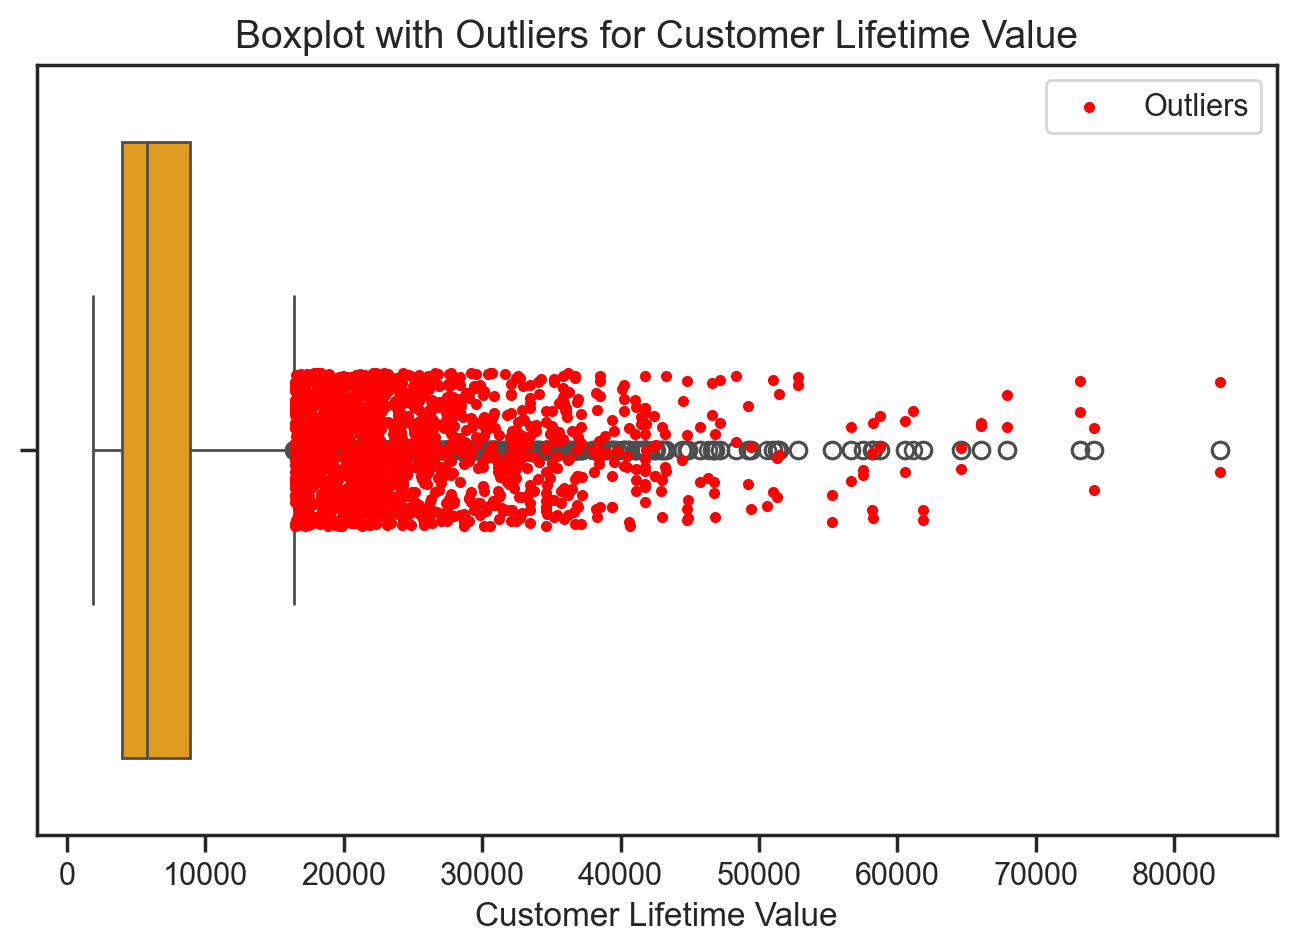

Column: Income - Number of Outliers: 0
Column: Income - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_79732\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


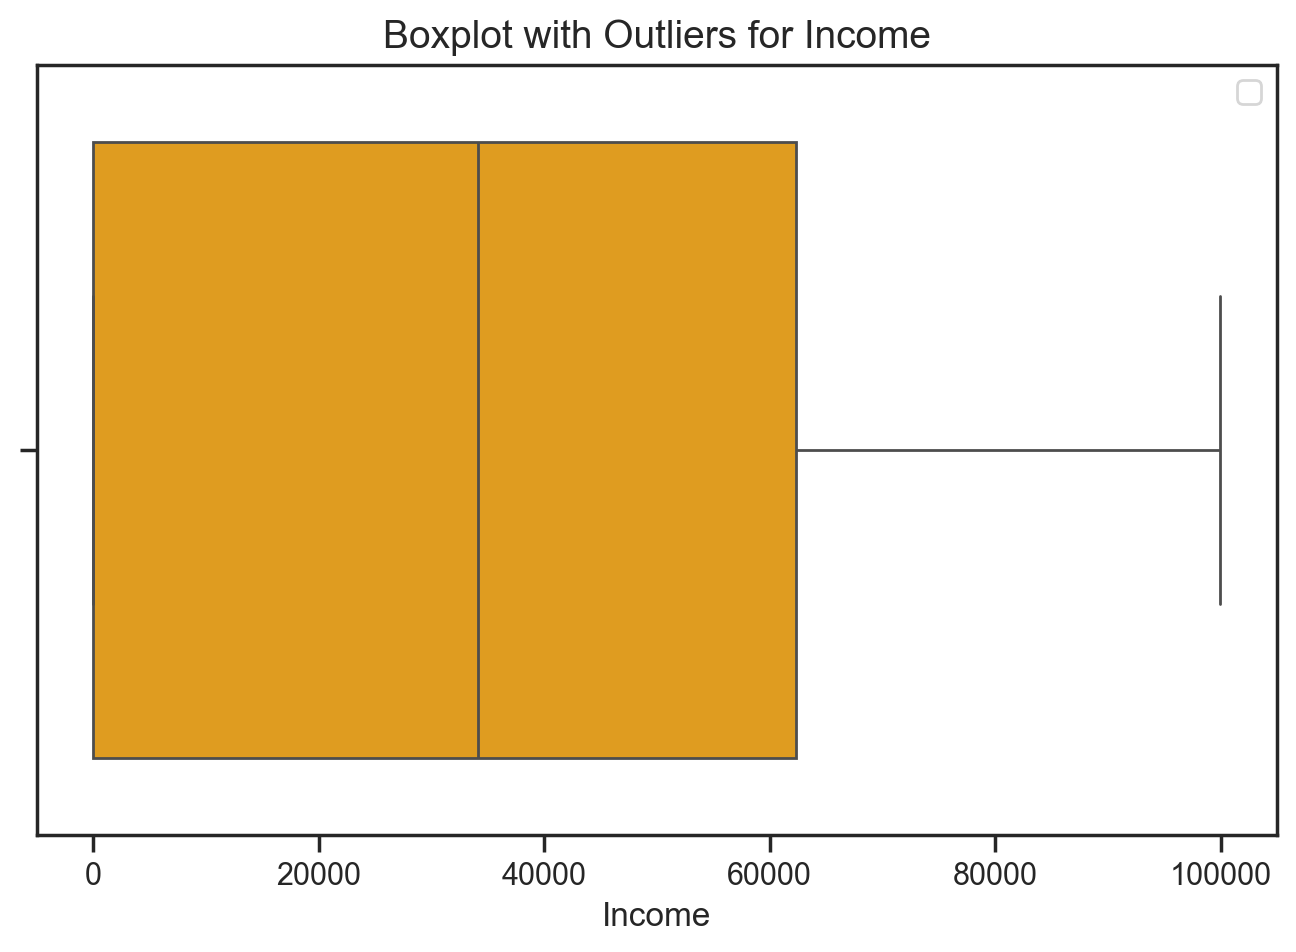

Column: Days_sub - Number of Outliers: 0
Column: Days_sub - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_79732\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


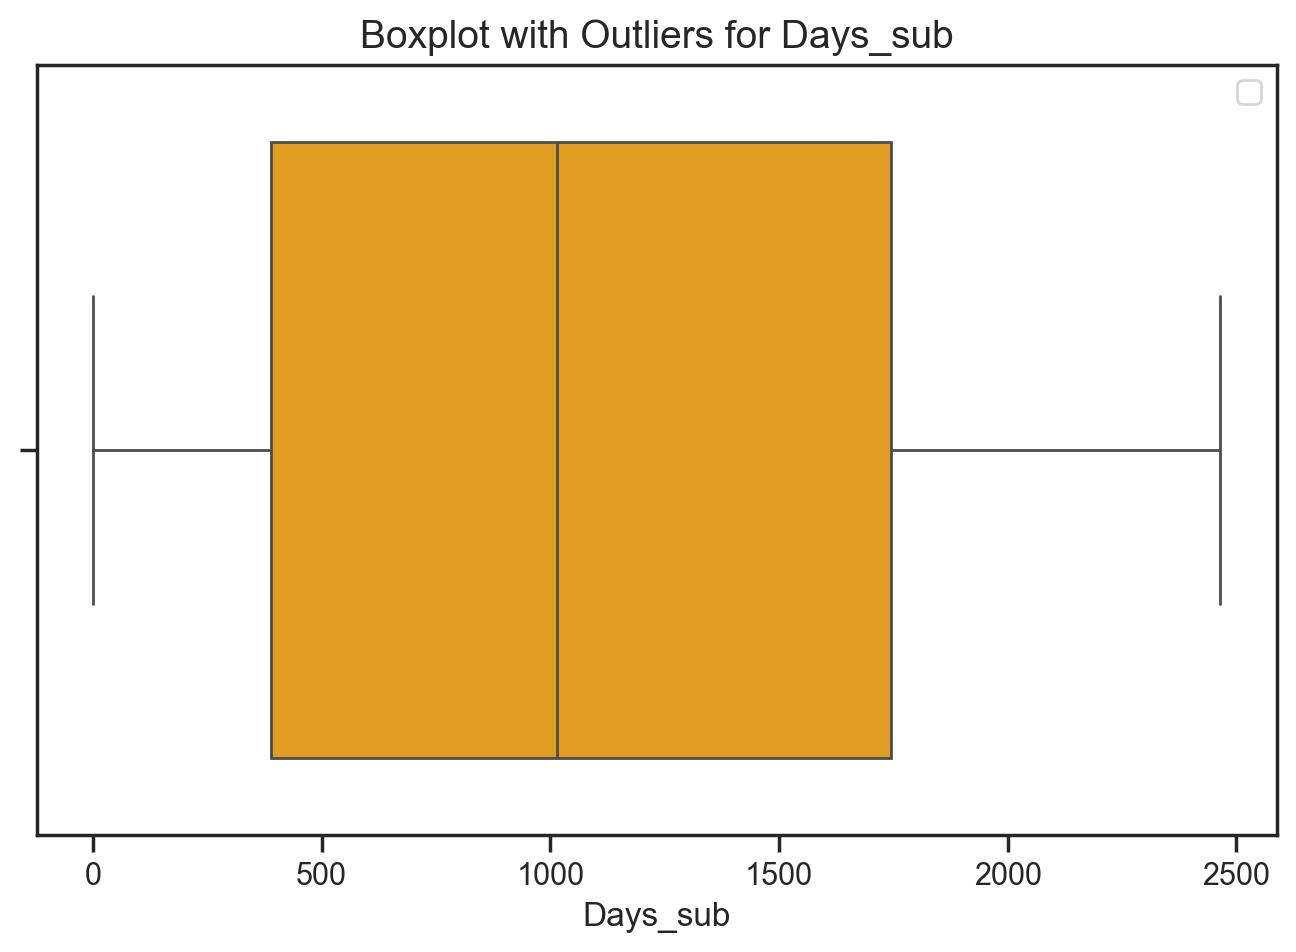

,Column,Num_Outliers,Pct_Outliers
0,Customer Lifetime Value,1460,8.798361


In [1581]:
detect_outliers_iqr(df_c[df_c_metric], 0.001)

We only observe missing values for **Customer Lifetime Value**

In [1582]:
df_c.loc[df_c['Customer Lifetime Value']>50000]

,Loyalty#,Province or State,City,Education,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,Days_sub
4149,364710,Quebec,Tremblant,Bachelor,25167,Married,Aurora,51016.07,2021 Promotion,270
4150,566374,New Brunswick,Moncton,Bachelor,25167,Married,Aurora,51016.07,Standard,902
4151,333051,New Brunswick,Moncton,Bachelor,84650,Married,Aurora,51426.25,2021 Promotion,244
4152,642323,Ontario,Toronto,College,0,Married,Aurora,52811.49,Standard,372
4153,798869,New Brunswick,Fredericton,Bachelor,40740,Single,Aurora,55277.45,Standard,68
4154,977244,Quebec,Montreal,Bachelor,77237,Married,Aurora,56675.94,Standard,1366
4155,801738,Saskatchewan,Regina,Bachelor,48367,Married,Aurora,57520.50,2021 Promotion,331
4156,219139,Alberta,Banff,Bachelor,61321,Single,Aurora,58166.55,Standard,1025
4157,228030,British Columbia,Vancouver,Bachelor,24964,Married,Aurora,58753.88,Standard,851
4158,592992,Ontario,Trenton,College,0,Married,Aurora,61850.19,Standard,2000


***

<h1>df_f

In [1583]:
df_f.columns

Index(['Loyalty#', 'Year', 'Month', 'NumFlights', 'NumFlightsWithCompanions',
       'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'DollarCostPointsRedeemed', 'AvgFlightDistance_month'],
      dtype='object')

In [1584]:
df_f_out = ['NumFlights','NumFlightsWithCompanions','DistanceKM','PointsRedeemed', 'AvgFlightDistance_month']

Column: NumFlights - Number of Outliers: 519
Column: NumFlights - % of Outliers: 0.09%



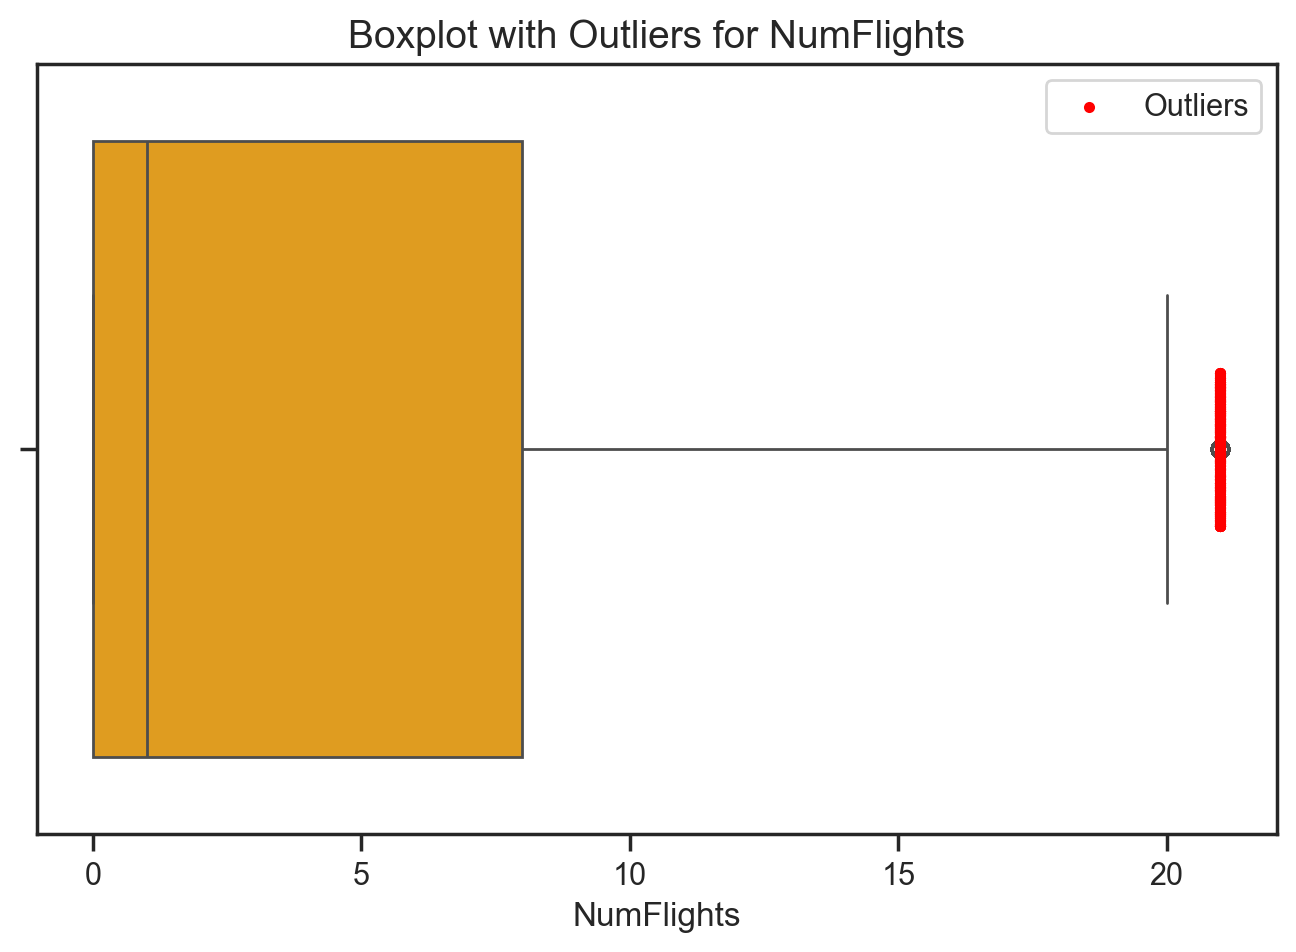

Column: NumFlightsWithCompanions - Number of Outliers: 95880
Column: NumFlightsWithCompanions - % of Outliers: 16.07%



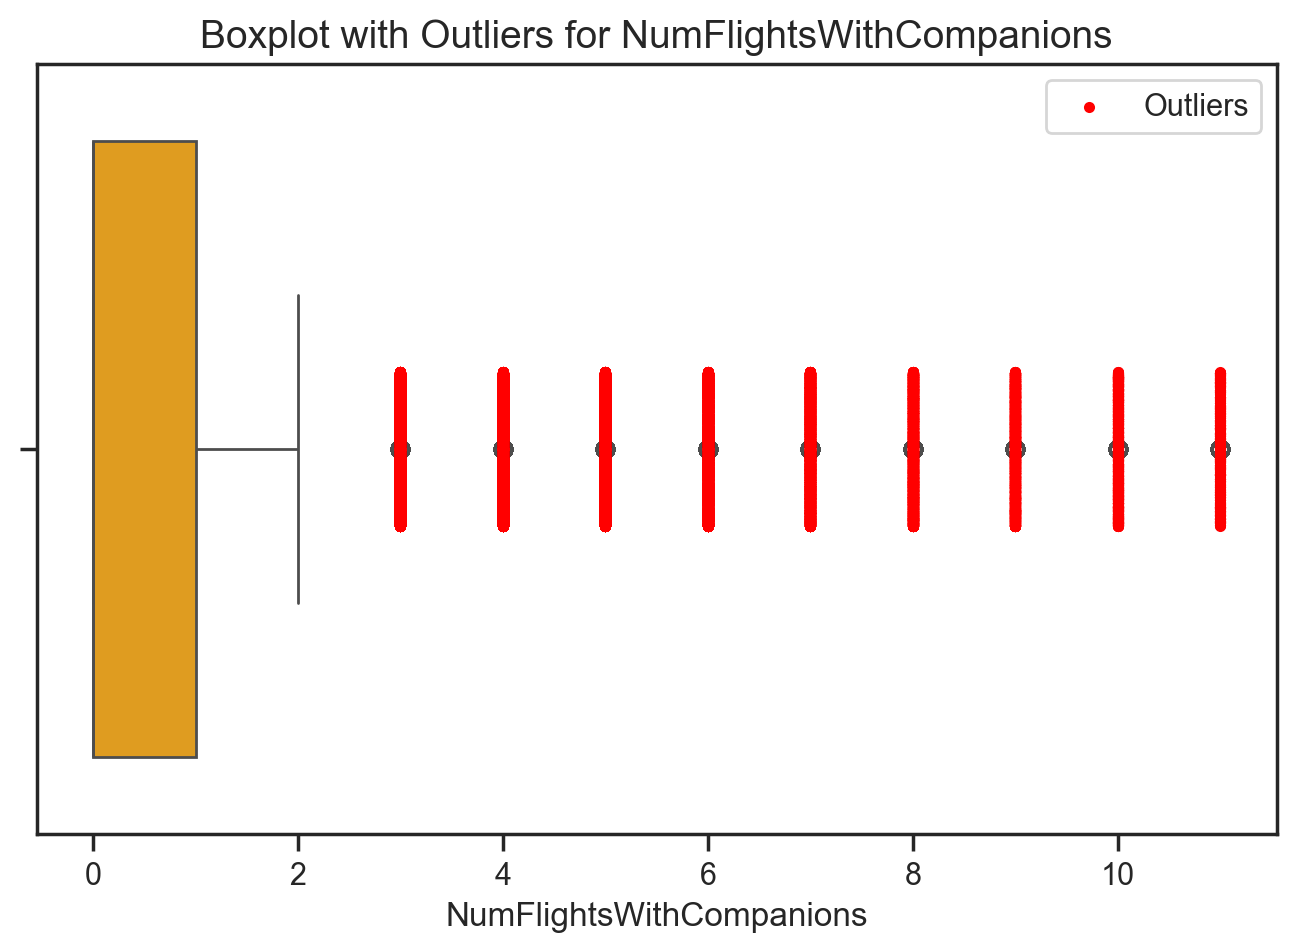

Column: DistanceKM - Number of Outliers: 1828
Column: DistanceKM - % of Outliers: 0.31%



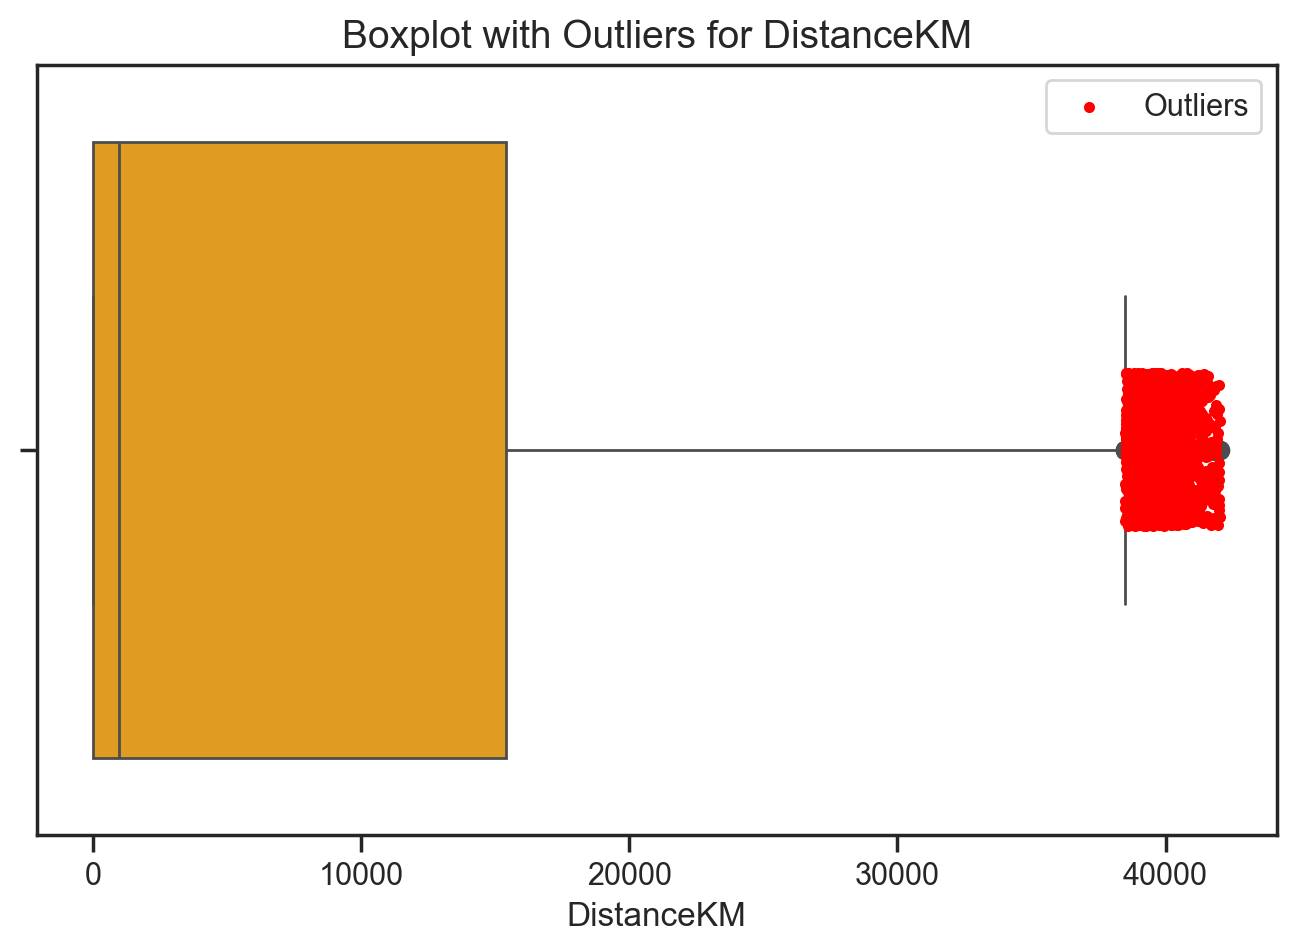

Column: PointsRedeemed - Number of Outliers: 34884
Column: PointsRedeemed - % of Outliers: 5.85%



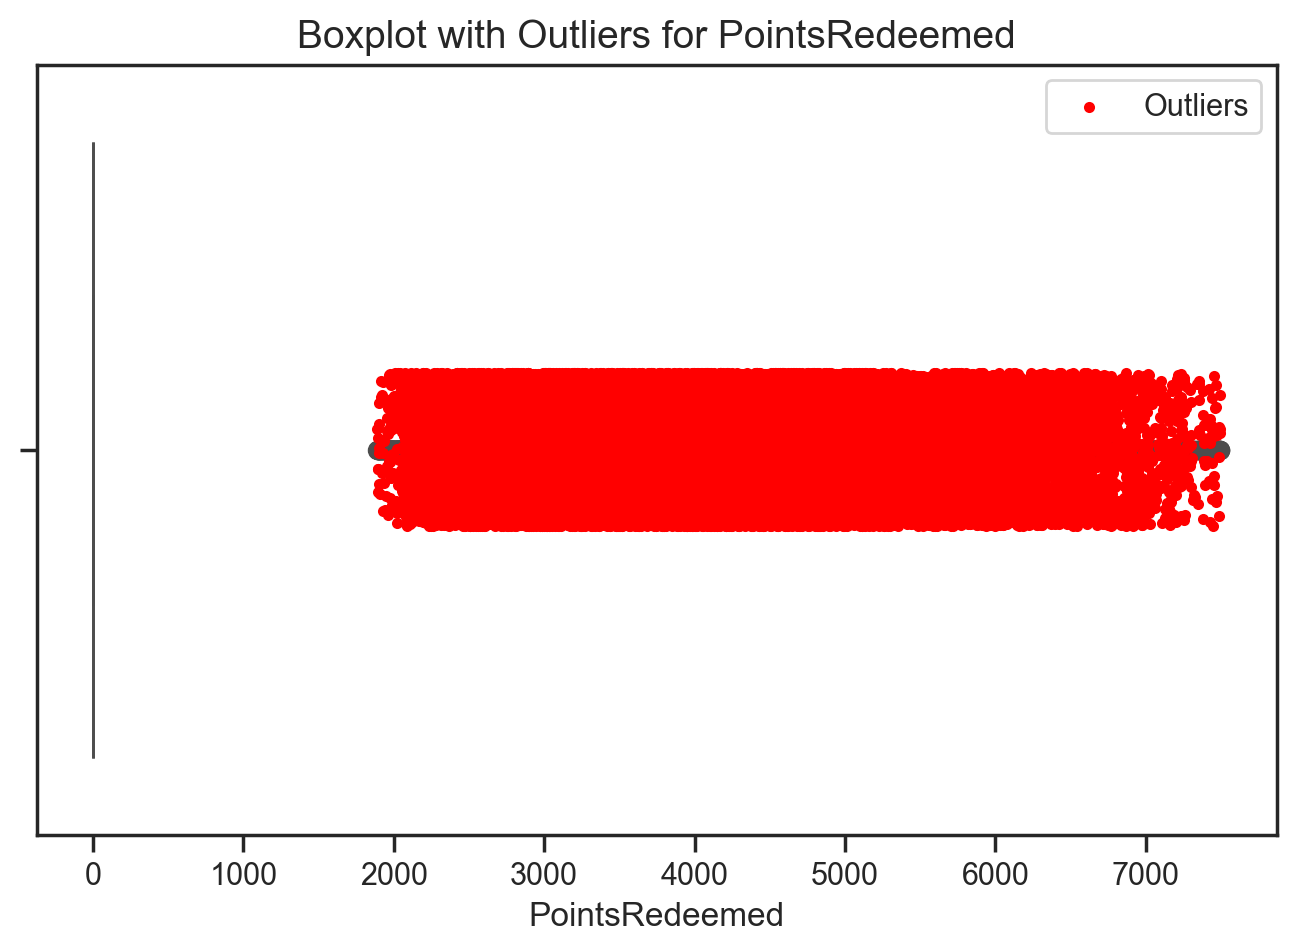

Column: AvgFlightDistance_month - Number of Outliers: 52947
Column: AvgFlightDistance_month - % of Outliers: 8.87%



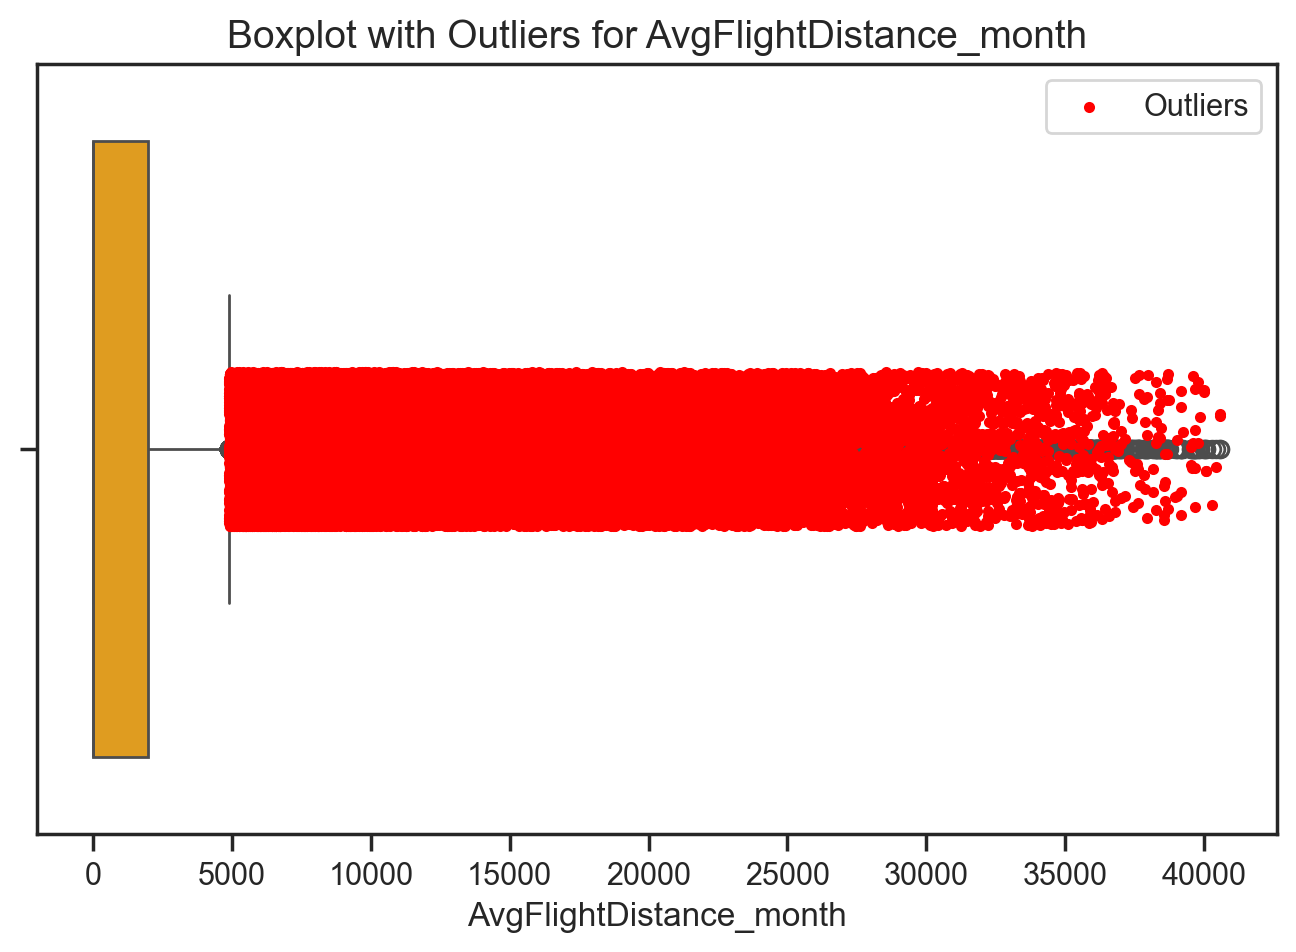

,Column,Num_Outliers,Pct_Outliers
0,NumFlightsWithCompanions,95880,16.069346
1,DistanceKM,1828,0.306370
2,PointsRedeemed,34884,5.846507
3,AvgFlightDistance_month,52947,8.873839


In [1585]:
detect_outliers_iqr(df_f[df_f_out], 0.001)

<h2>NumFlightsWithCompanions

In [1586]:
df_f[df_f['NumFlightsWithCompanions'] == 5].shape

(18343, 10)

In [1587]:
df_f[df_f['NumFlightsWithCompanions'] == 10].shape

(1051, 10)

Lower NumFlightsWithCompanions values have more observations, as expected.

<h2>AvgFlightDistance_month

AvgFlightDistance_month measures the average distance traveled per flight by a customer in a single month. The longest flight in 2025 is New York (JFK) – Singapore (SIN) with 15,349 km (9,537 mi) of Flight Distance (https://airinsight.com/top-10-longest-flights-in-2025/). This means that AvgFlightDistance_month values above 15.349 KM are unrealistic and probably an identation error of NumFlights or DistanceKM.

In [1588]:
df_f[df_f['AvgFlightDistance_month']>15349].sample(10)

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month
455272,944355,2019,3,1.0,1,22466.7,2246.67,0.0,0.0,22466.70
300658,925433,2020,12,1.0,0,22255.0,2225.00,0.0,0.0,22255.00
526524,240044,2019,8,1.0,1,26180.1,2618.01,0.0,0.0,26180.10
274082,438707,2021,1,1.0,1,23958.0,2395.00,0.0,0.0,23958.00
261881,481018,2021,2,1.0,1,15624.0,1562.00,0.0,0.0,15624.00
56883,298181,2020,3,1.0,0,15694.0,1569.00,0.0,0.0,15694.00
399560,571017,2020,6,1.0,0,23677.0,2367.00,0.0,0.0,23677.00
151092,277281,2021,5,1.0,1,26796.0,2679.00,0.0,0.0,26796.00
482718,605421,2019,5,1.0,0,24148.8,2414.88,0.0,0.0,24148.80
506011,946172,2019,6,2.0,2,35561.7,3556.17,4581.9,45.0,17780.85


All of these flights have 1-2 Number of flights in that month (NumFlights) and DistanceKM is in sinc with PointAccumulated. It looks like an identation error from NumFlights variable. Therefore we will set those as missing values to impute them later.

In [1589]:
#set NumFlights where AvgFlightDistance_month is >15349 to NaN
df_f.loc[df_f['AvgFlightDistance_month']>15349, 'NumFlights'] = np.nan

## Imputing NumFlights missing values

Before aggregating the flights dataset by customer and merging customers and flight dataset, we will impute the Numflights missing values with a KNN imputer

In [1590]:
df_f.isna().sum()

Loyalty#                        0
Year                            0
Month                           0
NumFlights                  21530
NumFlightsWithCompanions        0
DistanceKM                      0
PointsAccumulated               0
PointsRedeemed                  0
DollarCostPointsRedeemed        0
AvgFlightDistance_month         0
dtype: int64

In [1591]:
knn_feat = ['Year', 'Month', 'NumFlights', 'DistanceKM']

In [1592]:
from sklearn.linear_model import LinearRegression
# Valid mask to aggregate observations for imputation
mask_valid = (df_f["NumFlights"].notna() & df_f["DistanceKM"].notna() & (df_f["NumFlights"] > 0)
)
# Where we want to impute
mask_missing = df_f["NumFlights"].isna()

# Just for sanity check - in the end we check if the imputation made sense
df_f["NumFlights_imputed"] = False
df_f.loc[mask_missing, "NumFlights_imputed"] = True

# Adjust model
X = df_f.loc[mask_valid, ["DistanceKM"]]
y = df_f.loc[mask_valid, "NumFlights"]

model = LinearRegression(fit_intercept=False)
model.fit(X, y)

# Imputation
df_f.loc[mask_missing, "NumFlights"] = (
    pd.Series(model.predict(df_f.loc[mask_missing, ["DistanceKM"]]), index=df_f.loc[mask_missing].index)
    .round()
    .clip(lower=0)
)

df_f.loc[df_f["NumFlights_imputed"]].head(20)

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month,NumFlights_imputed
19,261109,2021,12,6.0,0,13736.0,1373.0,0.0,0.0,0.0,True
41,377724,2021,12,7.0,1,16998.0,1699.0,0.0,0.0,16998.0,True
75,684835,2021,12,9.0,1,22980.0,2298.0,4867.0,48.0,22980.0,True
93,817609,2021,12,10.0,0,23775.0,2377.0,0.0,0.0,0.0,True
96,192600,2021,12,2.0,0,5119.0,511.0,0.0,0.0,0.0,True
112,366654,2021,12,9.0,1,22839.0,2283.0,0.0,0.0,22839.0,True
116,883242,2021,12,8.0,0,20681.0,2068.0,0.0,0.0,0.0,True
126,755867,2021,12,7.0,1,18236.0,1823.0,0.0,0.0,18236.0,True
154,493800,2021,12,7.0,0,17502.0,1750.0,0.0,0.0,0.0,True
177,607555,2021,12,13.0,1,32056.0,3205.0,0.0,0.0,32056.0,True


In [1593]:
df_f = df_f.drop(columns=['AvgFlightDistance_month'])

df_f['AvgFlightDistance_month'] = np.where(
    df_f['NumFlights'] > 0,
    df_f['DistanceKM'] / df_f['NumFlights'],
    0
)

In [1594]:
df_f[df_f['AvgFlightDistance_month']>15349]

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,NumFlights_imputed,AvgFlightDistance_month


Now there are NumFlights values with decimal cases, lets fix it by rounding the number

In [1595]:
#df_f[(df_f['NumFlights'] < 3) & (df_f['NumFlights'] > 2)].sample(3)

In [1596]:
df_f['NumFlights'] = df_f['NumFlights'].round()

df_f = df_f.drop(columns=['AvgFlightDistance_month'])

df_f['AvgFlightDistance_month'] = np.where(
    df_f['NumFlights'] > 0,
    df_f['DistanceKM'] / df_f['NumFlights'],
    0
)

df_f[df_f['AvgFlightDistance_month']>15349]

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,NumFlights_imputed,AvgFlightDistance_month


## Aggregate Flights dataset by customer

In [1597]:
# Aggregate by client - Loyalty 
df_f_agg = (df_f.groupby("Loyalty#").agg(
    {"Year": ["nunique"],                     
    "Month": ["nunique"],                    
    "NumFlights": ["sum", "mean", "max"],    
    "NumFlightsWithCompanions": ["sum", "mean"],  
    "DistanceKM": ["sum", "mean", "max"],    
    "PointsAccumulated": ["sum", "mean"],    
    "PointsRedeemed": ["sum", "mean"],       
    "DollarCostPointsRedeemed": ["sum", "mean"]}).reset_index())

# I know there are a lot of variables, but u never know if we will use them. In the end, they can be removed
df_f_agg.columns = ["Loyalty#", "Years_Active", "Months_Active", "Flights_Sum", "Flights_Mean", "Flights_Max",
                          "FlightsComp_Sum", "FlightsComp_Mean", "DistKM_Sum", "DistKM_Mean", "DistKM_Max", "PtsAcc_Sum", "PtsAcc_Mean",
                          "PtsRed_Sum", "PtsRed_Mean", "CostPts_Sum", "CostPts_Mean"]

# Feature Engineering (some variables created that could be important)
# Ratio between Points Redeemed and Points Accumulated over the time
df_f_agg["PointsEfficiency"] = (
    df_f_agg["PtsRed_Sum"] / df_f_agg["PtsAcc_Sum"]
).replace([np.inf, np.nan], 0)

# Distance
df_f_agg["DistPerFlight"] = (
    df_f_agg["DistKM_Sum"] / df_f_agg["Flights_Sum"]
).replace([np.inf, np.nan], 0)


In [1598]:
df_f_agg.sample(10)

,Loyalty#,Years_Active,Months_Active,Flights_Sum,Flights_Mean,Flights_Max,FlightsComp_Sum,FlightsComp_Mean,DistKM_Sum,DistKM_Mean,DistKM_Max,PtsAcc_Sum,PtsAcc_Mean,PtsRed_Sum,PtsRed_Mean,CostPts_Sum,CostPts_Mean,PointsEfficiency,DistPerFlight
15654,949829,3,12,227.0,6.305556,14.0,67,1.861111,311571.6,8654.766667,32322.0,31150.96,865.304444,24788.6,688.572222,246.7,6.852778,0.795757,1372.562115
71,103699,3,12,78.0,2.166667,16.0,12,0.333333,136268.0,3785.222222,28921.0,13624.00,378.444444,0.0,0.000000,0.0,0.000000,0.000000,1747.025641
5363,392575,3,12,134.0,3.722222,15.0,29,0.805556,263092.4,7308.122222,38897.0,26305.94,730.720556,13315.2,369.866667,131.1,3.641667,0.506167,1963.376119
11530,724513,3,12,32.0,0.888889,12.0,0,0.000000,31864.0,885.111111,14056.0,3185.00,88.472222,0.0,0.000000,0.0,0.000000,0.000000,995.750000
3768,305150,3,12,179.0,4.972222,14.0,60,1.666667,424835.7,11800.991667,30717.0,42475.37,1179.871389,7729.2,214.700000,76.0,2.111111,0.181969,2373.383799
2120,214123,3,12,19.0,0.527778,10.0,0,0.000000,18686.5,519.069444,9835.0,1868.15,51.893056,0.0,0.000000,0.0,0.000000,0.000000,983.500000
9197,599746,3,12,162.0,4.500000,18.0,48,1.333333,348985.9,9694.052778,35532.0,34893.49,969.263611,11785.7,327.380556,115.9,3.219444,0.337762,2154.233951
8430,557880,3,12,256.0,7.111111,17.0,64,1.777778,400762.1,11132.280556,28126.0,40067.81,1112.994722,20586.0,571.833333,204.3,5.675000,0.513779,1565.476953
13028,804137,3,12,224.0,6.222222,14.0,75,2.083333,398588.3,11071.897222,34968.0,39849.73,1106.936944,14271.0,396.416667,141.0,3.916667,0.358120,1779.412054
9567,617263,3,12,209.0,5.805556,20.0,41,1.138889,345036.6,9584.350000,32464.0,34497.66,958.268333,4881.1,135.586111,47.5,1.319444,0.141491,1650.892823


As we can see, for all the customers, the "Years_Active" and "Months_Active" are the same, so we are going to drop both.

In [1599]:
df_f_agg = df_f_agg.drop(['Years_Active', 'Months_Active'], axis=1)

## Missing Values

Let's treat the Missing Values before Merging the datasets

In [1600]:
df_c.isna().sum()

Loyalty#                    0
Province or State           0
City                        0
Education                   0
Income                     20
Marital Status              0
LoyaltyStatus               0
Customer Lifetime Value    20
EnrollmentType              0
Days_sub                    0
dtype: int64

In [1601]:
#lets the the rows where income is Nan
df_c[df_c['Income'].isna()]

,Loyalty#,Province or State,City,Education,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,Days_sub
0,999987,New Brunswick,Fredericton,Bachelor,<NA>,Single,Star,NaN,Standard,0
1,999988,Quebec,Montreal,College,<NA>,Single,Star,NaN,Standard,0
2,999989,Ontario,Trenton,College,<NA>,Married,Star,NaN,Standard,0
3,999990,New Brunswick,Moncton,College,<NA>,Married,Star,NaN,Standard,0
4,999991,New Brunswick,Fredericton,College,<NA>,Married,Star,NaN,Standard,0
5,999992,Ontario,Toronto,College,<NA>,Single,Star,NaN,Standard,0
6,999993,British Columbia,Dawson Creek,College,<NA>,Married,Star,NaN,Standard,0
7,999994,Ontario,Ottawa,College,<NA>,Married,Star,NaN,Standard,0
8,999995,Ontario,Ottawa,College,<NA>,Married,Star,NaN,Standard,0
9,999996,Ontario,Toronto,Bachelor,<NA>,Single,Star,NaN,Standard,0


The rows where income is Na are the rows where Customer Lifetime Value is also NaN. Lets see these customers on the flights dataset

In [1602]:
Nan_customer_ids = df_c[df_c['Income'].isna()]['Loyalty#'].tolist()

df_f[df_f['Loyalty#'].isin(Nan_customer_ids)]

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,NumFlights_imputed,AvgFlightDistance_month


The customers that have missing values on income and Customer Lifetime Value dont exist in the flights dataset so we will just remove them.

In [1603]:
#remove these customers from customer dataset
df_c = df_c[~df_c['Loyalty#'].isin(Nan_customer_ids)].copy()

## Merge both datasets

In [1604]:
df_agg_merged = pd.merge(df_c, df_f_agg, on="Loyalty#", how="left")
print("Final dimensions:", df_agg_merged.shape)

Final dimensions: (16574, 26)


In [1605]:
df_agg_merged.columns

Index(['Loyalty#', 'Province or State', 'City', 'Education', 'Income',
       'Marital Status', 'LoyaltyStatus', 'Customer Lifetime Value',
       'EnrollmentType', 'Days_sub', 'Flights_Sum', 'Flights_Mean',
       'Flights_Max', 'FlightsComp_Sum', 'FlightsComp_Mean', 'DistKM_Sum',
       'DistKM_Mean', 'DistKM_Max', 'PtsAcc_Sum', 'PtsAcc_Mean', 'PtsRed_Sum',
       'PtsRed_Mean', 'CostPts_Sum', 'CostPts_Mean', 'PointsEfficiency',
       'DistPerFlight'],
      dtype='object')

### Check outliers

We had checked outliers for df_c and df_f. But with the new flights dataset aggregated by customer we have created new variables.

In [1606]:
df_agg_merged_out = ['Income', 'Customer Lifetime Value',
       'Days_sub', 'Flights_Sum',
       'Flights_Mean', 'Flights_Max', 'FlightsComp_Sum', 'FlightsComp_Mean',
       'DistKM_Sum', 'DistKM_Mean', 'DistKM_Max', 'PtsAcc_Sum', 'PtsAcc_Mean',
       'PtsRed_Sum', 'PtsRed_Mean', 'CostPts_Sum', 'CostPts_Mean',
       'PointsEfficiency', 'DistPerFlight']

Column: Income - Number of Outliers: 0
Column: Income - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_79732\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


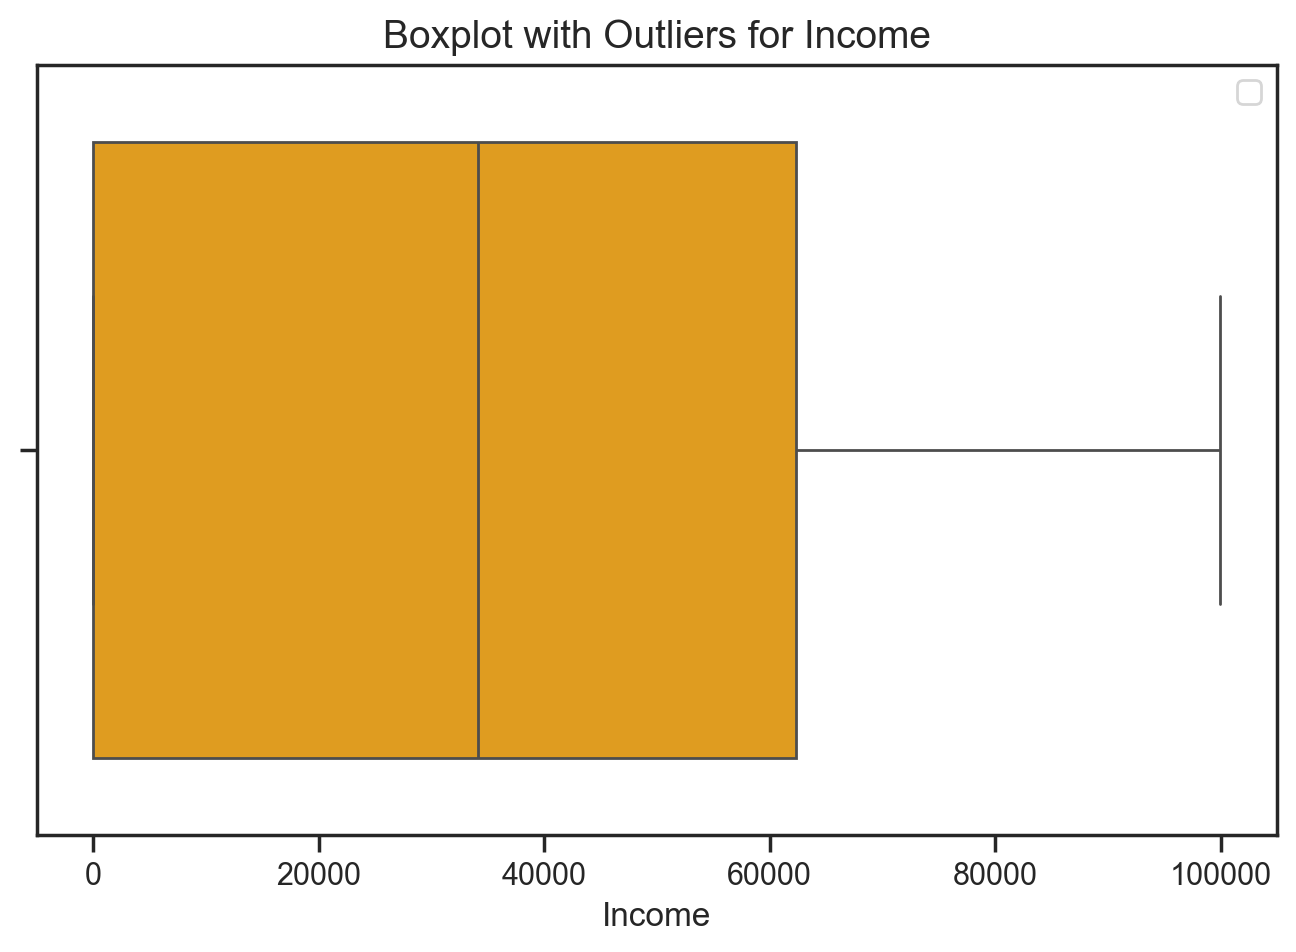

Column: Customer Lifetime Value - Number of Outliers: 1460
Column: Customer Lifetime Value - % of Outliers: 8.81%



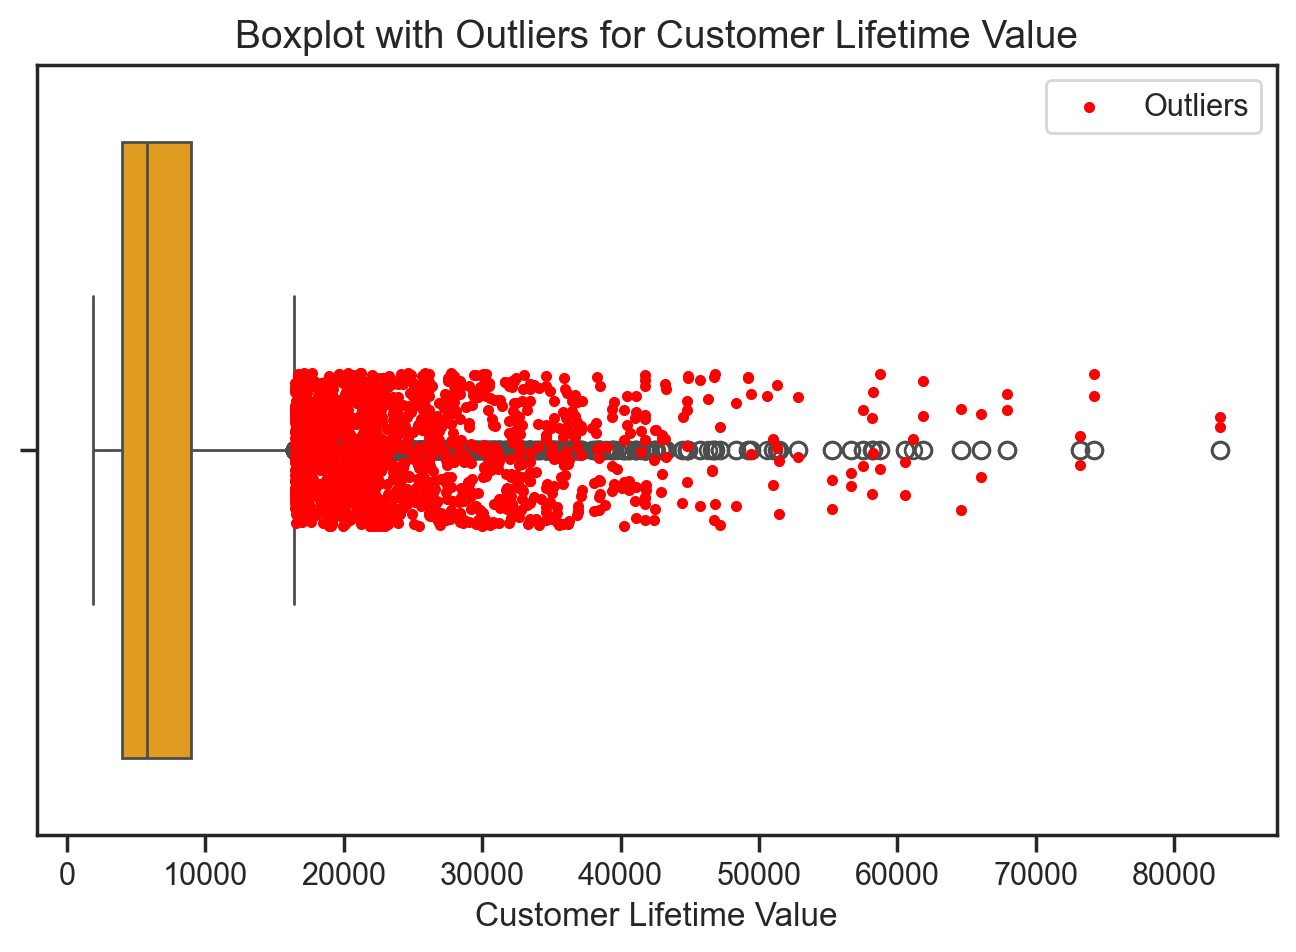

Column: Days_sub - Number of Outliers: 0
Column: Days_sub - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_79732\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


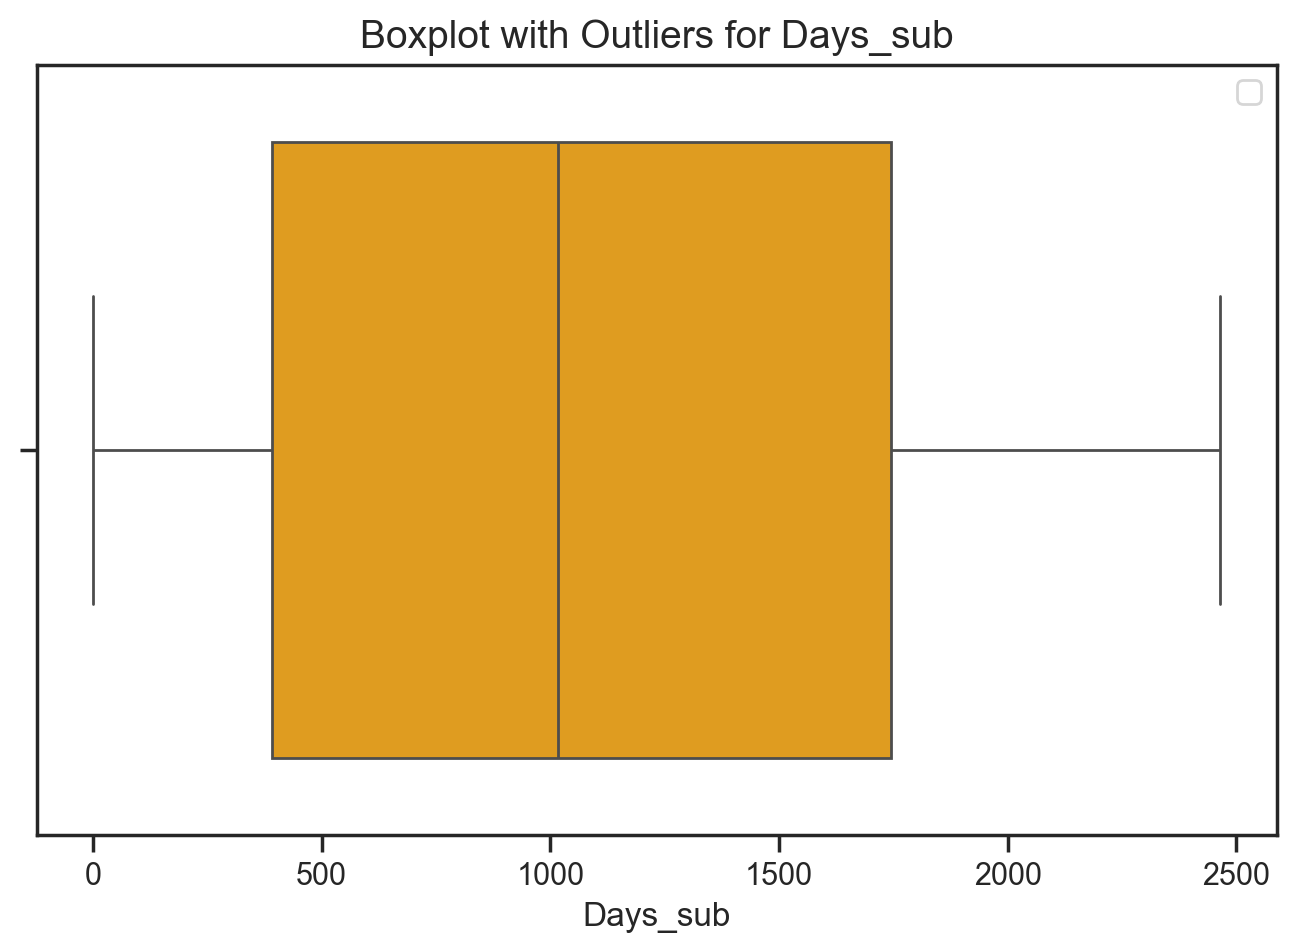

Column: Flights_Sum - Number of Outliers: 0
Column: Flights_Sum - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_79732\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


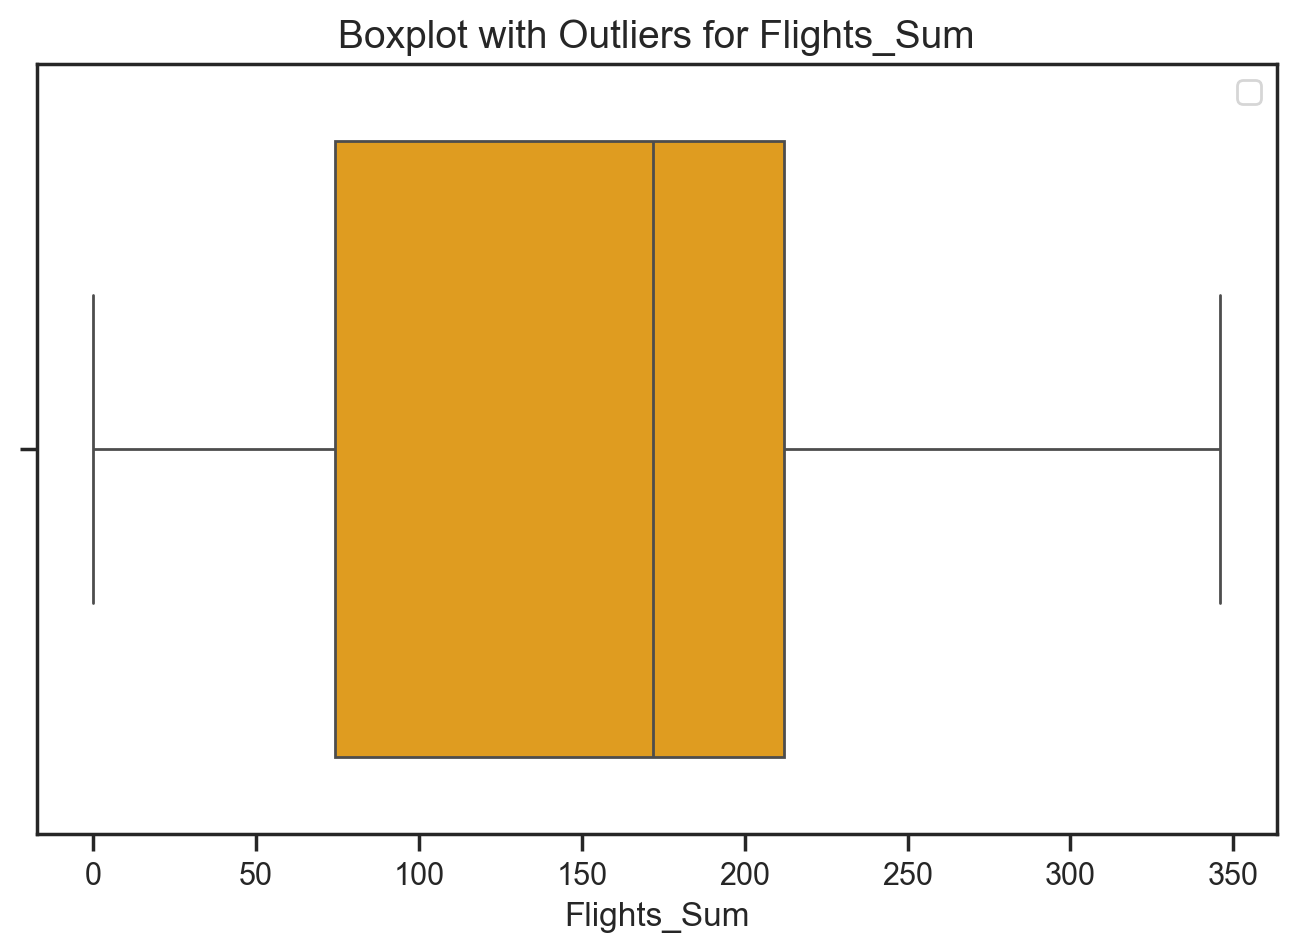

Column: Flights_Mean - Number of Outliers: 0
Column: Flights_Mean - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_79732\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


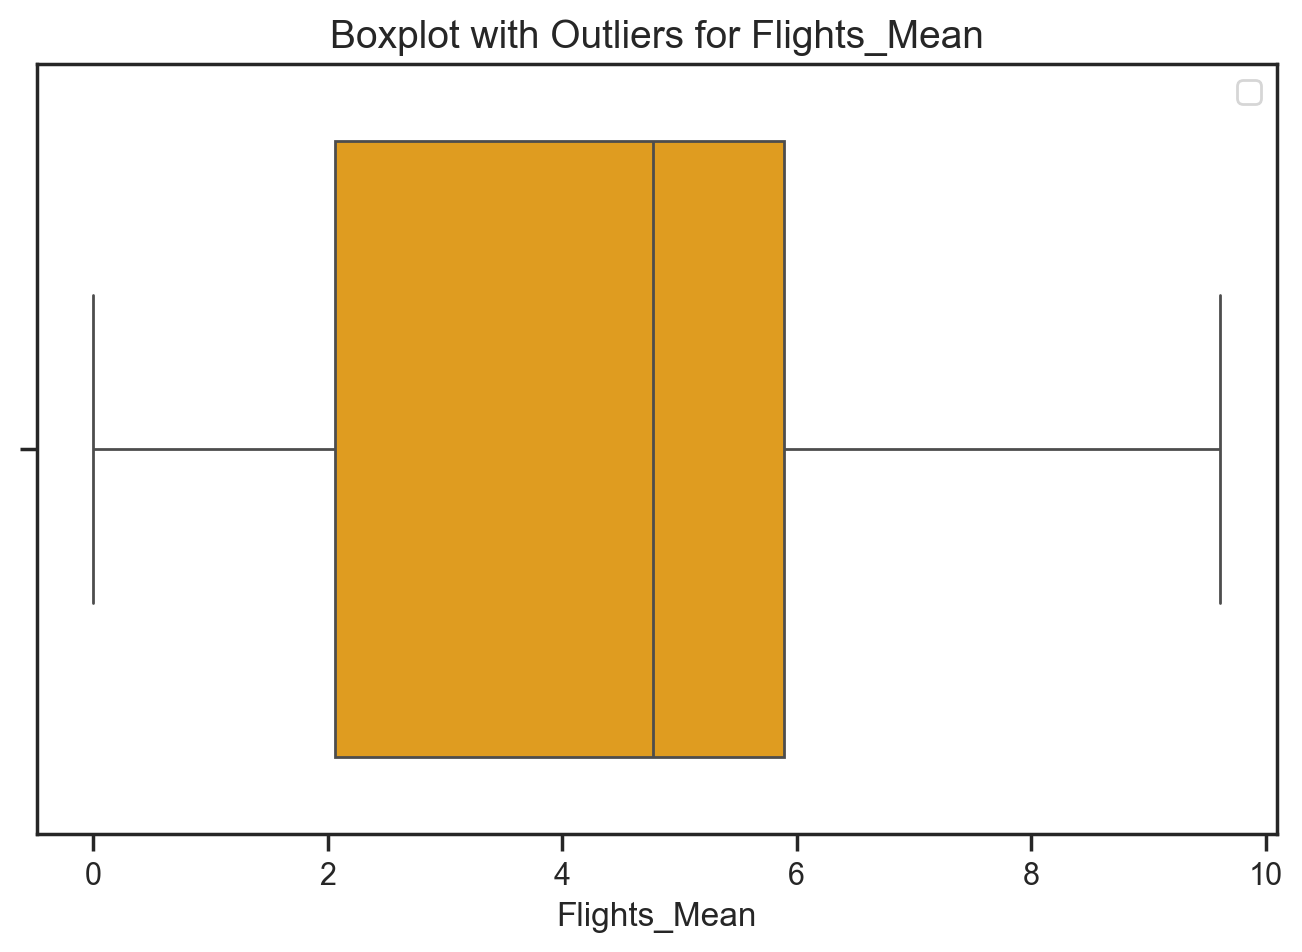

Column: Flights_Max - Number of Outliers: 1630
Column: Flights_Max - % of Outliers: 9.83%



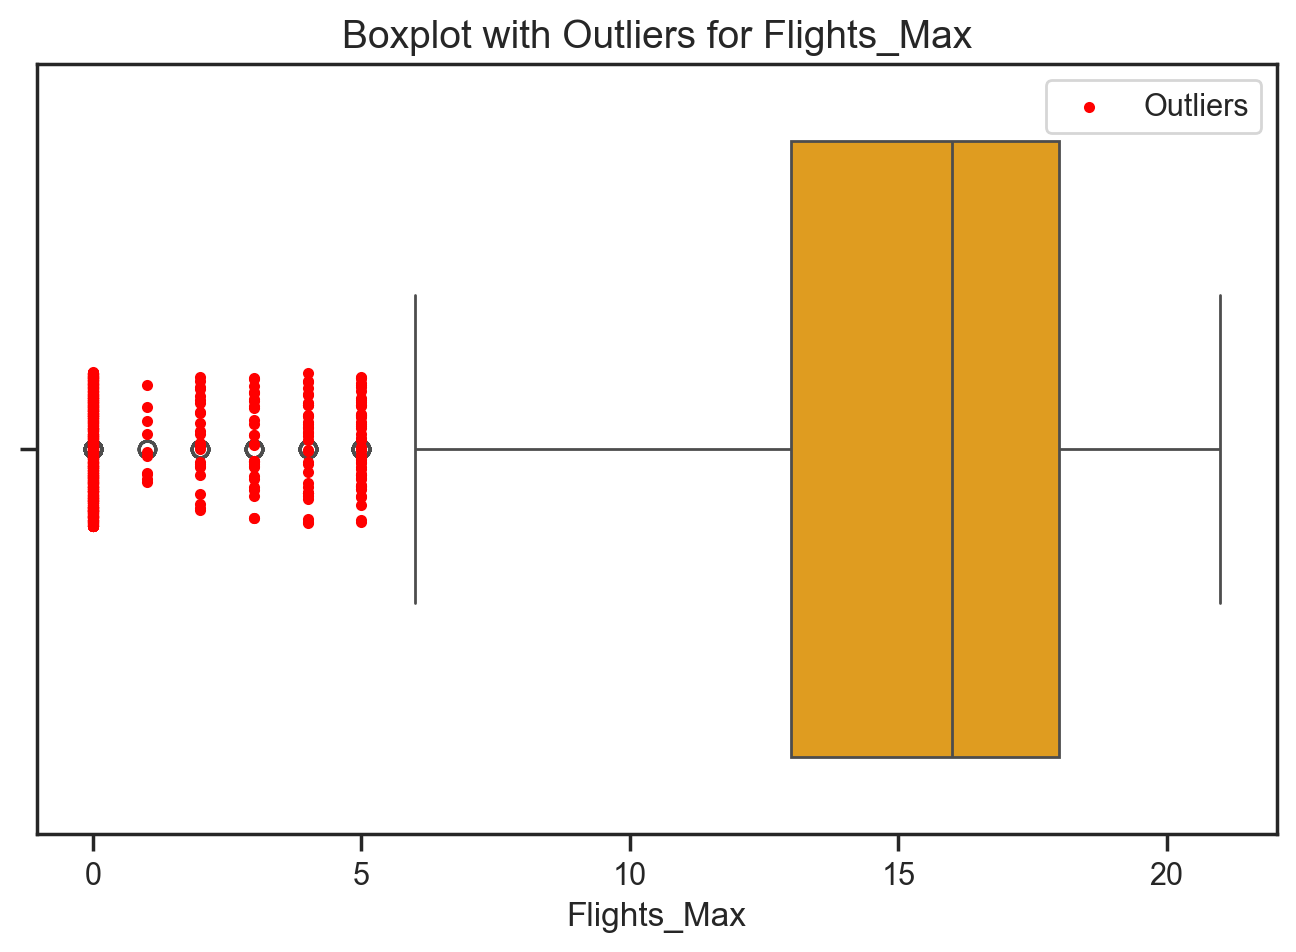

Column: FlightsComp_Sum - Number of Outliers: 18
Column: FlightsComp_Sum - % of Outliers: 0.11%



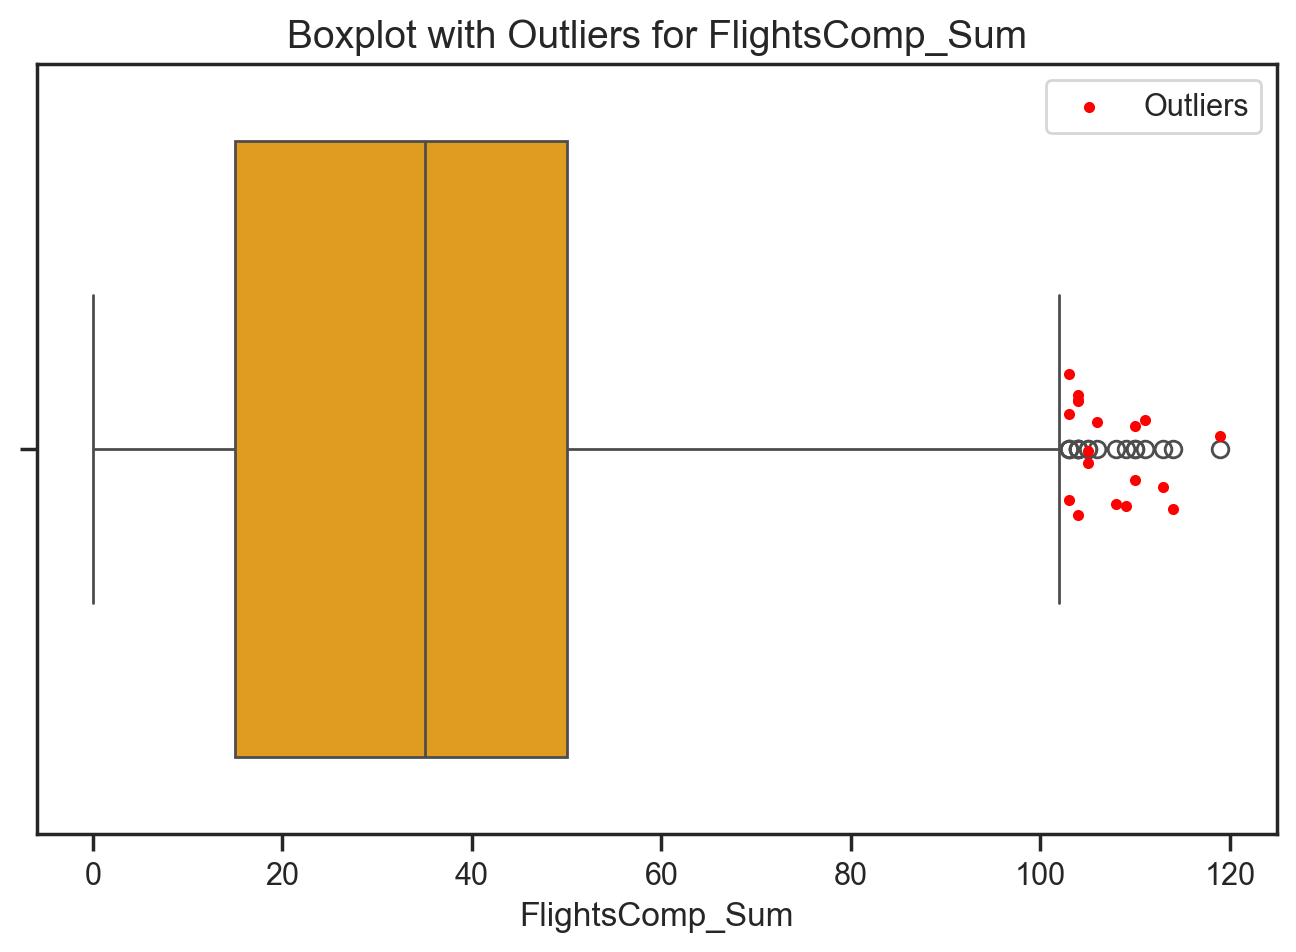

Column: FlightsComp_Mean - Number of Outliers: 18
Column: FlightsComp_Mean - % of Outliers: 0.11%



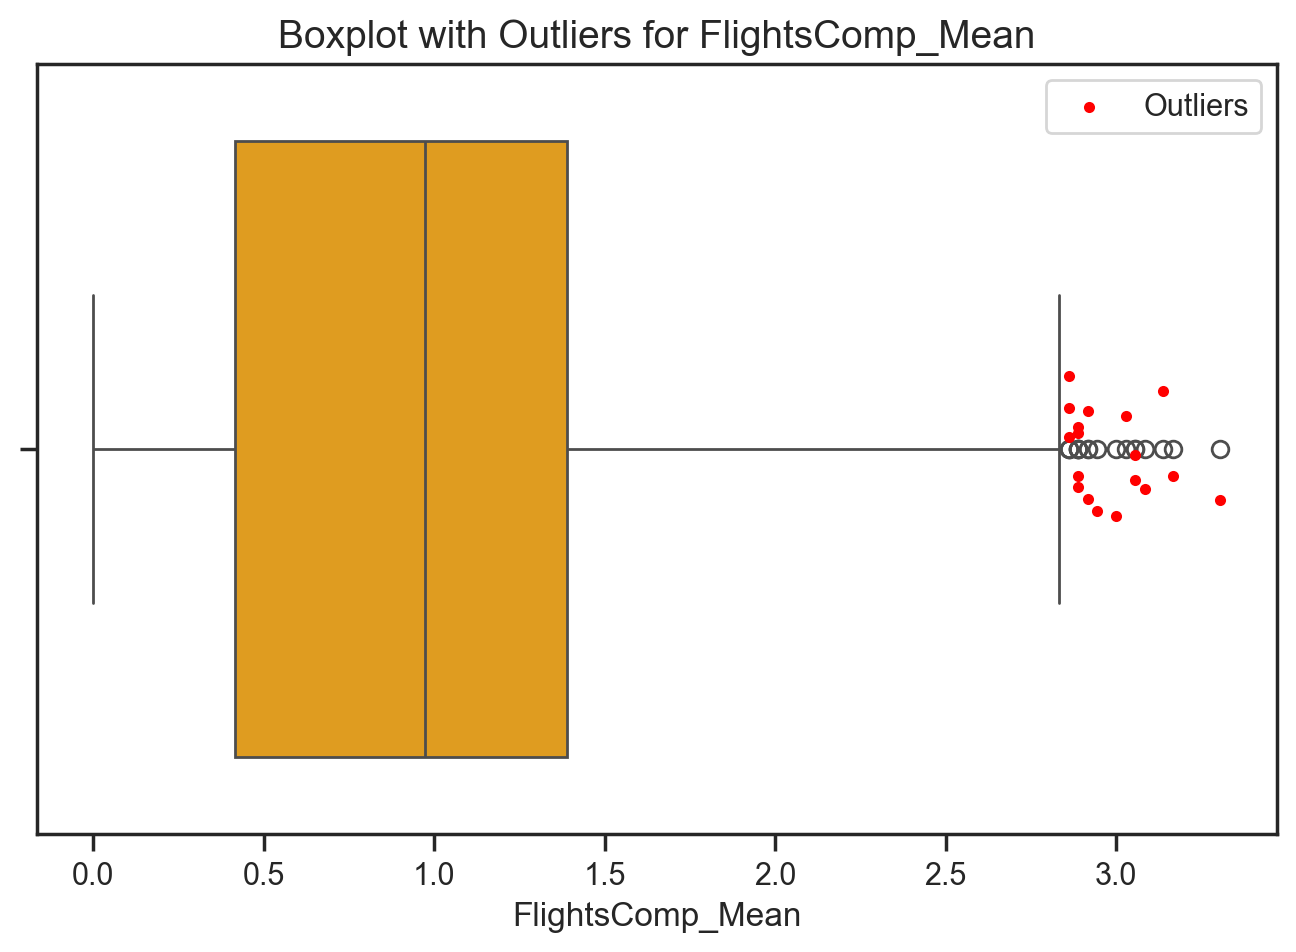

Column: DistKM_Sum - Number of Outliers: 0
Column: DistKM_Sum - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_79732\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


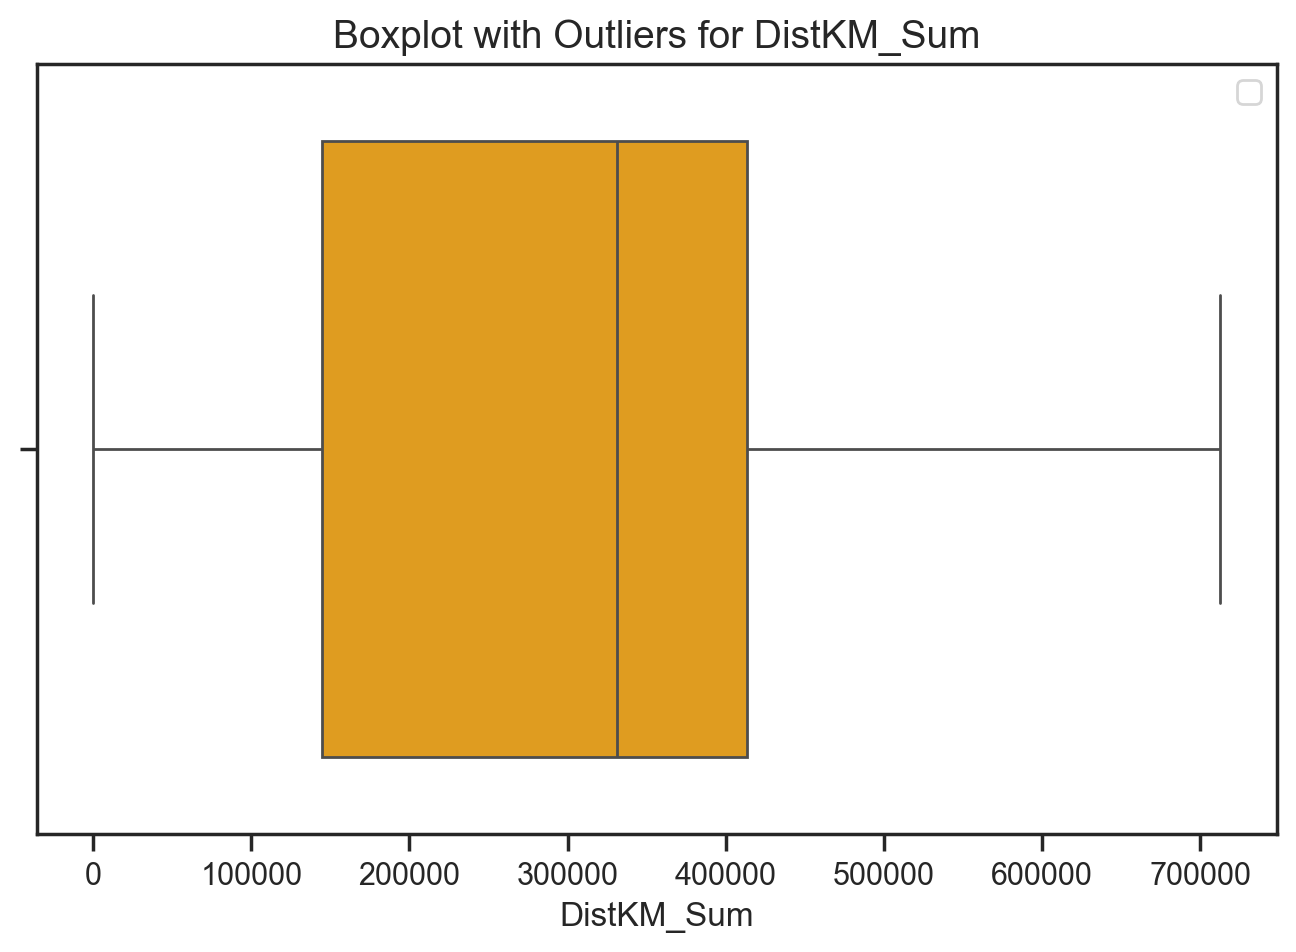

Column: DistKM_Mean - Number of Outliers: 0
Column: DistKM_Mean - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_79732\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


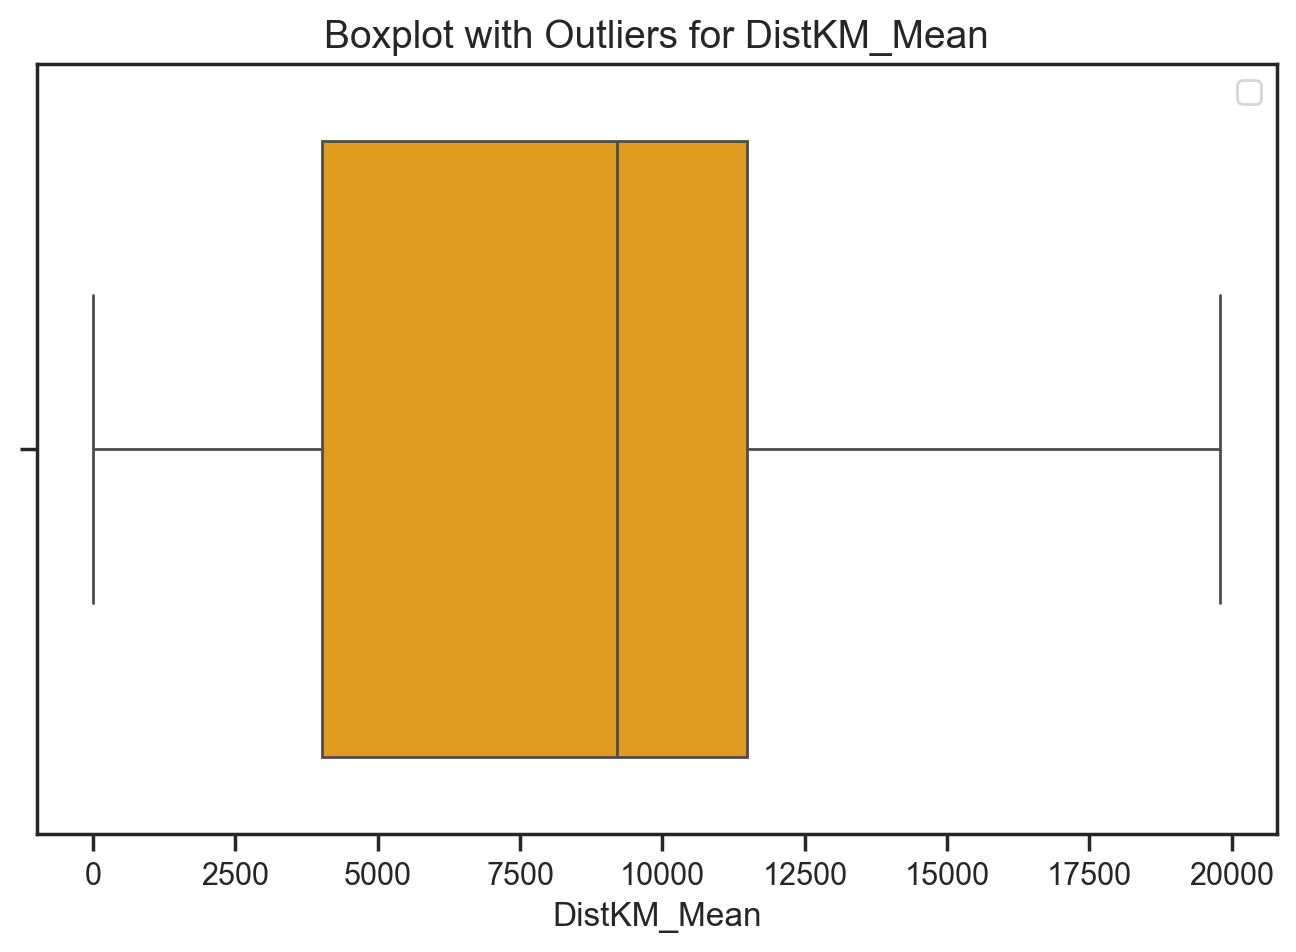

Column: DistKM_Max - Number of Outliers: 1808
Column: DistKM_Max - % of Outliers: 10.91%



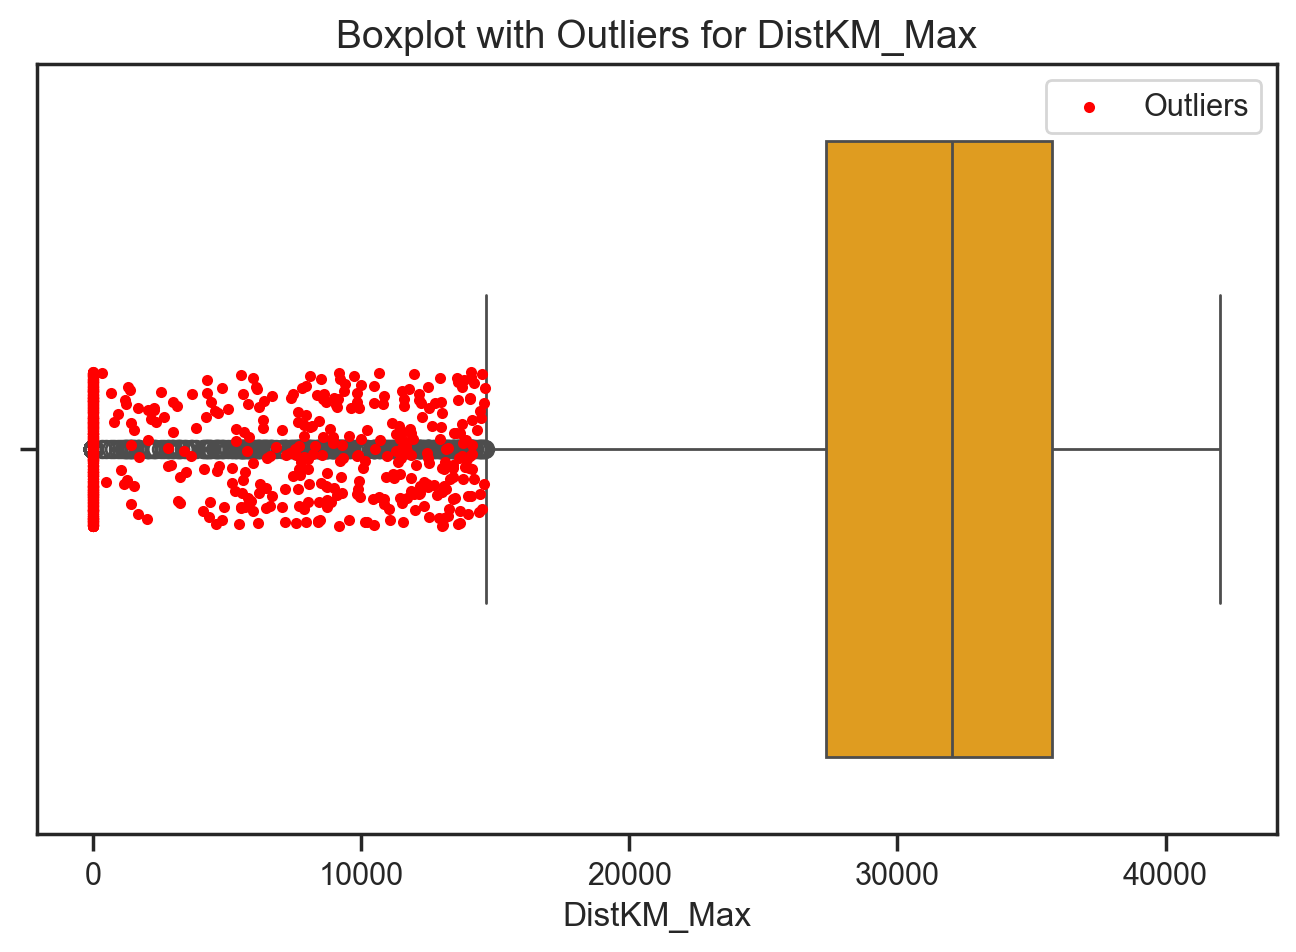

Column: PtsAcc_Sum - Number of Outliers: 0
Column: PtsAcc_Sum - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_79732\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


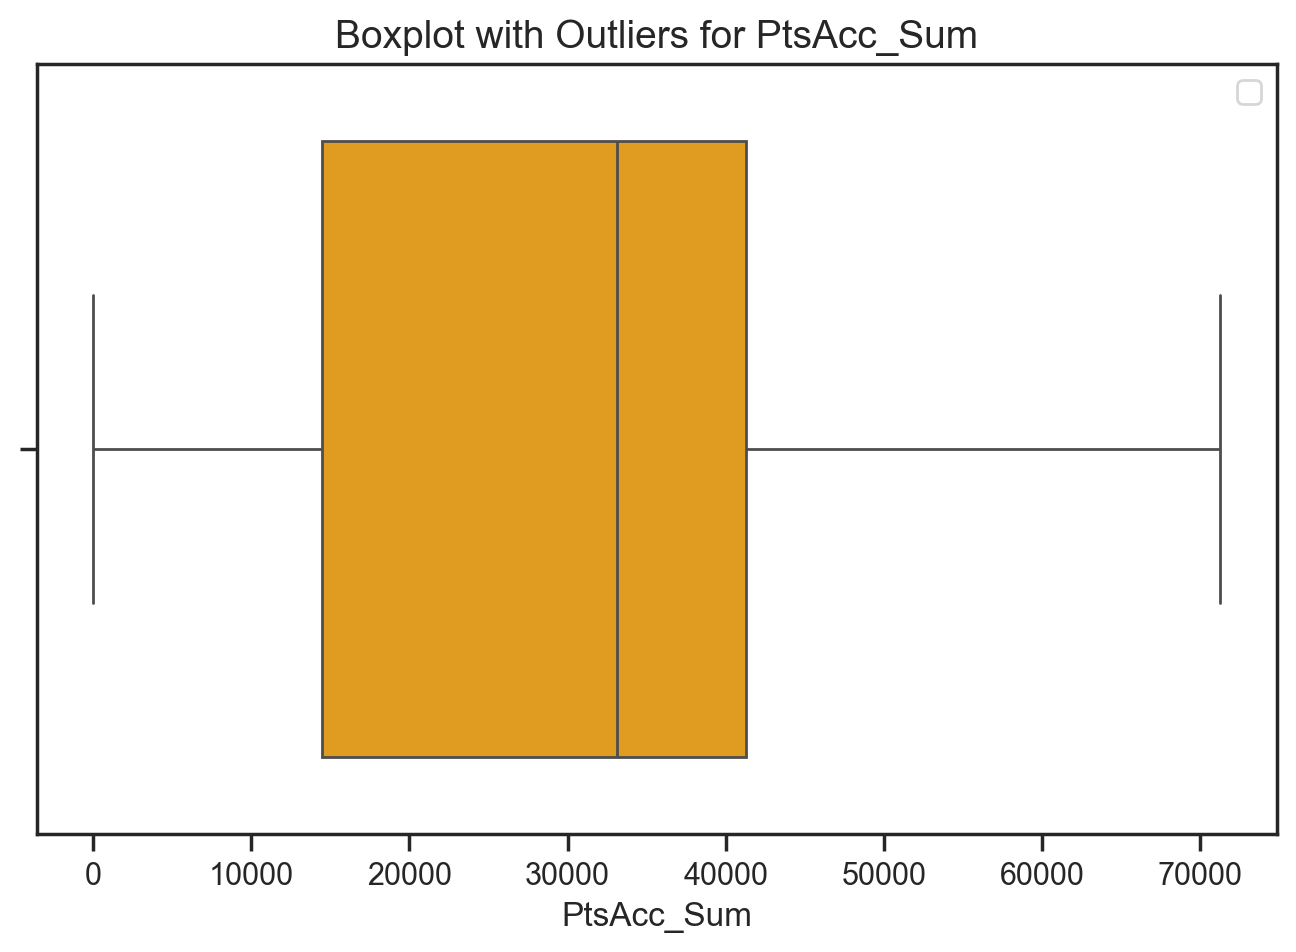

Column: PtsAcc_Mean - Number of Outliers: 0
Column: PtsAcc_Mean - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_79732\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


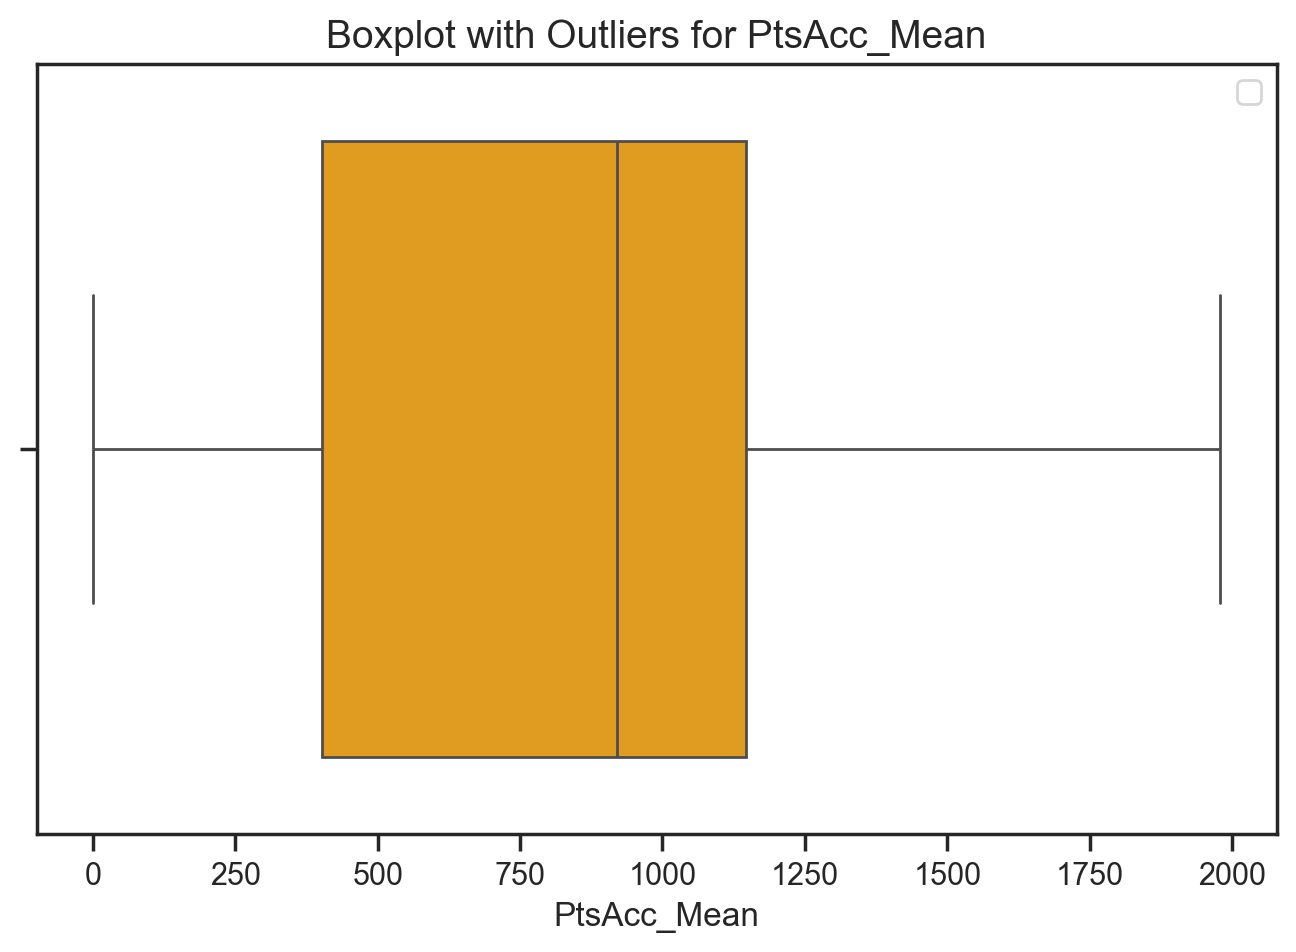

Column: PtsRed_Sum - Number of Outliers: 190
Column: PtsRed_Sum - % of Outliers: 1.15%



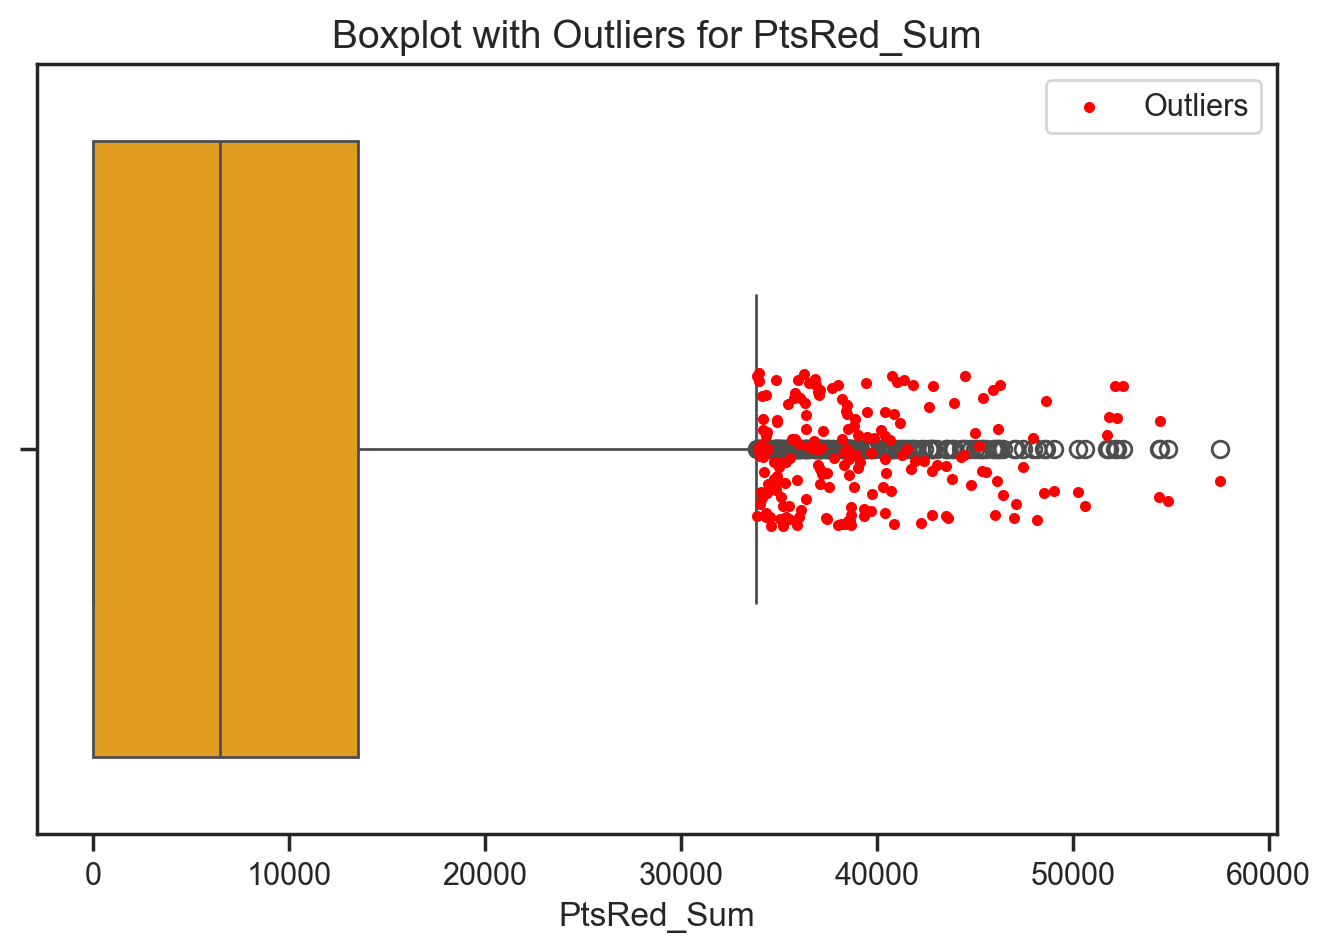

Column: PtsRed_Mean - Number of Outliers: 190
Column: PtsRed_Mean - % of Outliers: 1.15%



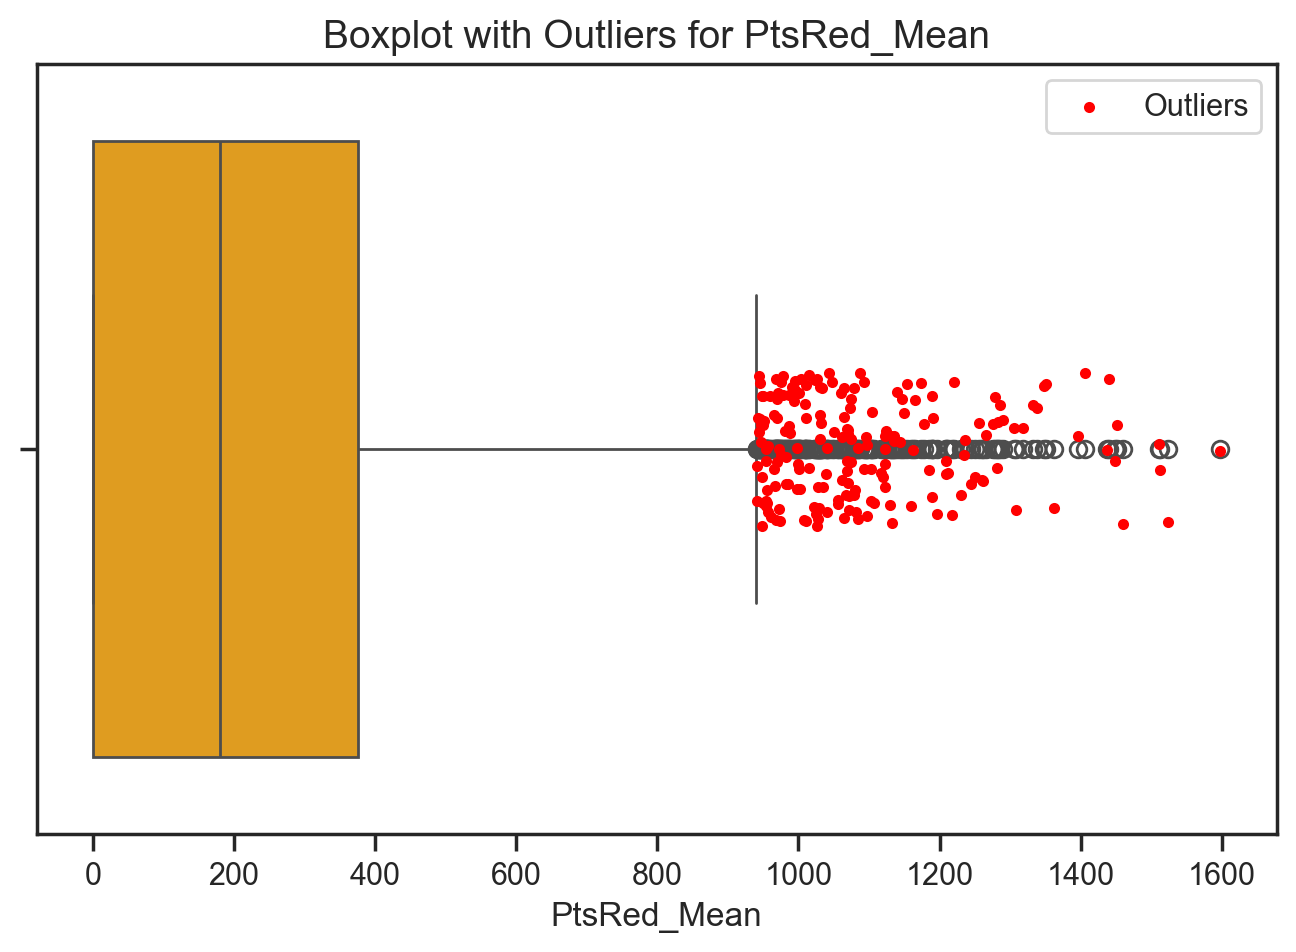

Column: CostPts_Sum - Number of Outliers: 187
Column: CostPts_Sum - % of Outliers: 1.13%



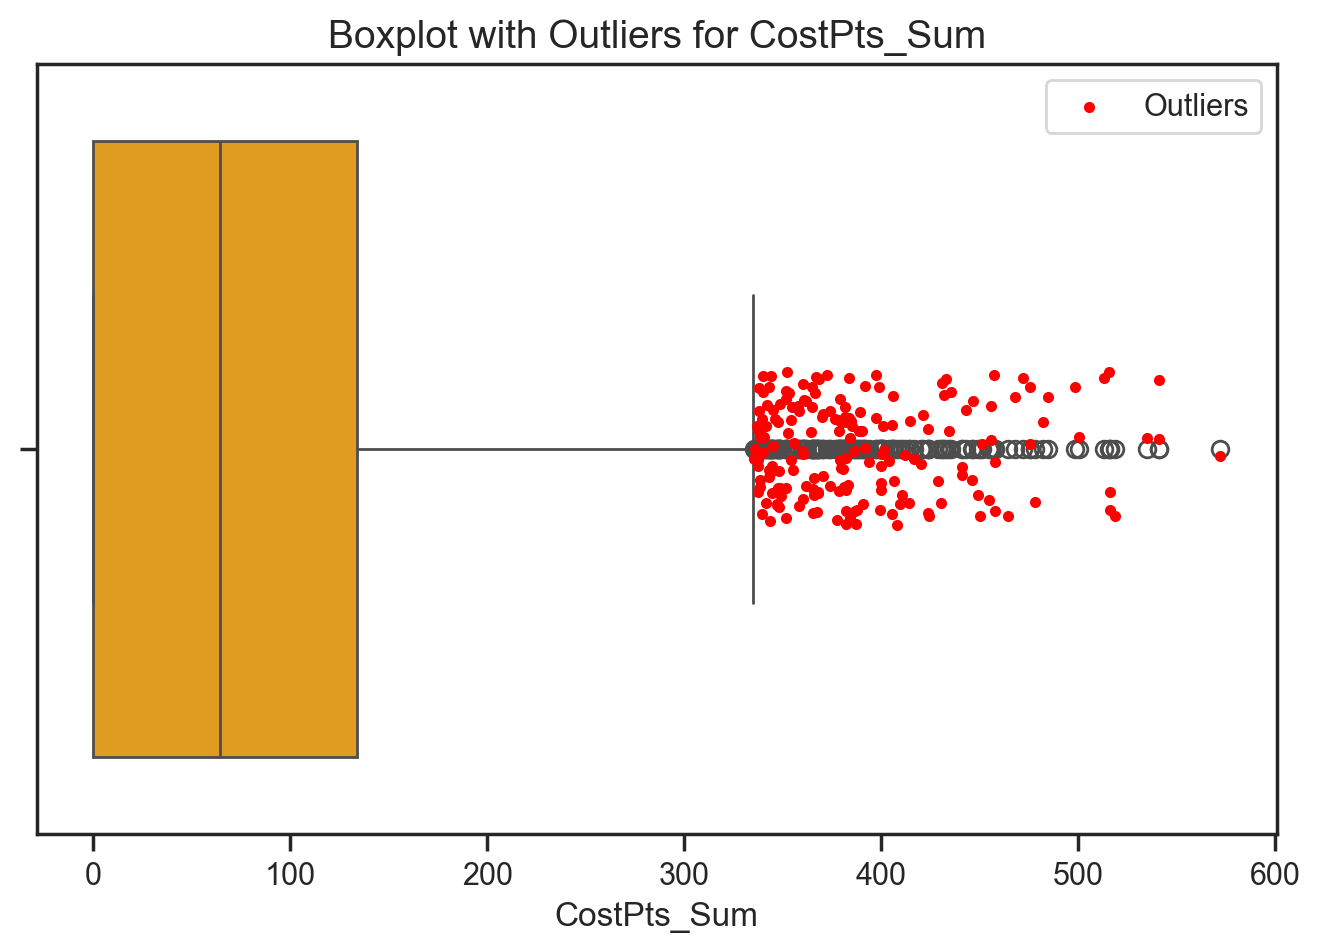

Column: CostPts_Mean - Number of Outliers: 187
Column: CostPts_Mean - % of Outliers: 1.13%



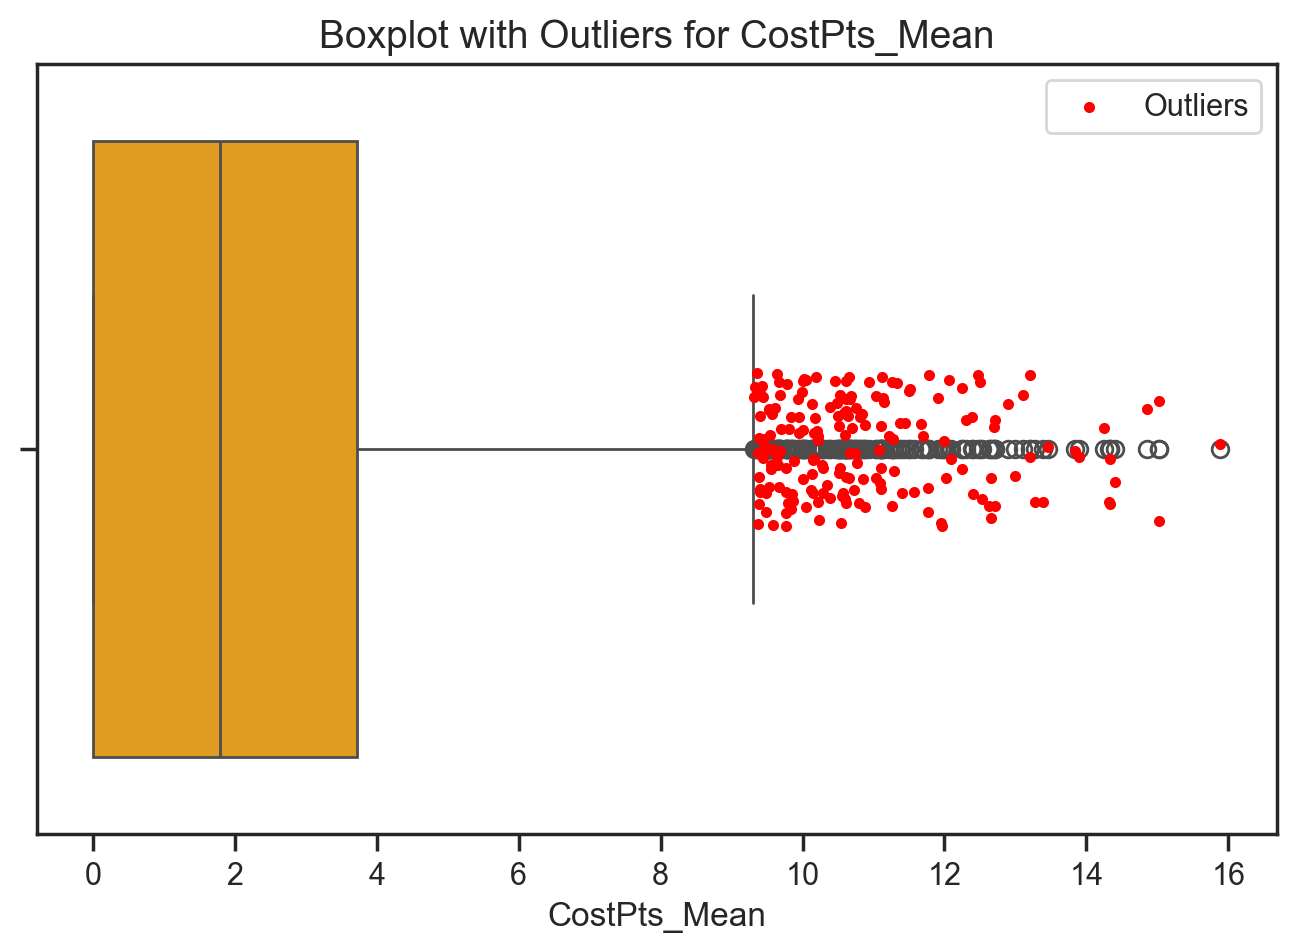

Column: PointsEfficiency - Number of Outliers: 408
Column: PointsEfficiency - % of Outliers: 2.46%



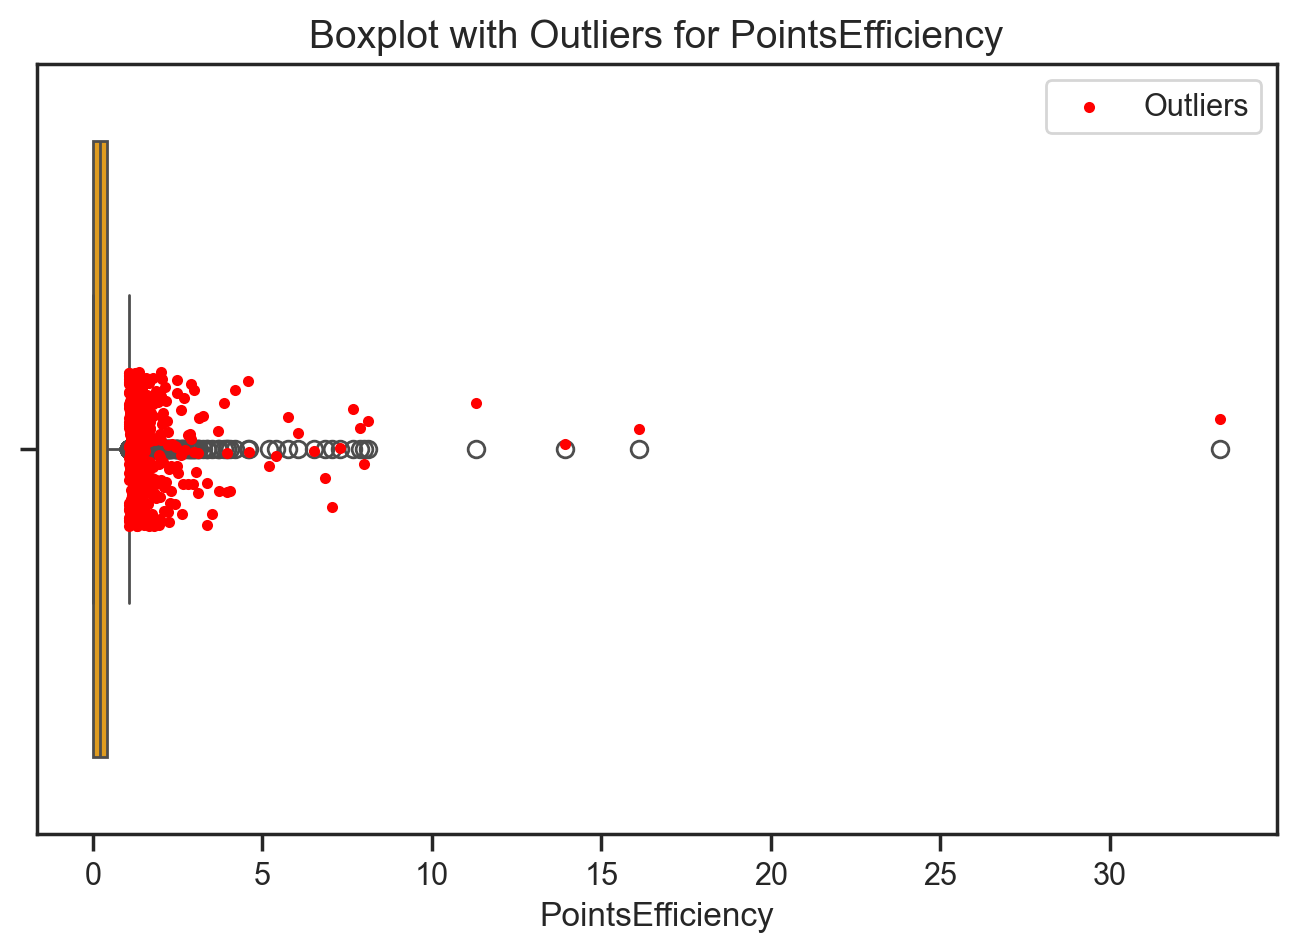

Column: DistPerFlight - Number of Outliers: 1956
Column: DistPerFlight - % of Outliers: 11.80%



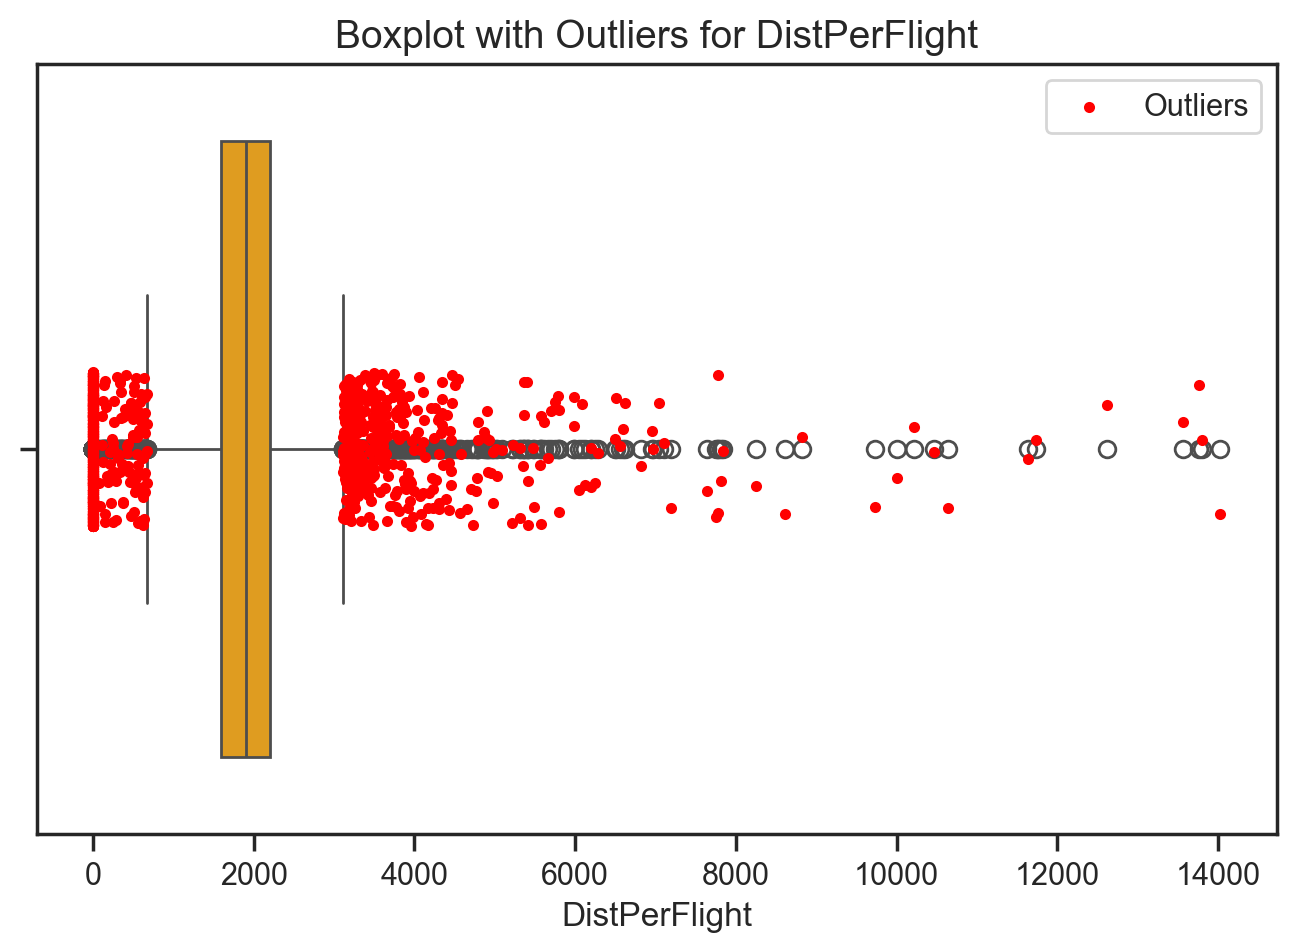

,Column,Num_Outliers,Pct_Outliers
0,Customer Lifetime Value,1460,8.808978
1,Flights_Max,1630,9.834681
2,FlightsComp_Sum,18,0.108604
3,FlightsComp_Mean,18,0.108604
4,DistKM_Max,1808,10.908652
5,PtsRed_Sum,190,1.146374
6,PtsRed_Mean,190,1.146374
7,CostPts_Sum,187,1.128273
8,CostPts_Mean,187,1.128273
9,PointsEfficiency,408,2.461687


In [1607]:
detect_outliers_iqr(df_agg_merged[df_agg_merged_out], 0.001)

<h3> PointsEfficiency

In [1608]:
df_agg_merged.loc[df_agg_merged['PointsEfficiency']> 1, ['Loyalty#', 'Customer Lifetime Value', 'Income', 'Days_sub', 'Flights_Sum', 'DistKM_Sum', 'PtsAcc_Sum', 'PtsRed_Sum', 'PointsEfficiency']]

,Loyalty#,Customer Lifetime Value,Income,Days_sub,Flights_Sum,DistKM_Sum,PtsAcc_Sum,PtsRed_Sum,PointsEfficiency
74,501704,3974.86,0,2067,193.0,376675.4,37657.84,45023.5,1.195594
78,688524,3980.42,98333,2105,128.0,268011.7,26796.27,40394.0,1.507449
86,984713,3997.48,0,148,15.0,27142.0,2713.00,4552.0,1.677847
102,890753,4025.10,0,484,92.0,94183.1,9411.61,11561.5,1.228430
150,355331,4145.02,0,2002,281.0,328911.6,32883.06,34855.7,1.059990
...,...,...,...,...,...,...,...,...,...
16499,149841,32864.40,90783,243,38.0,118441.0,11841.00,12127.0,1.024153
16507,737604,33473.35,33190,2368,113.0,247871.5,24781.75,28511.7,1.150512
16549,753864,40224.01,48587,171,9.0,17427.0,1741.00,3703.0,2.126939
16550,969719,40235.97,77143,245,5.0,11768.6,1176.46,8295.4,7.051153


We are going to remove the observations where pointsefficiency is higher than 1, because having more points redeemed than accumulated is not normal. Maybe its not a mistake because customers can have points accumulated from outside of the time period of this dataset, but we will remove them to reduce potencial noise.

In [1609]:
df_agg_merged = df_agg_merged[df_agg_merged['PointsEfficiency'] <= 1]

Column: PointsEfficiency - Number of Outliers: 0
Column: PointsEfficiency - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_79732\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


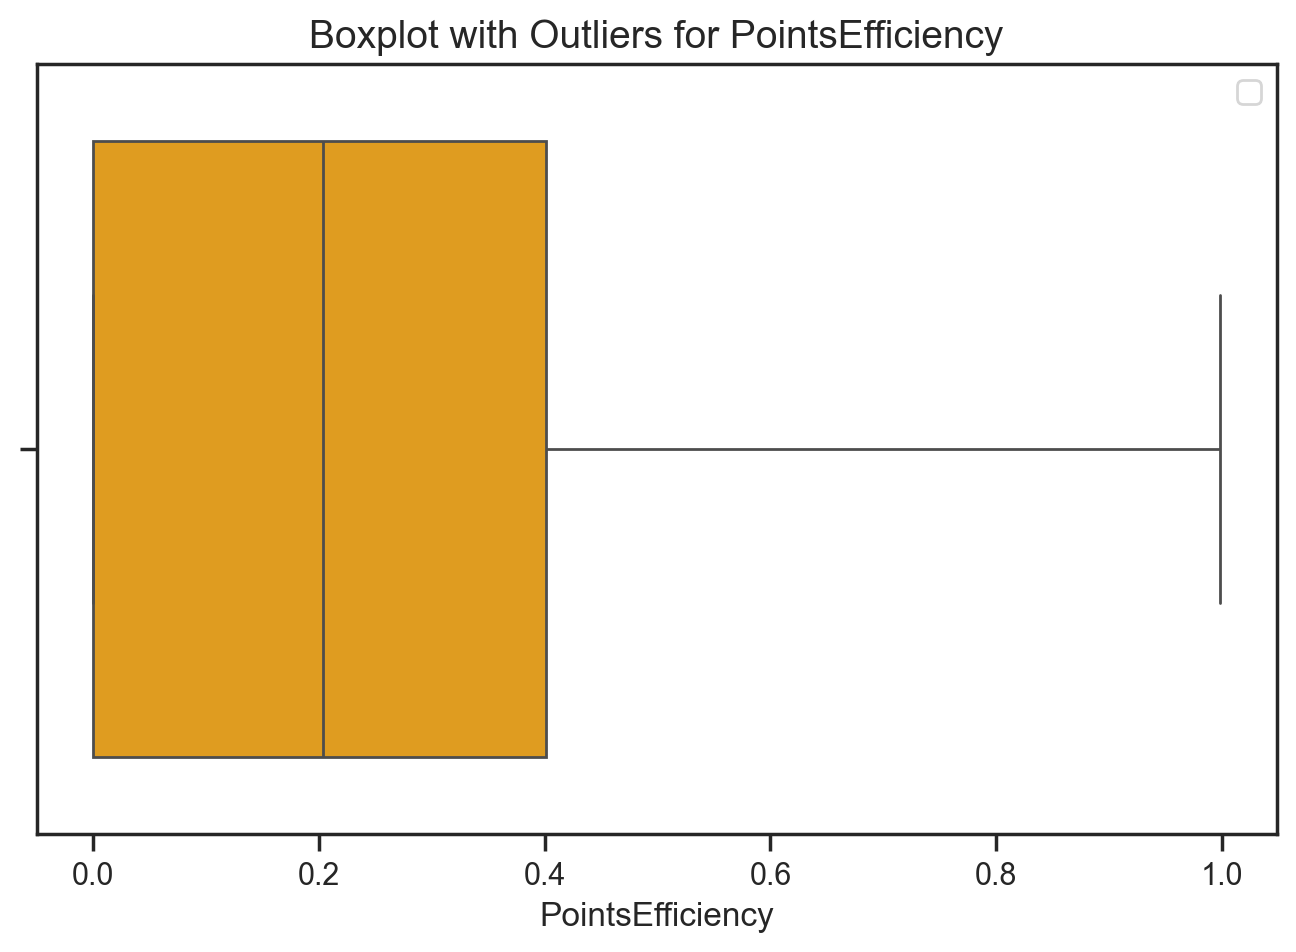

,Column,Num_Outliers,Pct_Outliers


In [1610]:
pointsefficiency = ['PointsEfficiency']
detect_outliers_iqr(df_agg_merged[pointsefficiency], 0.001)

<h3>DistPerFlight

In [1611]:
df_agg_merged.loc[df_agg_merged['DistPerFlight']>8000, ['Loyalty#', 'Flights_Sum', 'DistKM_Sum', 'DistPerFlight']]

,Loyalty#,Flights_Sum,DistKM_Sum,DistPerFlight
2074,443557,2.0,23267.0,11633.50
2254,295795,2.0,19998.0,9999.00
6612,353308,4.0,32980.0,8245.00
7539,305572,1.0,10463.0,10463.00
8428,472921,3.0,25851.0,8617.00
9591,840659,4.0,46958.0,11739.50
11064,278059,2.0,21275.0,10637.50
11346,731254,1.0,10216.0,10216.00
12286,808341,2.0,28057.0,14028.50
12759,430221,6.0,52914.0,8819.00


These values are high and can affect clustering algorithms. But these clients travel a lot and this means that they are valuable customers to AIAI, therefore, we will try to mitigate the impact by a log transformation or robust scalling 

Log-Transform

In [1612]:
df_agg_merged["DistPerFlight_log"] = np.log1p(df_agg_merged["DistPerFlight"])

<h3>Customer Lifetime Value

In [1613]:
df_agg_merged.loc[df_agg_merged['Customer Lifetime Value']>50000, ['Customer Lifetime Value', 'Income', 'Days_sub', 'Flights_Sum', 'DistKM_Sum', 'PtsAcc_Sum', 'PtsRed_Sum', 'PointsEfficiency']]

,Customer Lifetime Value,Income,Days_sub,Flights_Sum,DistKM_Sum,PtsAcc_Sum,PtsRed_Sum,PointsEfficiency
4065,51016.07,25167,902,169.0,491965.9,49188.39,8905.3,0.181045
4066,51426.25,84650,244,21.0,71013.0,7100.00,0.0,0.000000
4067,52811.49,0,372,49.0,88399.0,8838.00,4225.0,0.478049
4068,55277.45,40740,68,12.0,4104.0,410.00,0.0,0.000000
4069,56675.94,77237,1366,230.0,469220.7,46912.27,35839.3,0.763964
4070,57520.50,48367,331,209.0,414025.5,41394.35,10106.2,0.244144
4071,58166.55,61321,1025,145.0,250238.3,25016.63,9132.0,0.365037
4072,58753.88,24964,851,37.0,66859.0,6685.00,0.0,0.000000
4073,61850.19,0,2000,129.0,231506.5,23146.75,0.0,0.000000
4074,66025.75,33481,546,144.0,231571.6,23150.86,0.0,0.000000


These observations represent high-value customers, we will take the same approach we took with DistPerFlight.

LogTransform

In [1614]:
df_agg_merged["Customer_Lifetime_Value_log"] = np.log1p(df_agg_merged["Customer Lifetime Value"])

<h3>Customers with Flights_Sum == 0 and customer lifetime value > 0

In [1615]:
df_agg_merged.loc[(df_agg_merged['Flights_Sum'] == 0) & (df_agg_merged['Customer Lifetime Value'] > 0),
                    ['Customer Lifetime Value', 'Income', 'Days_sub', 'Flights_Sum', 'Flights_Mean', 'DistKM_Sum', 'DistKM_Mean', 'PtsAcc_Sum', 'PtsAcc_Mean', 'PtsRed_Sum', 'PtsRed_Mean']].shape

(1470, 11)

In [1616]:
df_agg_merged.loc[(df_agg_merged['Flights_Sum'] == 0) & (df_agg_merged['Customer Lifetime Value'] > 0),
                    ['Customer Lifetime Value', 'Income', 'Days_sub', 'Flights_Sum', 'Flights_Mean', 'DistKM_Sum', 'DistKM_Mean', 'PtsAcc_Sum', 'PtsAcc_Mean', 'PtsRed_Sum', 'PtsRed_Mean']].sample(10)

,Customer Lifetime Value,Income,Days_sub,Flights_Sum,Flights_Mean,DistKM_Sum,DistKM_Mean,PtsAcc_Sum,PtsAcc_Mean,PtsRed_Sum,PtsRed_Mean
7540,7474.61,44186,2395,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3729,19393.21,70503,67,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6692,5575.20,18892,669,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2725,8838.09,82664,244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10692,2513.97,50450,245,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8427,9414.94,15741,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15383,9783.63,0,243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
793,5028.84,0,244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
149,4144.87,64478,2463,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13999,6273.91,18577,242,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


This doesn't mean that these are errors, this just means that these customers haven't done any flight since joining the loyalty program. To confirm that, we can see that most of them have low number of Days_sub.

## Encoding of categorical features

We will encode the categorical features using the OHE.

In [1617]:
df_agg_merged.columns

Index(['Loyalty#', 'Province or State', 'City', 'Education', 'Income',
       'Marital Status', 'LoyaltyStatus', 'Customer Lifetime Value',
       'EnrollmentType', 'Days_sub', 'Flights_Sum', 'Flights_Mean',
       'Flights_Max', 'FlightsComp_Sum', 'FlightsComp_Mean', 'DistKM_Sum',
       'DistKM_Mean', 'DistKM_Max', 'PtsAcc_Sum', 'PtsAcc_Mean', 'PtsRed_Sum',
       'PtsRed_Mean', 'CostPts_Sum', 'CostPts_Mean', 'PointsEfficiency',
       'DistPerFlight', 'DistPerFlight_log', 'Customer_Lifetime_Value_log'],
      dtype='object')

In [1618]:
non_metric_features_agg = ['City',	'Province or State',
                       		'Education',	'Marital Status',
                        	'LoyaltyStatus',	'EnrollmentType']

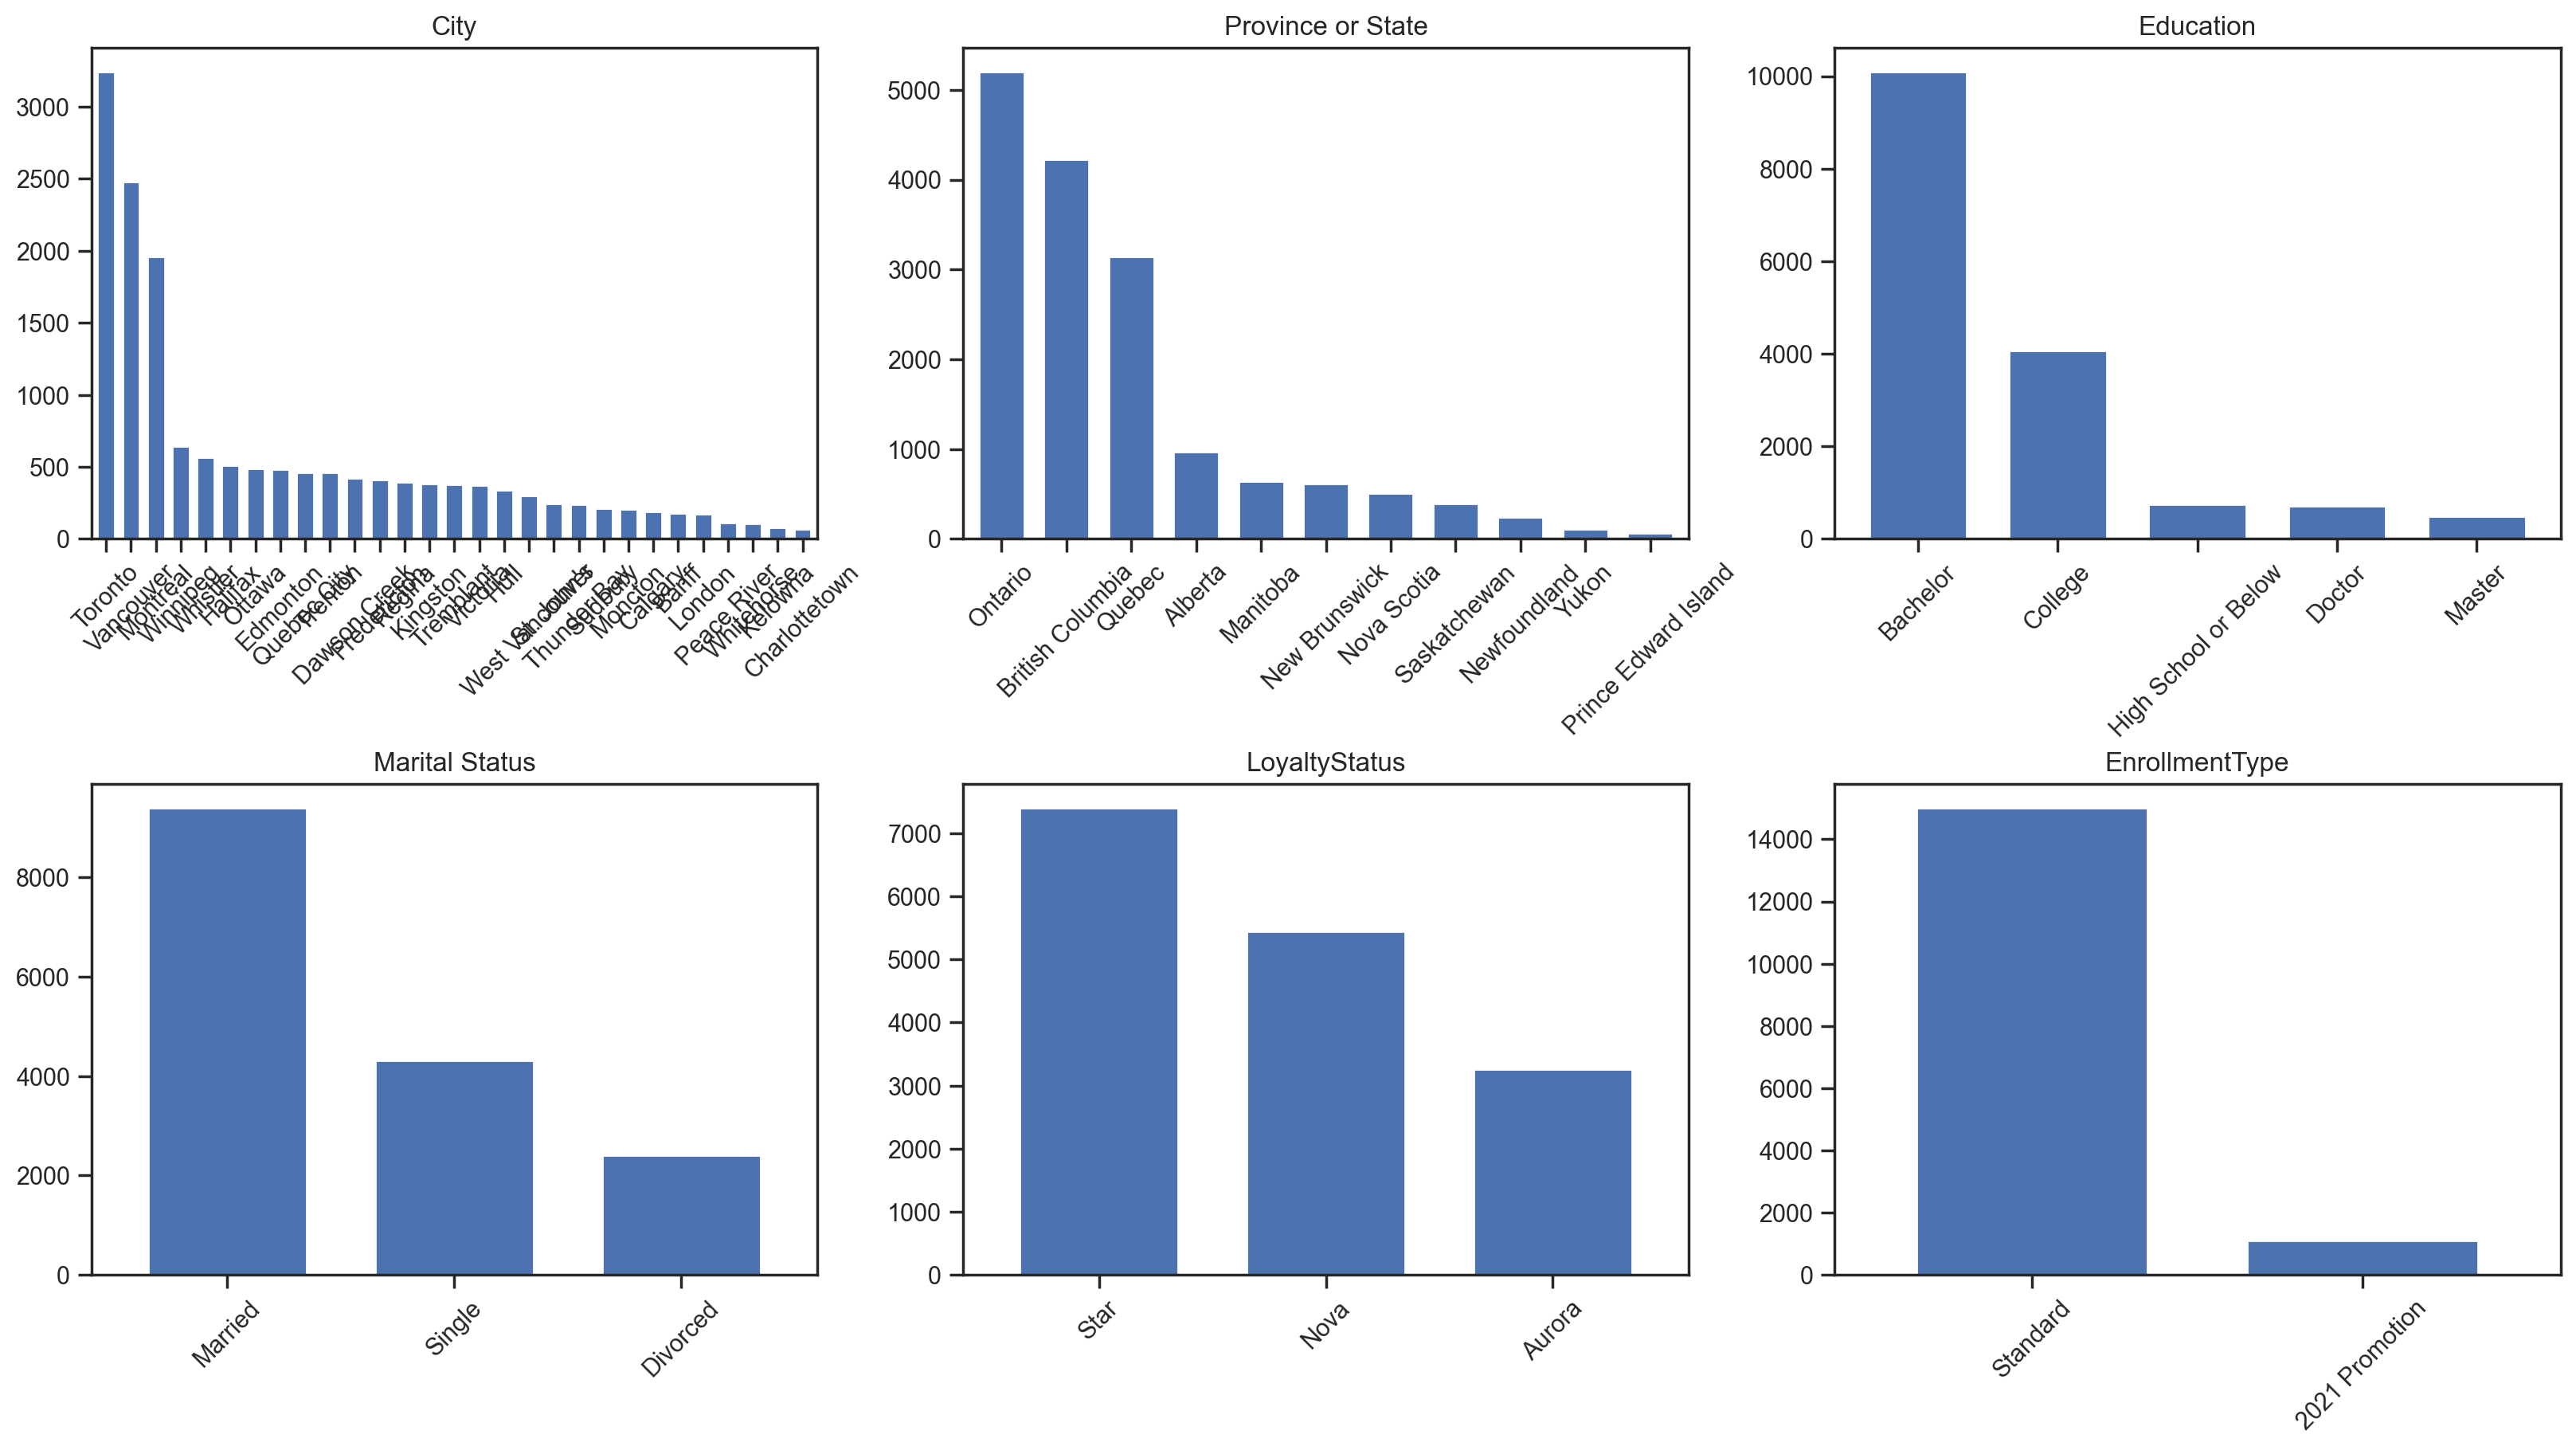

In [1619]:
fig, axes = plt.subplots(
    2,
    ceil(len(non_metric_features_agg) / 2),
    figsize=(20,10))

for ax, feat in zip(axes.flatten(), non_metric_features_agg):
    df_agg_merged[feat].value_counts().plot.bar(ax=ax, width=.7)
    ax.set_title(feat)
    ax.set_xlabel(None)
    ax.set_ylabel(None) 
    ax.tick_params(axis='x', rotation=45)

plt.subplots_adjust(hspace=0.5)
plt.show()

We are going to use the One hot Encondig for the features "Gender", "Marital Status" and "Enrollment Type". For "Education" since we can order them from the least level of studies to the highest, we are using the Ordinal Enconding. Due to its high cardinality, for "Province or State" and "City" we are using the Frequency Enconding.

In [1620]:
df_ohc = df_agg_merged.copy()

categorical_features = ['Marital Status', 'EnrollmentType']

ohc = OneHotEncoder(sparse_output=False)

ohc_feat = ohc.fit_transform(df_ohc[categorical_features])

ohc_feat_names = ohc.get_feature_names_out(categorical_features)

ohc_df = pd.DataFrame(ohc_feat, index=df_ohc.index, columns=ohc_feat_names)

df_ohc = pd.concat([df_ohc, ohc_df], axis=1)

df_final = df_ohc.copy()
# Dropping categorical Variables
df_final = df_final.drop(columns=['Marital Status', 'EnrollmentType'])

In [1621]:
df_final = df_final.set_index('Loyalty#')

In [1622]:
education_order = [
    'High School or Below',
    'College',
    'Bachelor',
    'Master',
    'Doctor'
]

encoder_ed = OrdinalEncoder(categories=[education_order])

df_final['Education_Encoded'] = encoder_ed.fit_transform(df_final[['Education']])

df_final['Education_Encoded'] = df_final['Education_Encoded'] / (len(education_order) - 1)

df_final = df_final.drop(columns=['Education'])


In [1623]:
province_freq = df_final['Province or State'].value_counts()
df_final['Province_FE'] = df_final['Province or State'].map(province_freq)

city_freq = df_final['City'].value_counts()
df_final['City_FE'] = df_final['City'].map(city_freq)

df_final = df_final.drop(columns=['Province or State', 'City'])

df_final[['Province_FE', 'City_FE']].head()


,Province_FE,City_FE
Loyalty#,,
480934,5205,3245
549612,967,484
429460,4222,2480
608370,5205,3245
530508,3141,342


## Scaling

In [1624]:
merged_agg_metric = ['Income','Customer_Lifetime_Value_log','Days_sub', 'Flights_Sum',
       'Flights_Mean', 'Flights_Max', 'FlightsComp_Sum', 'FlightsComp_Mean',
       'DistKM_Sum', 'DistKM_Mean', 'DistKM_Max', 'PtsAcc_Sum', 'PtsAcc_Mean',
       'PtsRed_Sum', 'PtsRed_Mean', 'CostPts_Sum', 'CostPts_Mean',
       'PointsEfficiency', 'DistPerFlight_log','Province_FE','City_FE']

In [1625]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the data and transform it
df_agg_scaled = scaler.fit_transform(df_final[merged_agg_metric])

# Convert scaled data into a DataFrame with the same index as the original DataFrame
df_agg_scaled_df = pd.DataFrame(df_agg_scaled, columns=merged_agg_metric, index=df_final.index)

# Select the non-metric features from the original data
non_metric_features_agg = df_final.drop(columns=merged_agg_metric)

# Combine the scaled metric features with the non-metric features (ensure no new rows are added)
df_final = pd.concat([df_agg_scaled_df, non_metric_features_agg], axis=1)

df_final.sample(5)

,Income,Customer_Lifetime_Value_log,Days_sub,Flights_Sum,Flights_Mean,Flights_Max,FlightsComp_Sum,FlightsComp_Mean,DistKM_Sum,DistKM_Mean,...,City_FE,LoyaltyStatus,Customer Lifetime Value,DistPerFlight,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,EnrollmentType_2021 Promotion,EnrollmentType_Standard,Education_Encoded
Loyalty#,,,,,,,,,,,,,,,,,,,,,
324066,-1.245134,-0.332957,-1.275971,-1.458788,-1.458788,-0.289011,-1.527040,-1.527040,-1.662150,-1.662150,...,-0.831226,Nova,5058.93,749.310345,0.0,1.0,0.0,0.0,1.0,0.25
392619,-1.245134,0.163844,0.917316,0.111465,0.111465,1.178734,0.675217,0.675217,0.131537,0.131537,...,1.473809,Star,6993.84,1967.845912,0.0,0.0,1.0,0.0,1.0,0.25
102788,0.158677,0.875769,-1.112902,0.848276,0.848276,0.261393,0.495441,0.495441,0.702037,0.702037,...,0.399910,Nova,11124.21,1843.150000,0.0,0.0,1.0,1.0,0.0,0.50
175954,0.501325,1.986103,-0.021694,0.969065,0.969065,0.261393,1.394321,1.394321,1.337665,1.337665,...,0.399910,Nova,22940.38,2211.610000,0.0,1.0,0.0,0.0,1.0,0.50
444652,-1.245134,1.000624,-0.835683,-0.709898,-0.709898,0.628330,-0.628159,-0.628159,-0.563476,-0.563476,...,-1.082137,Aurora,12067.46,2198.578022,0.0,0.0,1.0,0.0,1.0,0.25


## DBSCAN Multivariate Outliers ???

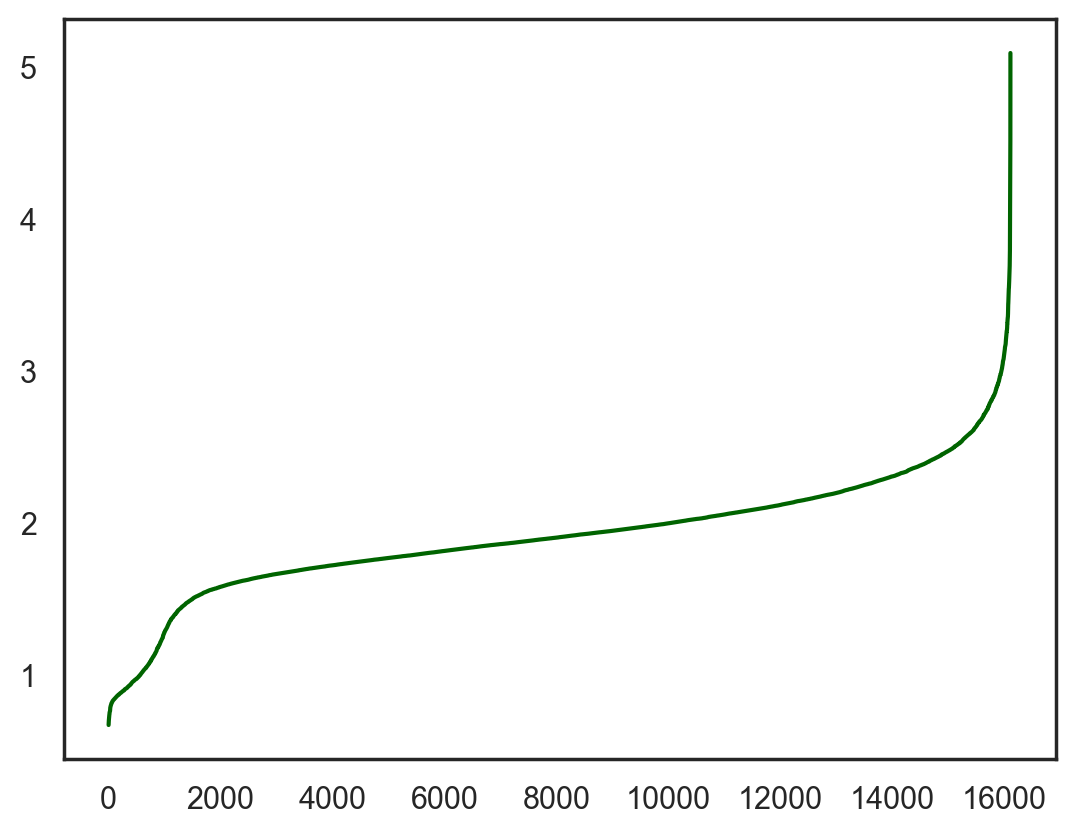

In [1626]:
# K-distance graph to find out the right epsilon value
sns.set_style("white")
neigh = NearestNeighbors(n_neighbors=47)
neigh.fit(df_final[merged_agg_metric])
distances, _ = neigh.kneighbors(df_final[merged_agg_metric])
distances = np.sort(distances[:, -1])
plt.plot(distances, color='darkgreen')
plt.show()

## Feature Selection

In [1627]:
df_final = df_final.drop('Customer Lifetime Value', axis=1)
df_final = df_final.drop('DistPerFlight', axis=1)

**Checking for multiculinearity**

We will indentify pairs of features that are highly correlated. First, we will define a treshold of |0.8|.



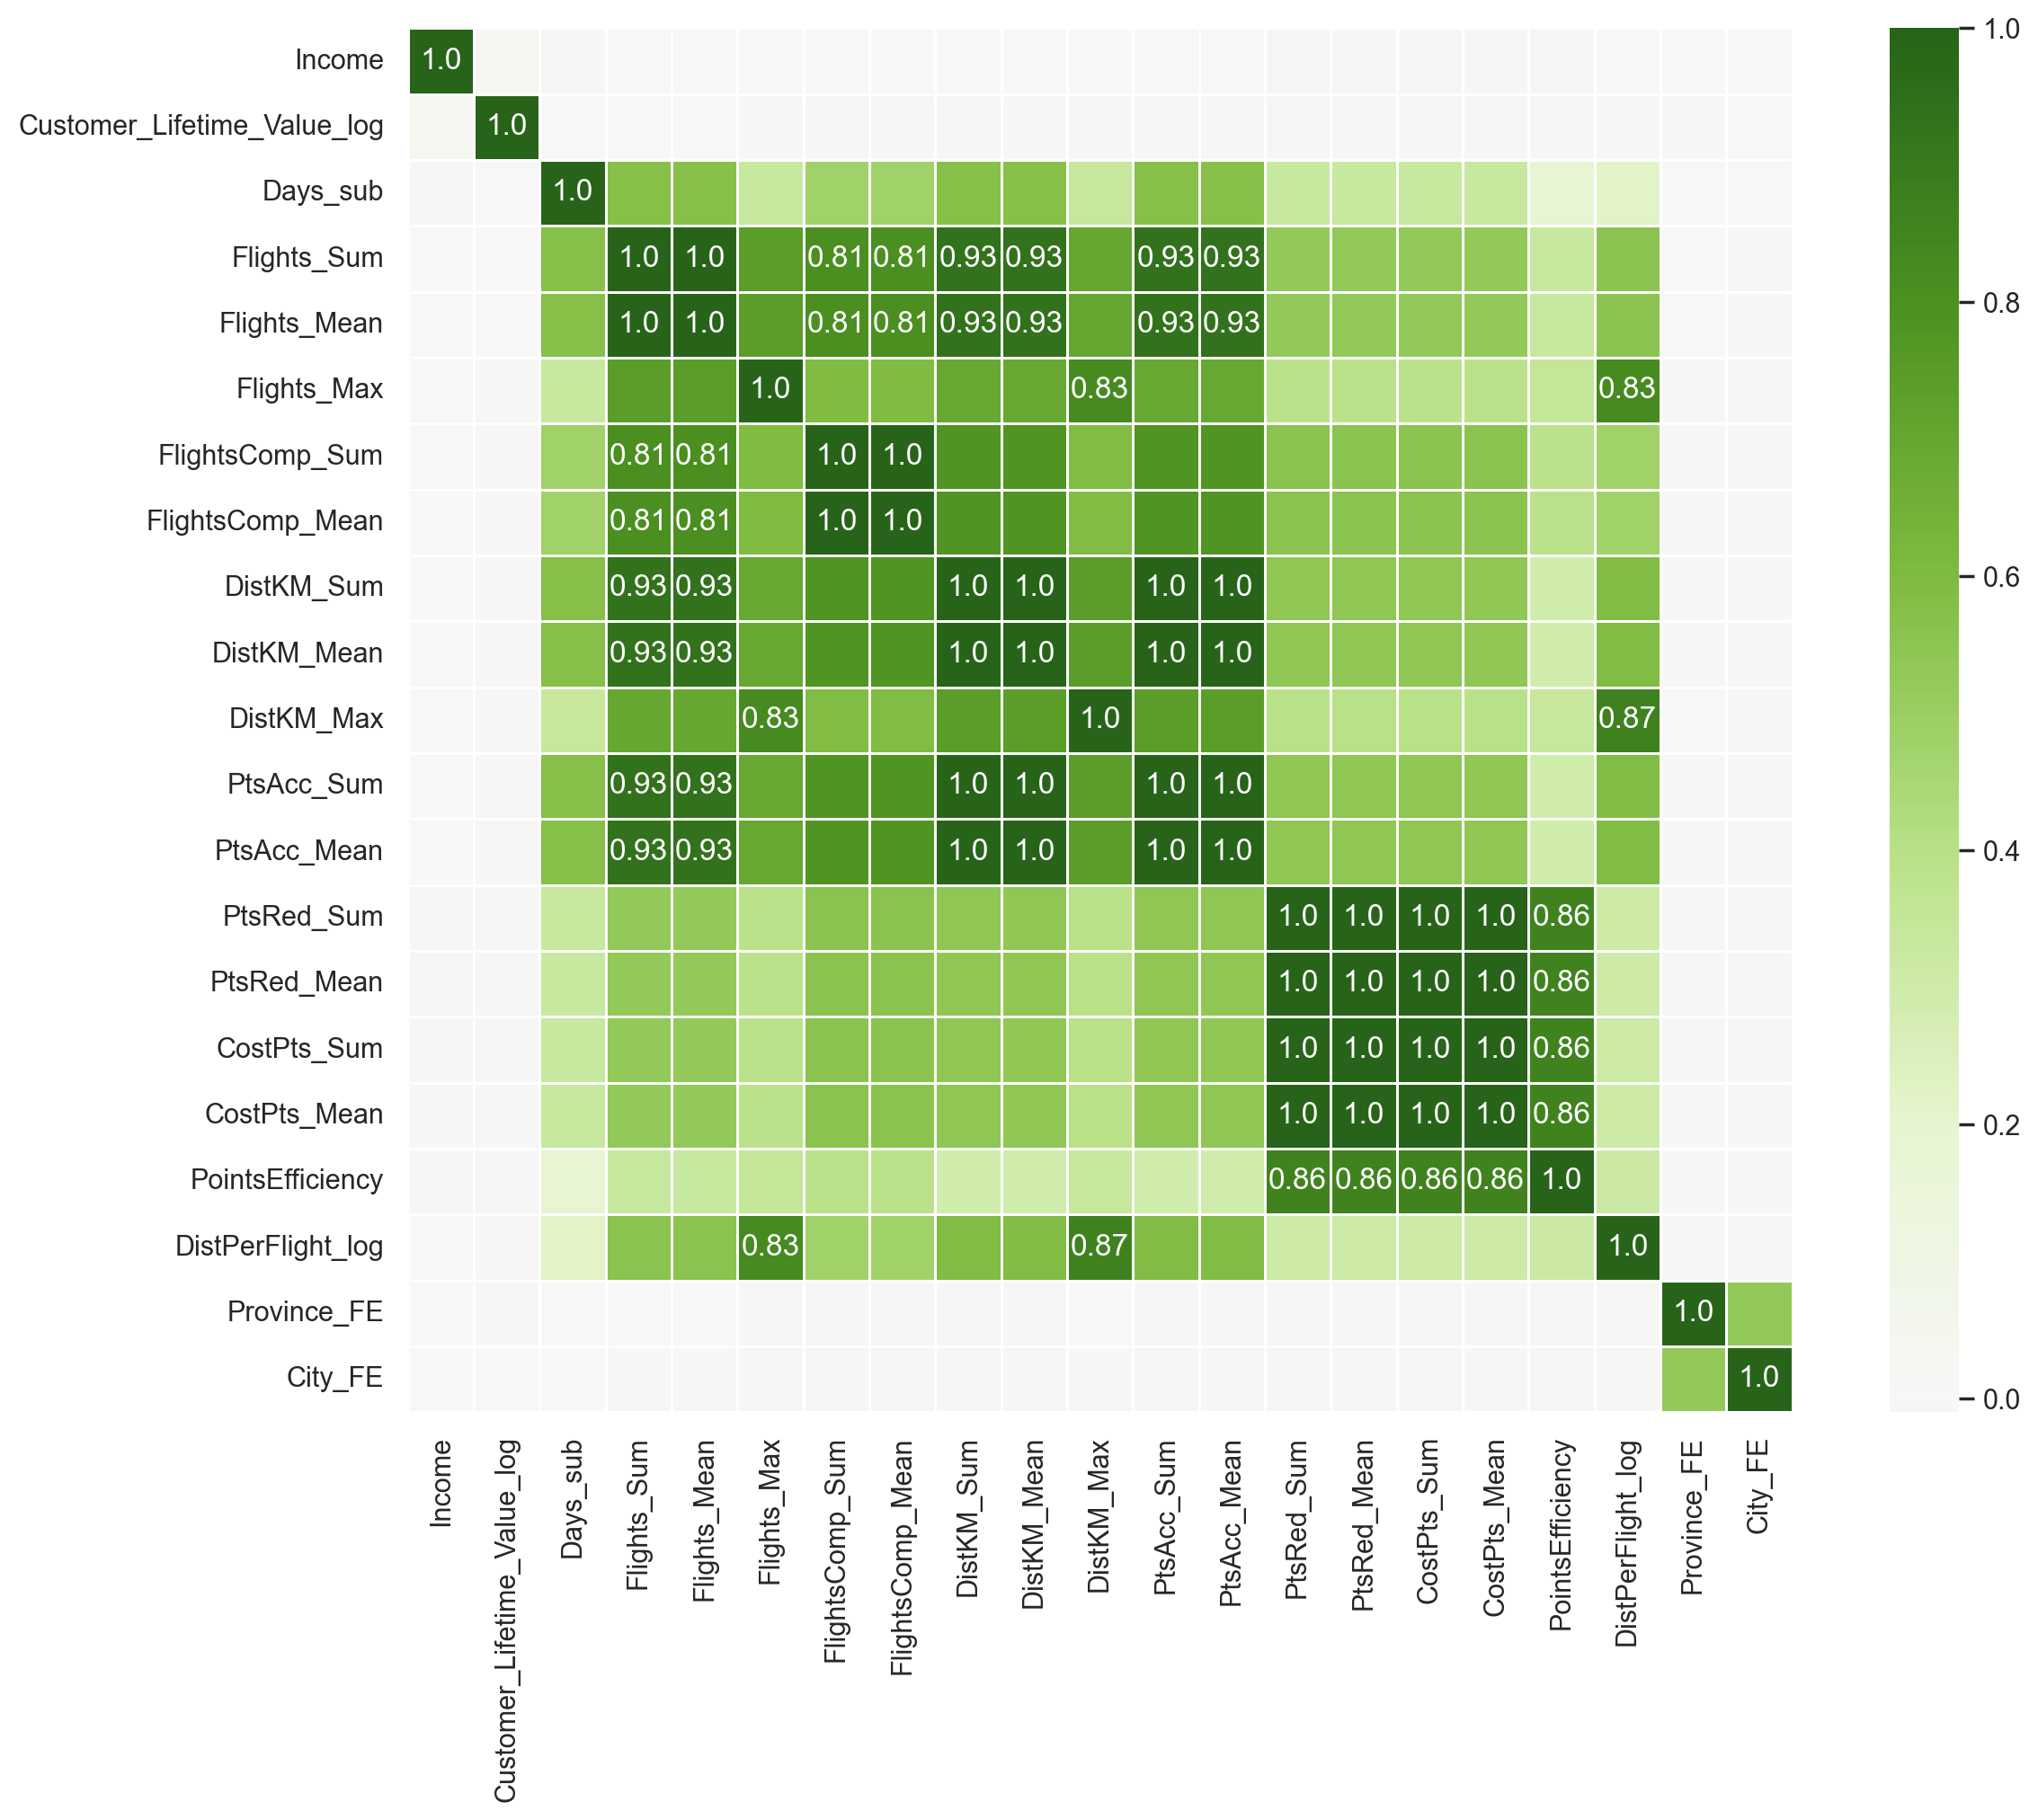

In [1628]:
plt.figure(figsize=(14,10))
corr = df_final[merged_agg_metric].corr()
corr = corr.round(2)

sns.heatmap(
    corr,
    center = 0,
    cmap='PiYG',
    annot=np.where(np.absolute(corr) >= 0.8, corr.values, np.full(corr.values.shape, "")),
    fmt='s',
    square=True,
    linewidths=.5,
)
plt.show()

In [1629]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

corr_pairs = corr.where(mask).stack().reset_index()
corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']

high_corr_pairs = corr_pairs[corr_pairs['Correlation'] > 0.8]

high_corr_pairs

,Feature1,Feature2,Correlation
57,Flights_Sum,Flights_Mean,1.00
59,Flights_Sum,FlightsComp_Sum,0.81
60,Flights_Sum,FlightsComp_Mean,0.81
61,Flights_Sum,DistKM_Sum,0.93
62,Flights_Sum,DistKM_Mean,0.93
64,Flights_Sum,PtsAcc_Sum,0.93
65,Flights_Sum,PtsAcc_Mean,0.93
75,Flights_Mean,FlightsComp_Sum,0.81
76,Flights_Mean,FlightsComp_Mean,0.81
77,Flights_Mean,DistKM_Sum,0.93


For the flights group of features, since thry're all high correlated, the one that makes more sence to keep is "FlightsSum".

For the Distance group of features, the same conclusion as for the previous one, we must keep "DistKM_Sum".

For the Points Accumulated group of features, same conclusion as the previous ones, we must kepp "PtsAcc_Sum".

For the Points Redeemed group of features, same conclusion as the previous ones, we must kepp "PtsRed_Sum".

For the Cost Points group of features, same conclusion as the previous ones, we must kepp "CostPts_Sum".

For the Companions Flights group of features, same conclusion as the previous ones, we must kepp "FlightsComp_Sum".


In [1630]:
features_to_drop = [
    'Flights_Mean',
    'Flights_Max',
    'FlightsComp_Mean',
    'DistKM_Mean',
    'DistKM_Max',
    'PtsAcc_Mean',
    'PtsRed_Mean',
    'CostPts_Mean'
]

df_final = df_final.drop(columns=[col for col in features_to_drop if col in df_final.columns])
merged_agg_metric = [col for col in merged_agg_metric if col not in features_to_drop]
df_final.columns


Index(['Income', 'Customer_Lifetime_Value_log', 'Days_sub', 'Flights_Sum',
       'FlightsComp_Sum', 'DistKM_Sum', 'PtsAcc_Sum', 'PtsRed_Sum',
       'CostPts_Sum', 'PointsEfficiency', 'DistPerFlight_log', 'Province_FE',
       'City_FE', 'LoyaltyStatus', 'Marital Status_Divorced',
       'Marital Status_Married', 'Marital Status_Single',
       'EnrollmentType_2021 Promotion', 'EnrollmentType_Standard',
       'Education_Encoded'],
      dtype='object')

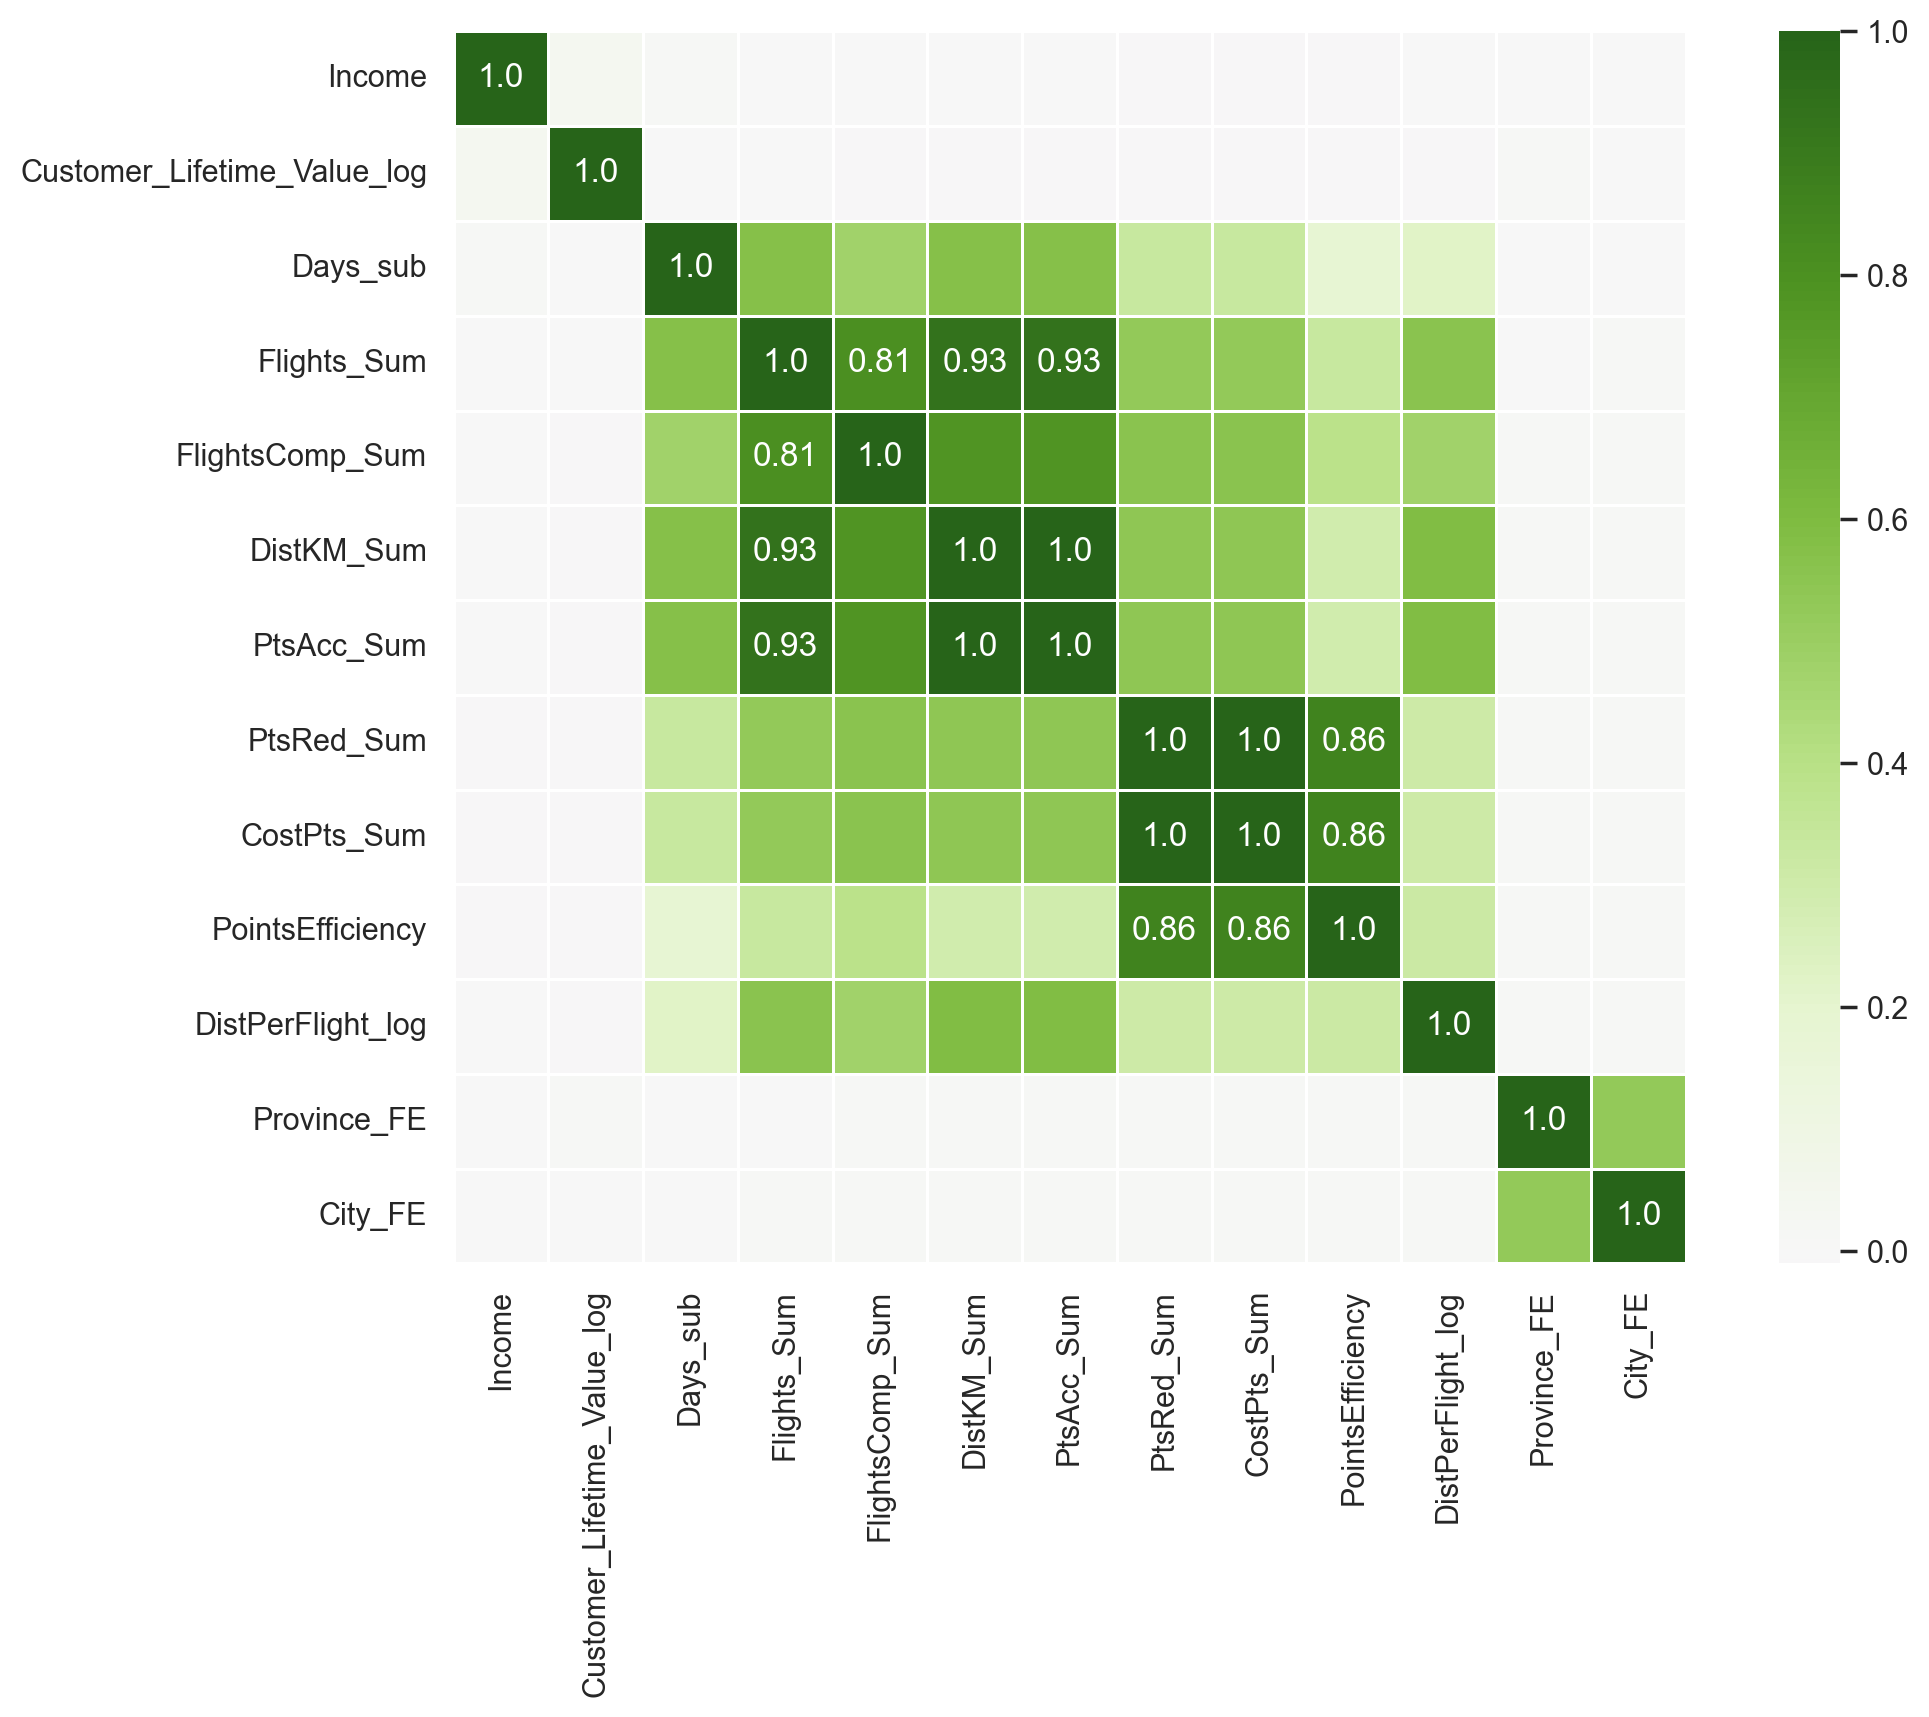

In [1631]:
plt.figure(figsize=(12,8))
corr = df_final[merged_agg_metric].corr()
corr = corr.round(2)

sns.heatmap(
    corr,
    center = 0,
    cmap='PiYG',
    annot=np.where(np.absolute(corr) >= 0.8, corr.values, np.full(corr.values.shape, "")),
    fmt='s',
    square=True,
    linewidths=.5,
)
plt.show()

In [1632]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

corr_pairs = corr.where(mask).stack().reset_index()
corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']

high_corr_pairs = corr_pairs[corr_pairs['Correlation'] > 0.8]

high_corr_pairs

,Feature1,Feature2,Correlation
33,Flights_Sum,FlightsComp_Sum,0.81
34,Flights_Sum,DistKM_Sum,0.93
35,Flights_Sum,PtsAcc_Sum,0.93
50,DistKM_Sum,PtsAcc_Sum,1.00
63,PtsRed_Sum,CostPts_Sum,1.00
64,PtsRed_Sum,PointsEfficiency,0.86
68,CostPts_Sum,PointsEfficiency,0.86


We still observe some redundant features. Since "Flights_Sum" and "PtsAcc_Sum" have a strong correlation, we will only keep `Flights_Sum`. Since "PtsRed_Sum" and "CostPts_Sum" have a perfect correlation, we will only keep `PtsRed_Sum`.  "PointsEfficiency" still has a strong correlation with "PtsRed_Sum" so we decided to keep `PointsEfficiency`since this gives us more information. We decided to keep both "Flights_Sum" and "FlightsComp_Sum" even having more than 0.8 because it can still give us some useful information but, between "Flights_Sum" and "DistKm_Sum" we will only keep "Flights_Sum".

In [1633]:
features_to_drop = [
'CostPts_Sum', 'PtsAcc_Sum', 'PtsRed_Sum','DistKM_Sum'
]

df_final = df_final.drop(columns=[col for col in features_to_drop if col in df_final.columns])
merged_agg_metric = [col for col in merged_agg_metric if col not in features_to_drop]
df_final.columns

Index(['Income', 'Customer_Lifetime_Value_log', 'Days_sub', 'Flights_Sum',
       'FlightsComp_Sum', 'PointsEfficiency', 'DistPerFlight_log',
       'Province_FE', 'City_FE', 'LoyaltyStatus', 'Marital Status_Divorced',
       'Marital Status_Married', 'Marital Status_Single',
       'EnrollmentType_2021 Promotion', 'EnrollmentType_Standard',
       'Education_Encoded'],
      dtype='object')

### Univariance

In [1634]:
round(df_final[merged_agg_metric].var(), 6)

Income                         1.000062
Customer_Lifetime_Value_log    1.000062
Days_sub                       1.000062
Flights_Sum                    1.000062
FlightsComp_Sum                1.000062
PointsEfficiency               1.000062
DistPerFlight_log              1.000062
Province_FE                    1.000062
City_FE                        1.000062
dtype: float64

We should not remove any of the features.

### Categorical (encoded features)

In [1635]:
df_final[['City_FE','Province_FE']].corr()

,City_FE,Province_FE
City_FE,1.00000,0.53458
Province_FE,0.53458,1.00000


Since they don't have a high correlation value, we should keep both.

Our final features are:

In [1636]:
df_final.columns

Index(['Income', 'Customer_Lifetime_Value_log', 'Days_sub', 'Flights_Sum',
       'FlightsComp_Sum', 'PointsEfficiency', 'DistPerFlight_log',
       'Province_FE', 'City_FE', 'LoyaltyStatus', 'Marital Status_Divorced',
       'Marital Status_Married', 'Marital Status_Single',
       'EnrollmentType_2021 Promotion', 'EnrollmentType_Standard',
       'Education_Encoded'],
      dtype='object')

# Clustering

**Suggested Prespectives :**

1. Economic (Value Based): Based on customers capacity, profitability, and the level of activation in the program.

In [1637]:
df_E = df_final[['Income', 'Customer_Lifetime_Value_log','PointsEfficiency']]

2. Behavior-based : Based on flight frequency, distance, type of trip, and seniority in the program.

In [1638]:
df_B = df_final[['Flights_Sum','FlightsComp_Sum','Days_sub','DistPerFlight_log','EnrollmentType_2021 Promotion', 'EnrollmentType_Standard']]

3. Demographic (profile-based) : Based on personal characteristics and location influence customer behavior.

In [1639]:
df_D = df_final[['Education_Encoded','Marital Status_Divorced',
       'Marital Status_Married', 'Marital Status_Single','Province_FE','City_FE']]

LoyaltyStatus  

## Demographic profile-based

In [1640]:
D_features = ['Education_Encoded','Marital Status_Divorced',
       'Marital Status_Married', 'Marital Status_Single','Province_FE','City_FE']

### Hierarchical Clustering

In [1715]:
def get_ss(df, feats):
    """
    Calculate the sum of squares (SS) for the given DataFrame.

    The sum of squares is computed as the sum of the variances of each column
    multiplied by the number of non-NA/null observations minus one.

    Parameters:
    df (pandas.DataFrame): The input DataFrame for which the sum of squares is to be calculated.
    feats (list of str): A list of feature column names to be used in the calculation.

    Returns:
    float: The sum of squares of the DataFrame.
    """
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    
    return ss 


def get_ssb(df, feats, label_col):
    """
    Calculate the between-group sum of squares (SSB) for the given DataFrame.
    The between-group sum of squares is computed as the sum of the squared differences
    between the mean of each group and the overall mean, weighted by the number of observations
    in each group.

    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column in the DataFrame that contains the group labels.
    
    Returns
    float: The between-group sum of squares of the DataFrame.
    """
    
    ssb_i = 0
    for i in np.unique(df[label_col]):
        df_ = df.loc[:, feats]
        X_ = df_.values
        X_k = df_.loc[df[label_col] == i].values
        
        ssb_i += (X_k.shape[0] * (np.square(X_k.mean(axis=0) - X_.mean(axis=0))) )

    ssb = np.sum(ssb_i)
    

    return ssb


def get_ssw(df, feats, label_col):
    """
    Calculate the sum of squared within-cluster distances (SSW) for a given DataFrame.

    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing cluster labels.

    Returns:
    float: The sum of squared within-cluster distances (SSW).
    """
    feats_label = feats+[label_col]

    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats), 
        include_groups=False
        )

    return df_k.sum()

In [1716]:
def get_rsq(df, feats, label_col):
    """
    Calculate the R-squared value for a given DataFrame and features.

    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data.
    feats (list): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing the labels or cluster assignments.

    Returns:
    float: The R-squared value, representing the proportion of variance explained by the clustering.
    """

    df_sst_ = get_ss(df, feats)                 # get total sum of squares
    df_ssw_ = get_ssw(df, feats, label_col)     # get ss within
    df_ssb_ = df_sst_ - df_ssw_                 # get ss between

    # r2 = ssb/sst 
    return (df_ssb_/df_sst_)
    

In [1717]:
def get_r2_hc(df, link_method, max_nclus, min_nclus=1, dist="euclidean"):
    """This function computes the R2 for a set of cluster solutions given by the application of a hierarchical method.
    The R2 is a measure of the homogenity of a cluster solution. It is based on SSt = SSw + SSb and R2 = SSb/SSt. 
    
    Parameters:
    df (DataFrame): Dataset to apply clustering
    link_method (str): either "ward", "complete", "average", "single"
    max_nclus (int): maximum number of clusters to compare the methods
    min_nclus (int): minimum number of clusters to compare the methods. Defaults to 1.
    dist (str): distance to use to compute the clustering solution. Must be a valid distance. Defaults to "euclidean".
    
    Returns:
    ndarray: R2 values for the range of cluster solutions
    """
    
    r2 = []  # where we will store the R2 metrics for each cluster solution
    feats = df.columns.tolist()
    
    for i in range(min_nclus, max_nclus+1):  # iterate over desired ncluster range
        
        cluster = AgglomerativeClustering(linkage=link_method, metric=dist, n_clusters=i)
        
        #get cluster labels
        hclabels = cluster.fit_predict(df[feats])
        
        # concat df with labels
        df_concat = pd.concat([df, pd.Series(hclabels, name='labels', index=df.index)], axis=1)  
        
        
        # append the R2 of the given cluster solution
        r2.append(get_rsq(df_concat, feats, 'labels'))
        
    return np.array(r2)

In [1718]:
hc_methods = ["ward", "complete", "average", "single"]
max_nclus = 10

results = []
for link in hc_methods:
    r2 = get_r2_hc(
        df=df_D[D_features], 
        link_method=link, 
        max_nclus=max_nclus, 
        min_nclus=1, 
        dist="euclidean")
    results.append(r2)

r2_hc = np.vstack(results)

KeyboardInterrupt: 

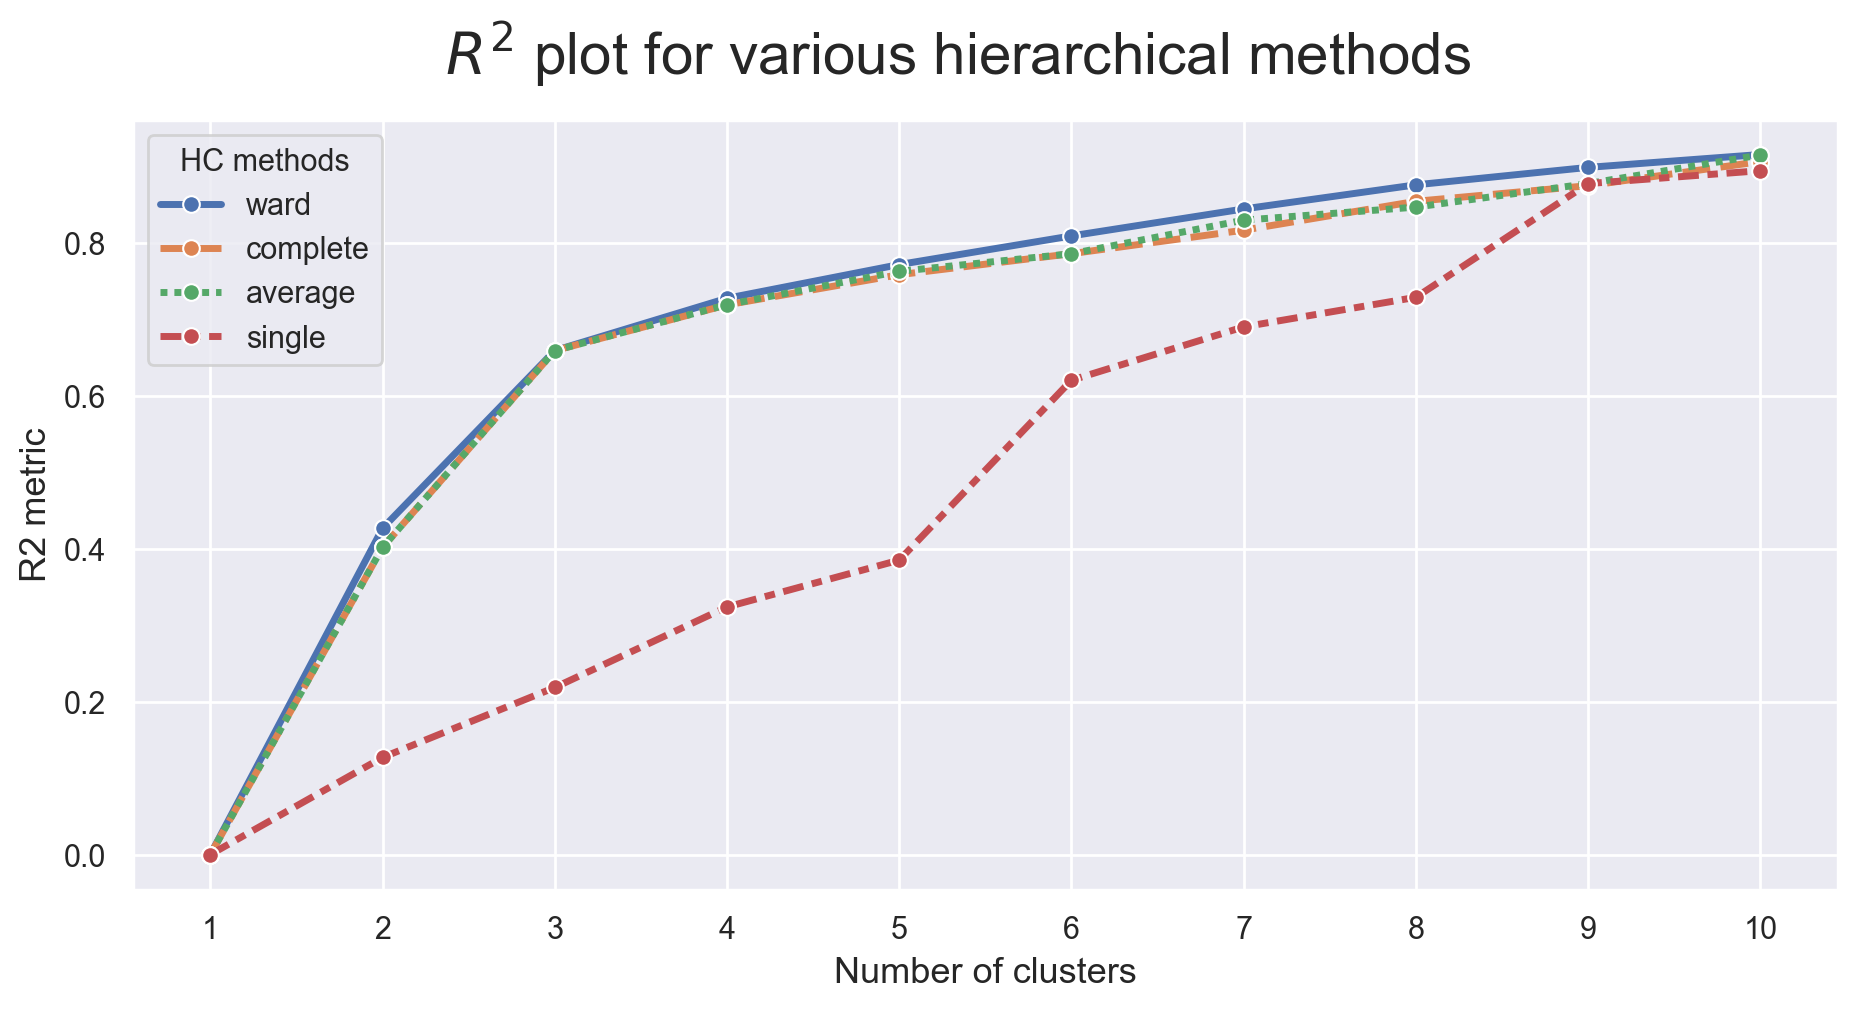

In [ ]:
sns.set()
r2_hc_methods = pd.DataFrame(r2_hc.T, index=range(1, max_nclus + 1), columns=hc_methods)

r2_hc_methods
# Plot data
fig = plt.figure(figsize=(11,5))
sns.lineplot(data=r2_hc_methods, linewidth=2.5, markers=["o"]*4)

# Finalize the plot
plt.legend(title="HC methods", title_fontsize=11)
plt.xticks(range(1, max_nclus + 1))
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("R2 metric", fontsize=13)

fig.suptitle("$R^2$ plot for various hierarchical methods", fontsize=21)

plt.show()

Ward seems to be the best metric, with the best number of clusters 3/4

In [ ]:
# setting distance_threshold=0 and n_clusters=None ensures we compute the full tree
linkage = 'ward' 
distance = 'euclidean' 
n_clusters = None 

hclust = AgglomerativeClustering(linkage=linkage, metric=distance, n_clusters=n_clusters, distance_threshold=0)
hclust.fit_predict(df_D[D_features])

array([16115, 16114, 16113, ...,     1,     2,     0], shape=(16116,))

In [ ]:
from scipy.cluster.hierarchy import linkage

linkage_matrix= linkage(df_D[D_features], method="ward")

In [ ]:
linkage_matrix.shape

(16115, 4)

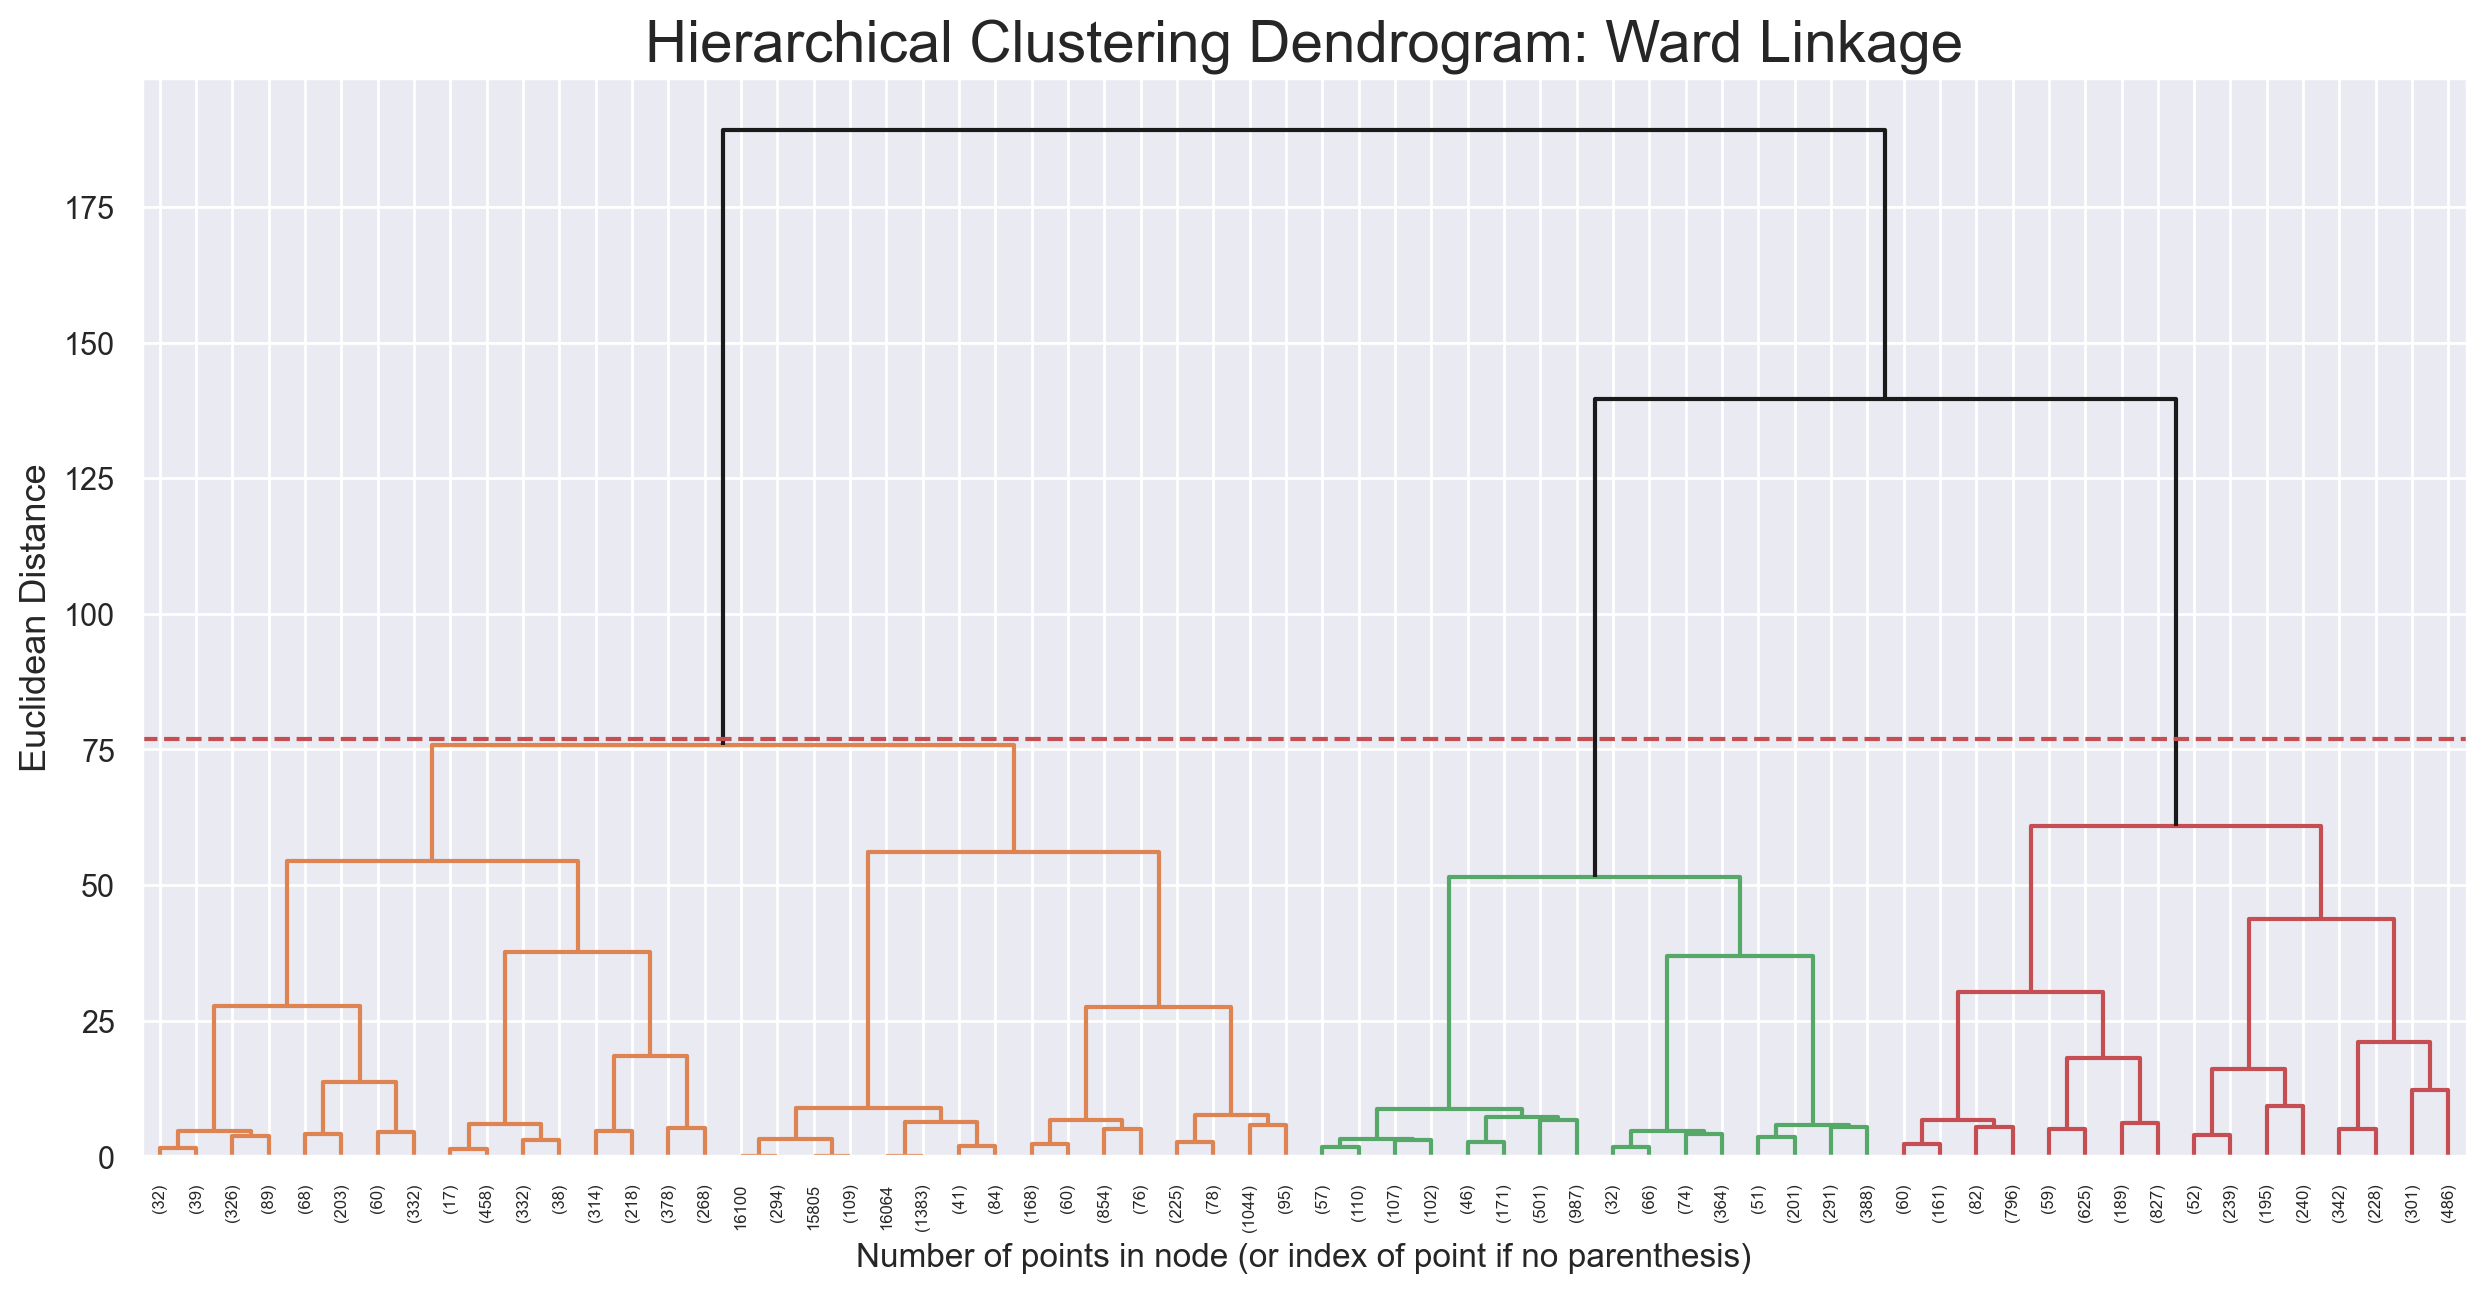

In [1719]:
sns.set()
fig = plt.figure(figsize=(15,7))
# The Dendrogram parameters need to be tuned
Y_THRESHOLD = 77
dendrogram(linkage_matrix, truncate_mode='level', p=5, color_threshold=Y_THRESHOLD, above_threshold_color='k')
    
plt.hlines(Y_THRESHOLD, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram: Ward Linkage', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'{distance.title()} Distance', fontsize=13)
plt.show()

In [1721]:
linkage = 'ward'
distance = 'euclidean'
n_clusters = 4

hc4_clust = AgglomerativeClustering(n_clusters=n_clusters)
hc4_labels = hc4_clust.fit_predict(df_D[D_features])
df_concat = pd.concat([df_D[D_features], 
                       pd.Series(hc4_labels, 
                                 name='cluster_labels', 
                                 index=df_D.index)], 
                    axis=1)

df_concat.groupby('cluster_labels').mean()

,Education_Encoded,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Province_FE,City_FE
cluster_labels,,,,,,
0,0.446538,0.148710,0.573331,0.277960,0.477894,-0.907954
1,0.462284,0.000000,1.000000,0.000000,0.481471,0.993924
2,0.441869,0.151071,0.586528,0.262401,-1.700230,-0.902590
3,0.411491,0.362232,0.000000,0.637768,0.481077,0.992574


In [1722]:
linkage = 'ward'
distance = 'euclidean'
n_clusters = 3

hc3_clust = AgglomerativeClustering(n_clusters=n_clusters)
hc3_labels = hc3_clust.fit_predict(df_D[D_features])
df_concat = pd.concat([df_D[D_features], 
                       pd.Series(hc3_labels, 
                                 name='cluster_labels', 
                                 index=df_D.index)], 
                    axis=1)

df_concat.groupby('cluster_labels').mean()

,Education_Encoded,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Province_FE,City_FE
cluster_labels,,,,,,
0,0.441322,0.149493,0.587302,0.263206,0.481308,0.993367
1,0.446538,0.148710,0.573331,0.277960,0.477894,-0.907954
2,0.441869,0.151071,0.586528,0.262401,-1.700230,-0.902590


In [1723]:
pd.crosstab(
    pd.Series(hc3_labels, name='hc3_labels', index=df_D.index),
    pd.Series(hc4_labels, name='hc4_labels', index=df_D.index),
    
    )

hc4_labels,0,1,2,3
hc3_labels,,,,
0,0,4514,0,3172
1,4882,0,0,0
2,0,0,3548,0


In [1724]:
linkage = "ward" 
distance = "euclidean" 
n_clusters = 4
hclust = AgglomerativeClustering(linkage=linkage, metric=distance, n_clusters=n_clusters)

hc_labels = hclust.fit_predict(df_D[D_features])

In [1725]:
df_concat = pd.concat([
    df_D[D_features], 
    pd.Series(hc_labels, name='cluster_labels', index=df_D.index)
    ], 
    axis=1)
df_concat.groupby('cluster_labels').mean().T

cluster_labels,0,1,2,3
Education_Encoded,0.446538,0.462284,0.441869,0.411491
Marital Status_Divorced,0.148710,0.000000,0.151071,0.362232
Marital Status_Married,0.573331,1.000000,0.586528,0.000000
Marital Status_Single,0.277960,0.000000,0.262401,0.637768
Province_FE,0.477894,0.481471,-1.700230,0.481077
City_FE,-0.907954,0.993924,-0.902590,0.992574


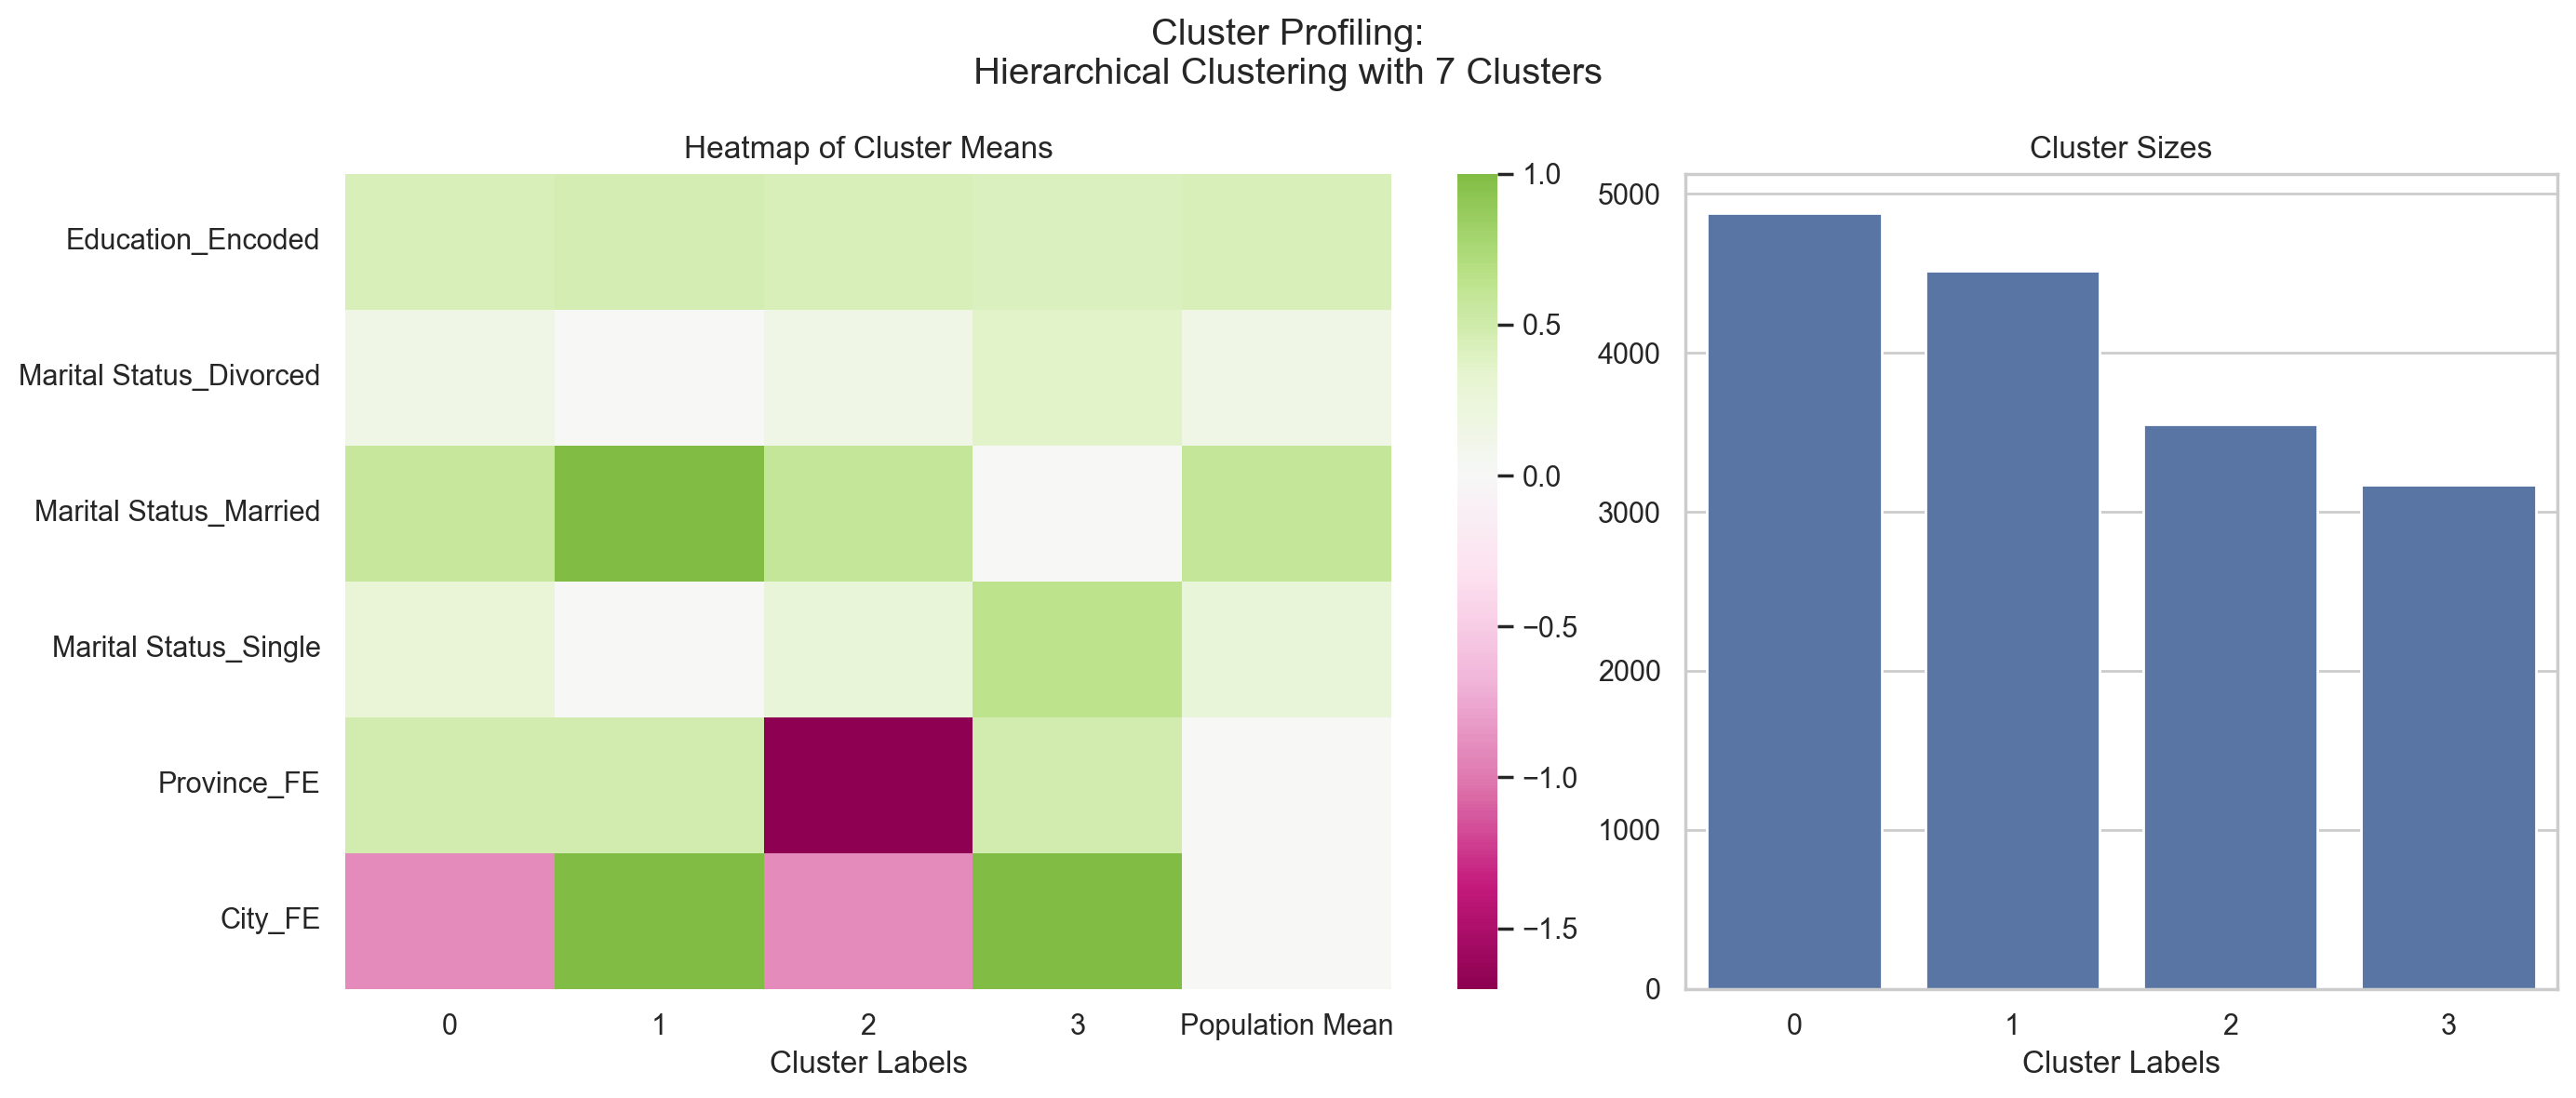

In [1726]:
hc_profile = df_concat.groupby('cluster_labels').mean().T
pop_mean = df_D[D_features].mean()

df_concat_pop = pd.concat([hc_profile, 
                           pd.Series(pop_mean, 
                                        index=hc_profile.index, 
                                        name='Population Mean'
                            )
                           ],
                           axis=1)

sns.set(style="whitegrid")
label_counts = df_concat['cluster_labels'].value_counts().sort_index()

fig, axes = plt.subplots(1,2, figsize=(14,6), width_ratios=[.6,.4], tight_layout=True)

sns.heatmap(df_concat_pop, ax=axes[0], center=0, cmap='PiYG')

axes[0].set_xlabel("Cluster Labels")
axes[0].set_title("Heatmap of Cluster Means")


sns.barplot(x=label_counts.index, y=label_counts.values, ax=axes[1])
axes[1].set_title("Cluster Sizes")
axes[1].set_xlabel("Cluster Labels")

fig.suptitle("Cluster Profiling:\nHierarchical Clustering with 7 Clusters")
plt.show()

In [1727]:
get_rsq(df_concat, D_features, 'cluster_labels')

np.float64(0.7274901877585662)

### SOM

In [1728]:
som_data = df_D[D_features].values

In [1729]:
sm = MiniSom(
    x=8,            # Grid width 
    y=8,            # Grid height   
    input_len=len(D_features),
    sigma=2.0,                           # Neighborhood radius
    learning_rate=0.5,                   # Learning rate
    neighborhood_function='gaussian',
    topology='hexagonal',
    random_seed=42
)

sm.random_weights_init(som_data)

qe_before = sm.quantization_error(som_data)
te_before = sm.topographic_error(som_data)

print(f"Quantization Error (QE): {qe_before:.4f}")
print(f"Topographic Error (TE):  {te_before:.4f}")

c:\Users\Francisco Martins\anaconda3\envs\ml-project\Lib\site-packages\minisom.py:631: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-2 * cross_term + input_data_sq + weights_flat_sq.T)


Quantization Error (QE): 0.1570
Topographic Error (TE):  0.8299


In [1730]:
sm.train_batch(
    som_data, 
    num_iteration=60_000, 
    verbose=False
    )

In [1731]:
qe_after = sm.quantization_error(som_data)
te_after = sm.topographic_error(som_data)

print(f"Quantization Error (QE): {qe_after:.4f}")
print(f"Topographic Error (TE):  {te_after:.4f}")

print(f"QE reduction: {qe_before:.4f} → {qe_after:.4f} ({(1 - qe_after/qe_before)*100:.1f}% improvement)")
print(f"TE reduction: {te_before:.4f} → {te_after:.4f} ({(1 - te_after/te_before)*100:.1f}% improvement)")

Quantization Error (QE): 0.1917
Topographic Error (TE):  0.0017
QE reduction: 0.1570 → 0.1917 (-22.1% improvement)
TE reduction: 0.8299 → 0.0017 (99.8% improvement)


In [1732]:
weights = sm.get_weights()

In [1733]:
def plot_hexagons(som,              # Trained SOM model 
                  sf,               # matplotlib figure object
                  colornorm,        # colornorm
                  matrix_vals,      # SOM weights or
                  label="",         # title for figure
                  cmap=cm.Grays,    # colormap to use
                  annot=False       
                  ):

    
    axs = sf.subplots(1,1)
    
    for i in range(matrix_vals.shape[0]):
        for j in range(matrix_vals.shape[1]):

            wx, wy = som.convert_map_to_euclidean((i,j)) 

            hex = RegularPolygon((wx, wy), 
                                numVertices=6, 
                                radius= np.sqrt(1/3),
                                facecolor=cmap(colornorm(matrix_vals[i, j])), 
                                alpha=1, 
                                edgecolor='white',
                                linewidth=.5)
            axs.add_patch(hex)
            if annot==True:
                annot_val = np.round(matrix_vals[i,j],2)
                if int(annot_val) == annot_val:
                    annot_val = int(annot_val)
                axs.text(wx,wy, annot_val, 
                        ha='center', va='center', 
                        fontsize='x-small')


    ## Remove axes for hex plot
    axs.margins(.05)
    axs.set_aspect('equal')
    axs.axis("off")
    axs.set_title(label)

    

    # ## Add colorbar
    divider = make_axes_locatable(axs)
    ax_cb = divider.append_axes("right", size="5%", pad="0%")

    ## Create a Mappable object
    cmap_sm = plt.cm.ScalarMappable(cmap=cmap, norm=colornorm)
    cmap_sm.set_array([])

    ## Create custom colorbar 
    cb1 = colorbar.Colorbar(ax_cb,
                            orientation='vertical', 
                            alpha=1,
                            mappable=cmap_sm
                            )
    cb1.ax.get_yaxis().labelpad = 6

    # Add colorbar to plot
    sf.add_axes(ax_cb)

    return sf 

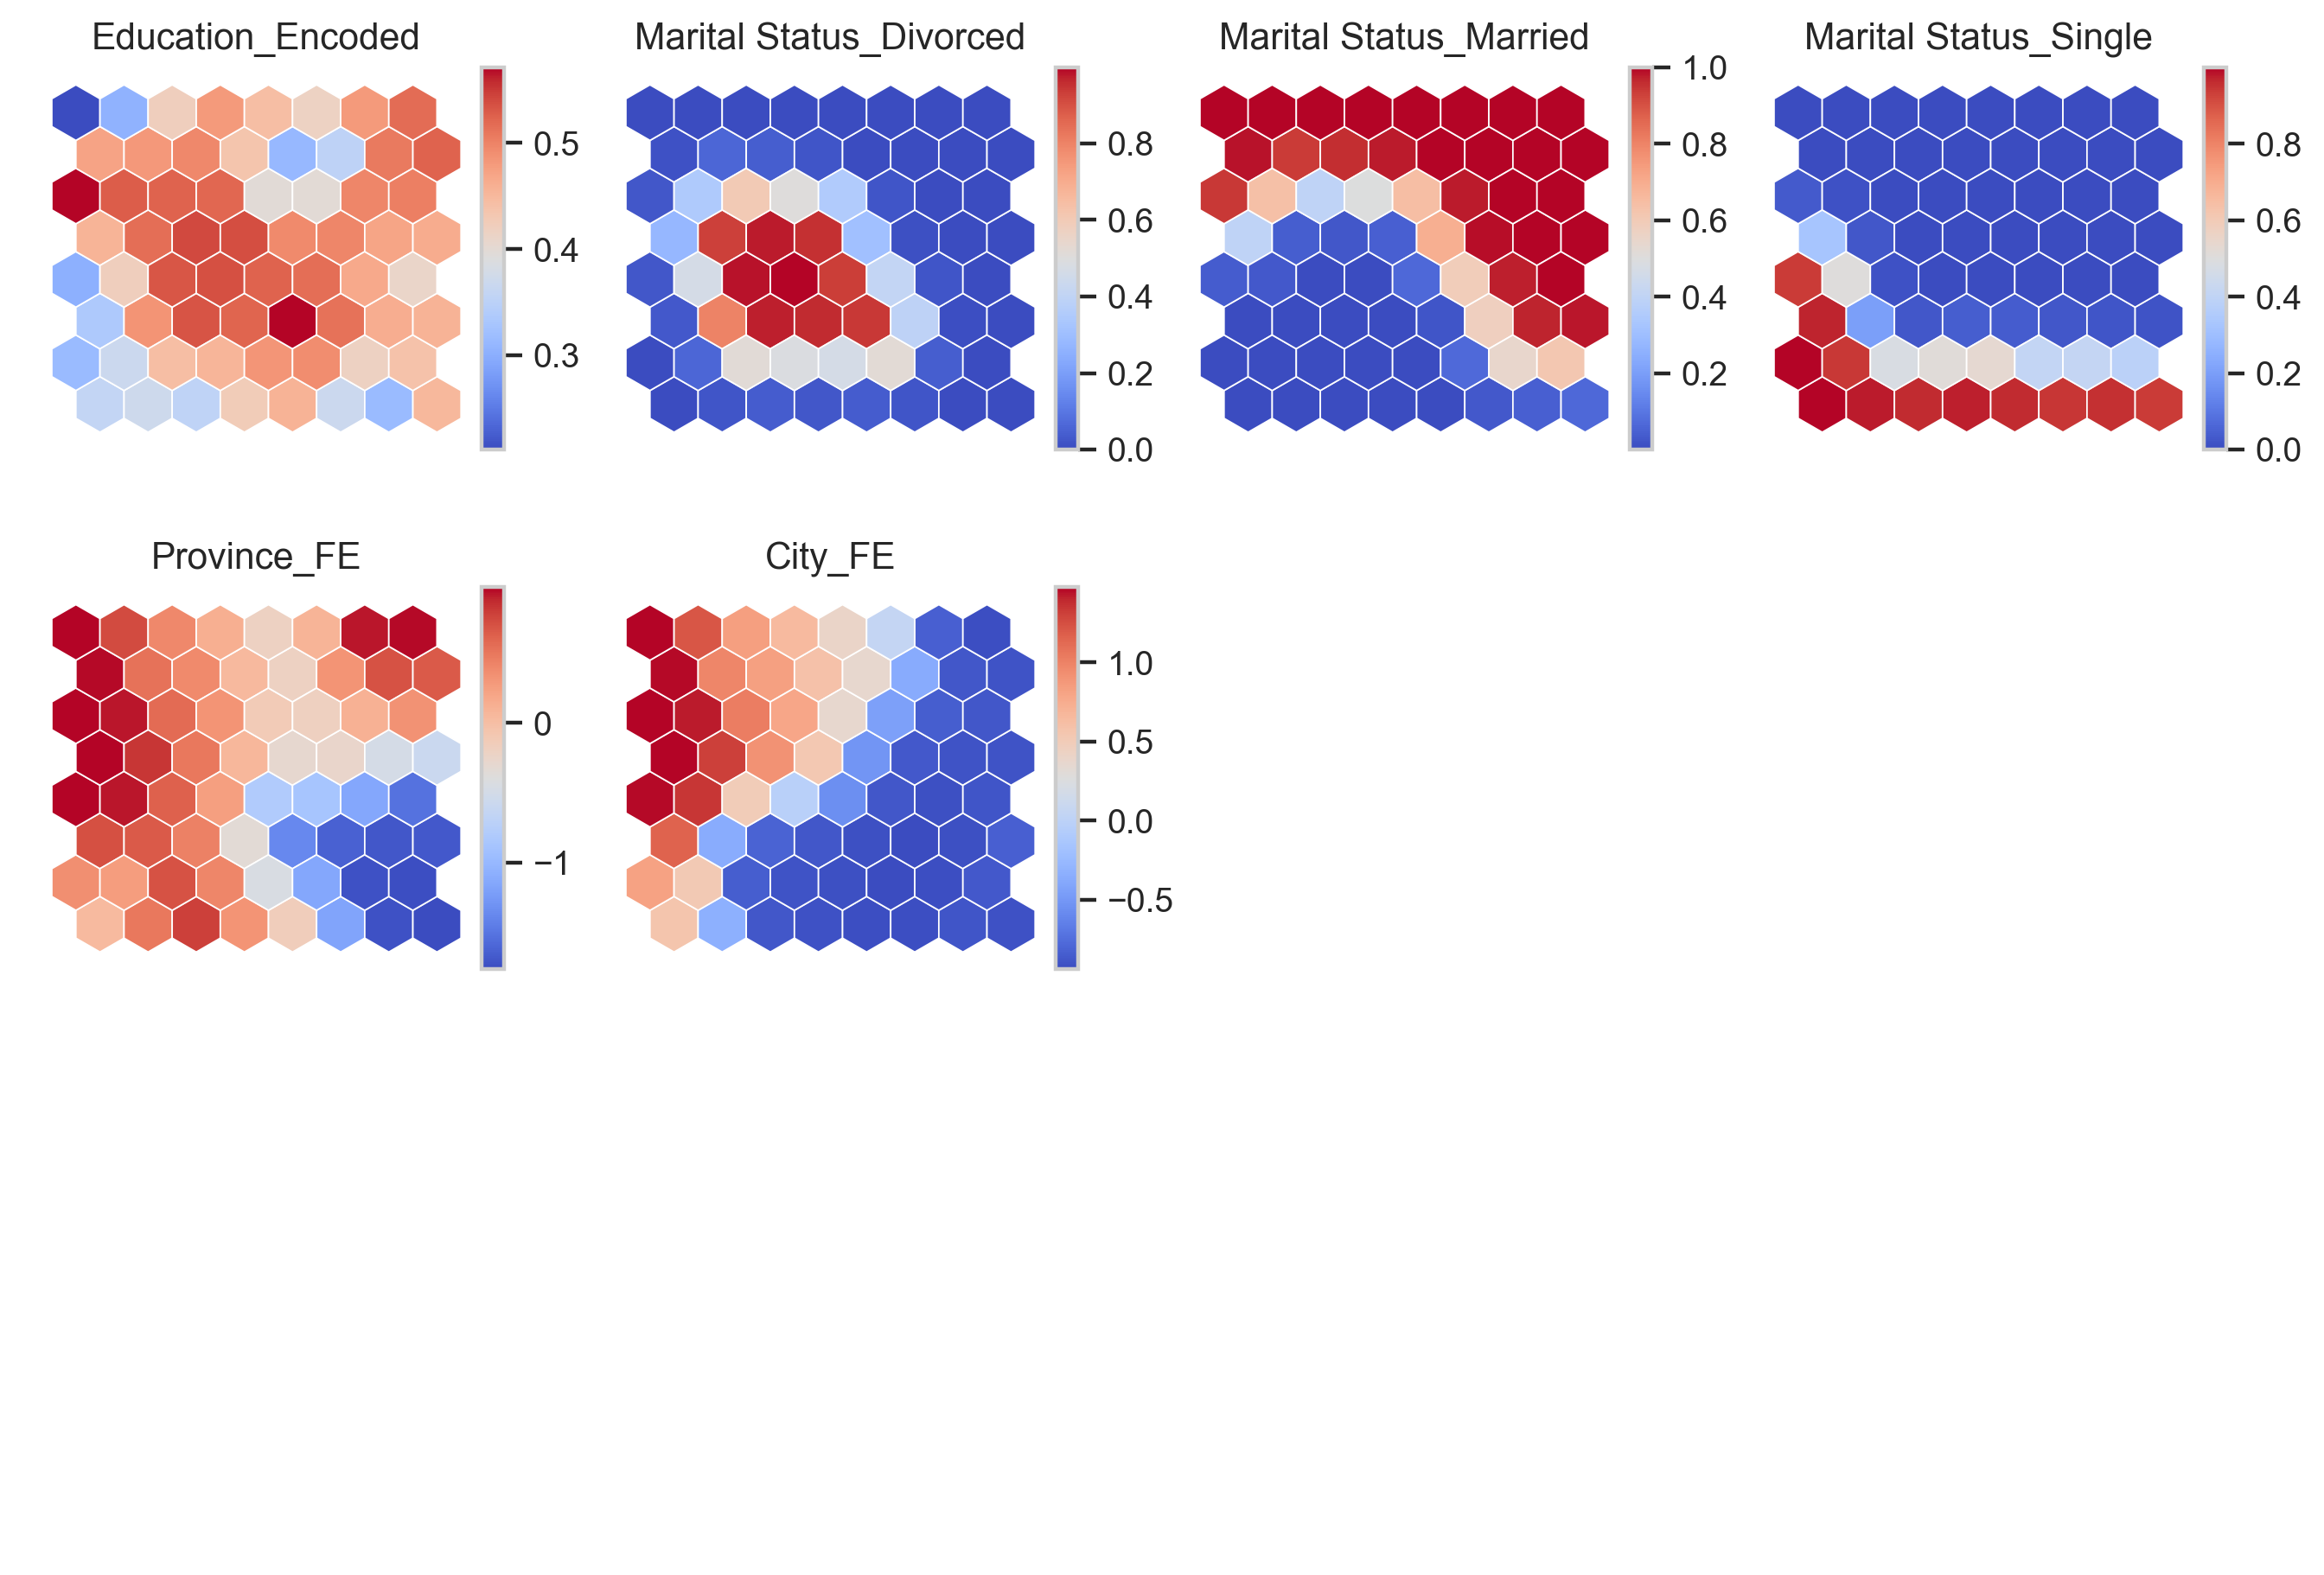

In [1734]:
figsize=(10,7)
fig = plt.figure(figsize=figsize, constrained_layout=True, dpi=128, )

subfigs = fig.subfigures(3,4,wspace=.15)

colornorm = mpl_colors.Normalize(vmin=np.min(weights), vmax=np.max(weights))

for cpi, sf in zip(range(len(D_features)), subfigs.flatten()):
    
    matrix_vals = weights[:,:,cpi]
    vext = np.max(np.abs([np.min(matrix_vals), np.max(matrix_vals)]))
    colornorm = mpl_colors.Normalize(vmin=np.min(matrix_vals), vmax=np.max(matrix_vals))
    # colornorm = mpl_colors.CenteredNorm(vcenter=0, halfrange=vext)


    sf = plot_hexagons(sm, sf, 
                    colornorm,
                    matrix_vals,
                    label=D_features[cpi],
                    cmap=cm.coolwarm,
                    )

In [1735]:
umatrix = sm.distance_map(scaling='mean')

## Flip and rotate to match plot
print(np.flip(np.round(umatrix,2), axis=1).T)

[[0.28 0.29 0.22 0.21 0.31 0.52 0.29 0.13]
 [0.22 0.36 0.32 0.33 0.36 0.48 0.39 0.19]
 [0.41 0.5  0.46 0.53 0.57 0.42 0.34 0.31]
 [0.48 0.58 0.44 0.5  0.7  0.51 0.3  0.41]
 [0.67 0.8  0.61 0.69 0.67 0.5  0.35 0.32]
 [0.58 1.   0.8  0.72 0.79 0.59 0.42 0.25]
 [0.51 0.8  0.56 0.59 0.61 0.57 0.39 0.3 ]
 [0.45 0.58 0.52 0.38 0.48 0.52 0.39 0.35]]


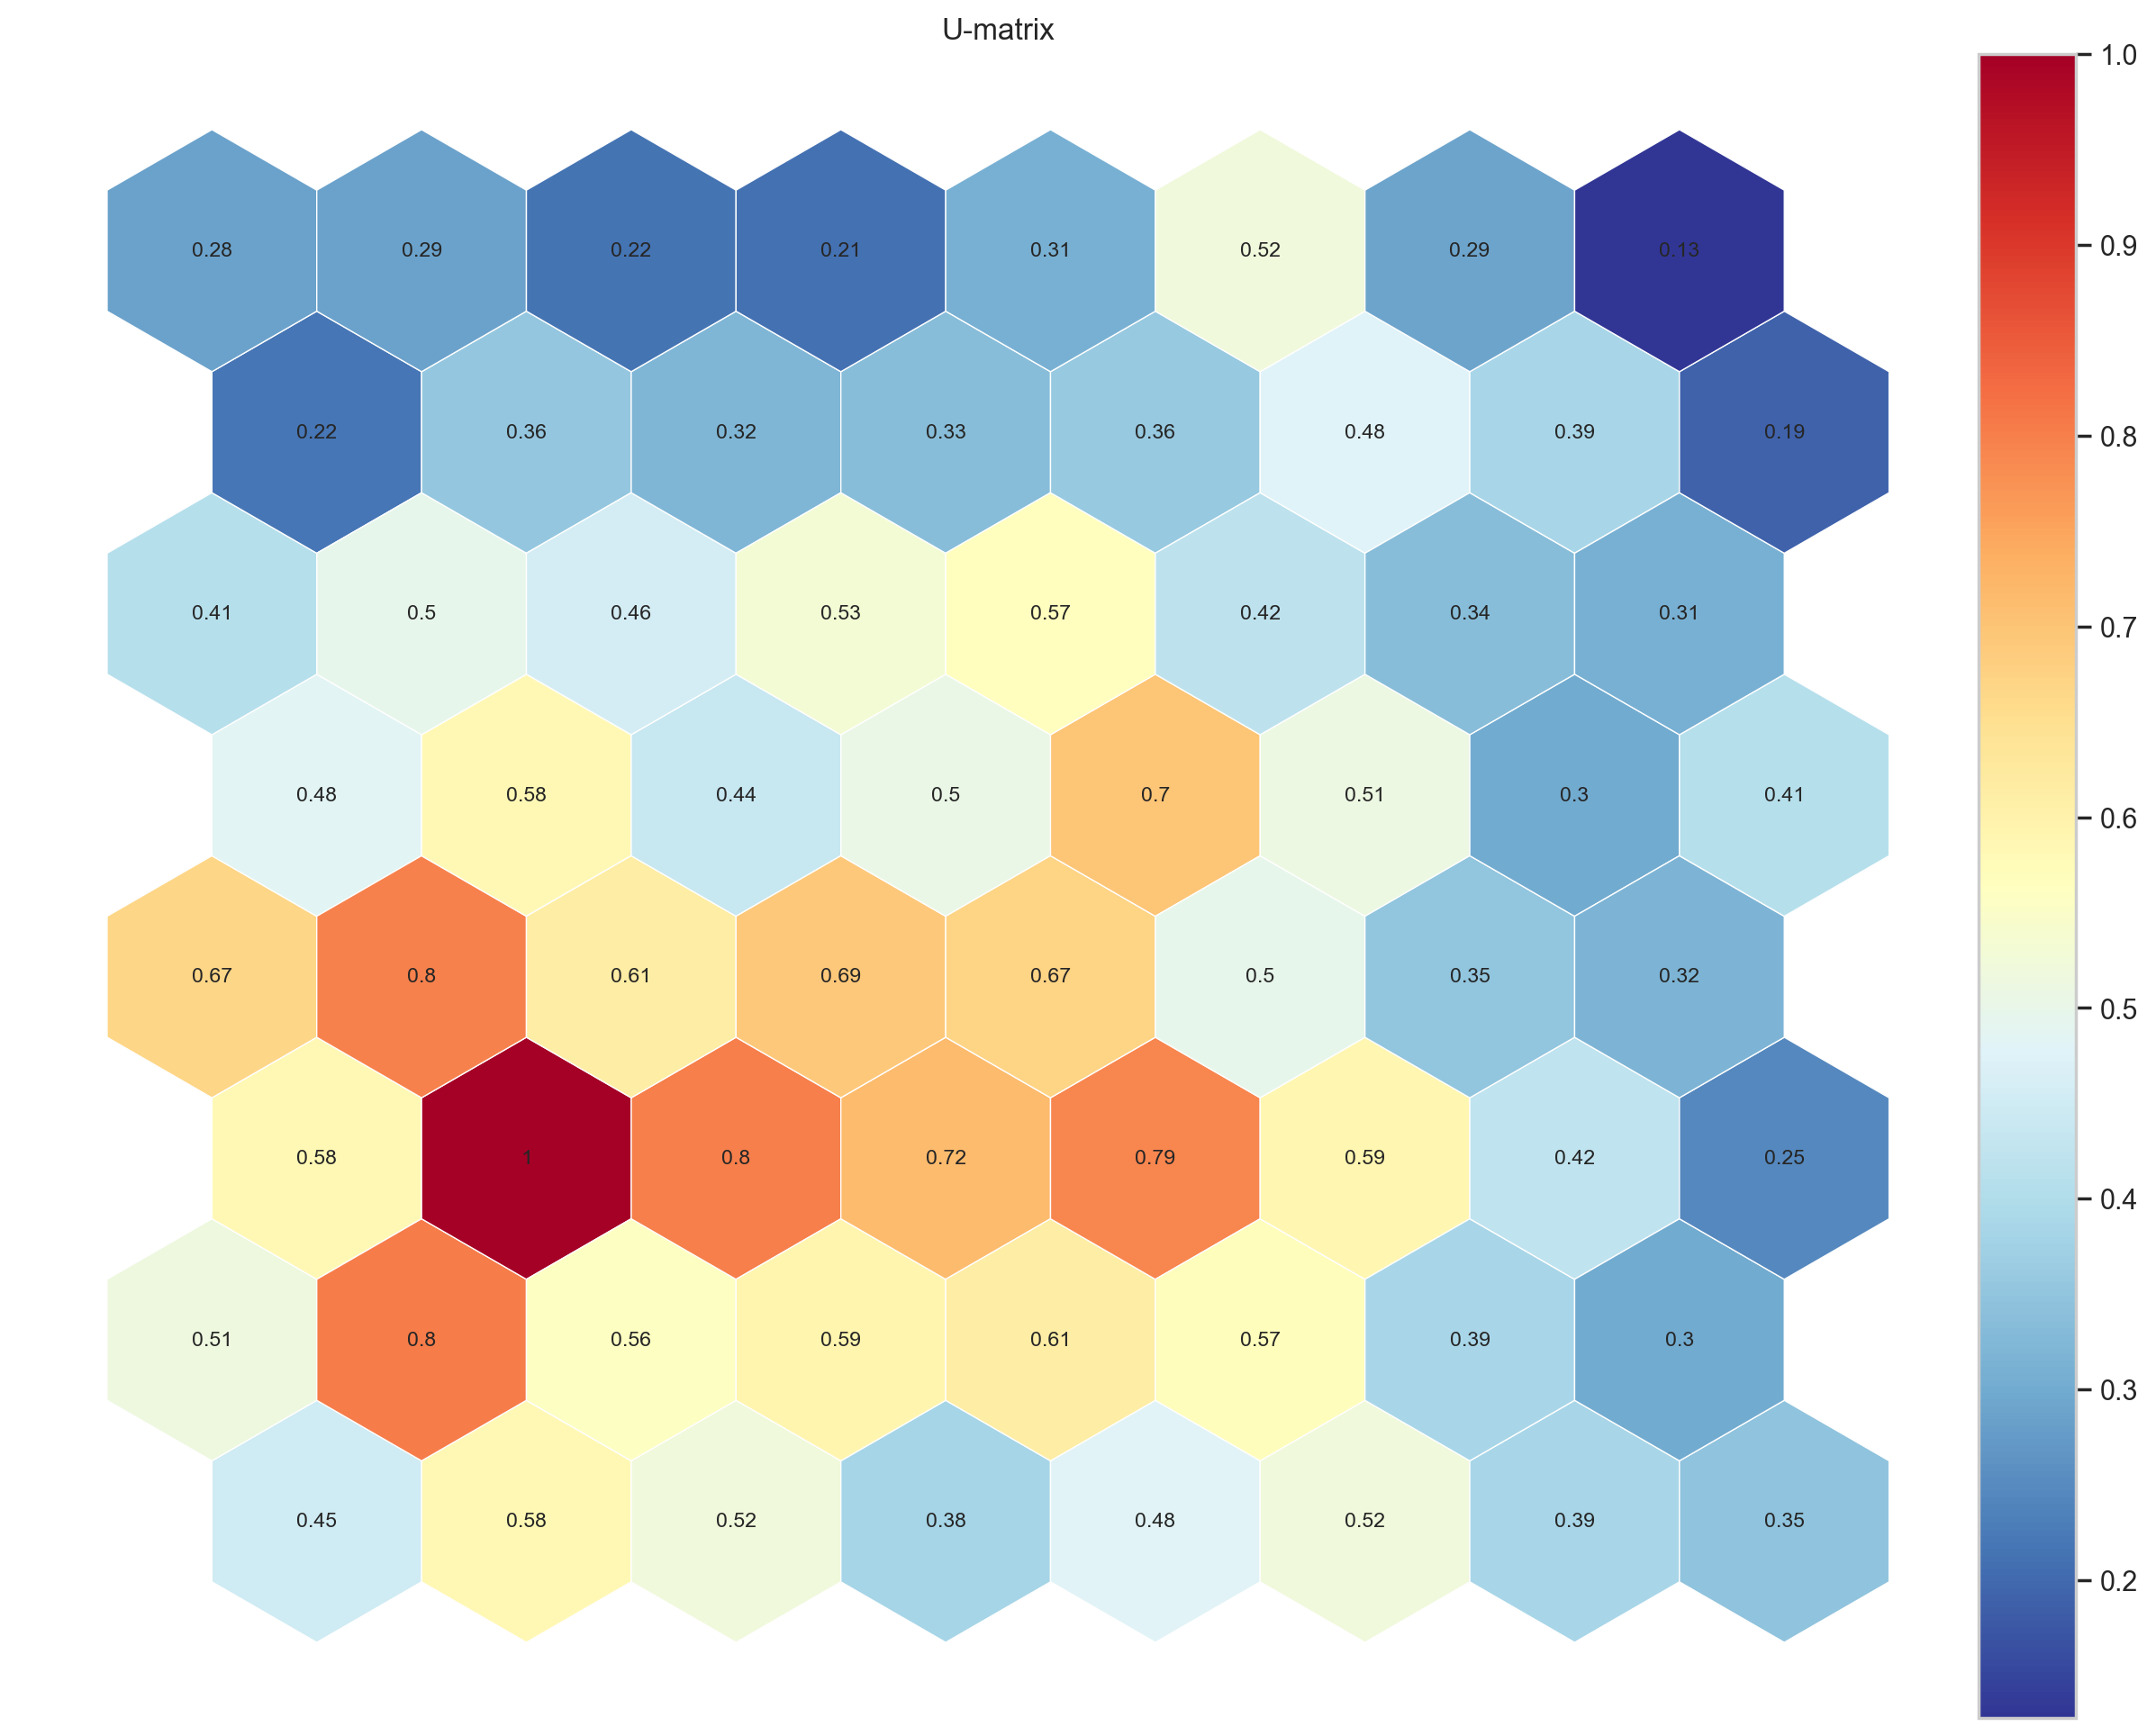

In [1736]:
fig = plt.figure(figsize=(15,12))

colornorm = mpl_colors.Normalize(vmin=np.min(umatrix), vmax=np.max(umatrix))

fig = plot_hexagons(sm, fig, 
                    colornorm,
                    umatrix,
                    label="U-matrix",
                    cmap=cm.RdYlBu_r,
                    annot=True
                    )

In [1737]:
hitsmatrix = sm.activation_response(df_D[D_features].values)

## Values of HITS:
## Flip and rotate to match plot
np.flip(np.round(hitsmatrix,2), axis=1).T

array([[ 405.,    0.,  303.,    0.,  930.,    0.,  559.,  540.],
       [1384.,    0., 1139.,    0.,  228.,    0.,    0.,    0.],
       [ 125.,    0.,    0.,    0.,    0.,    0.,    0., 1016.],
       [   0.,  486.,  392.,  271.,    0.,  684.,    0.,    0.],
       [ 845.,    0.,    0.,    0.,    0.,    0.,    0.,  575.],
       [   0.,    0.,  531.,  195.,  536.,    0.,  831.,  675.],
       [ 646.,    0.,    0.,    0.,    0.,    0.,    0.,    0.],
       [ 532.,    0.,  570.,  486.,  301.,    0.,  509.,  422.]])

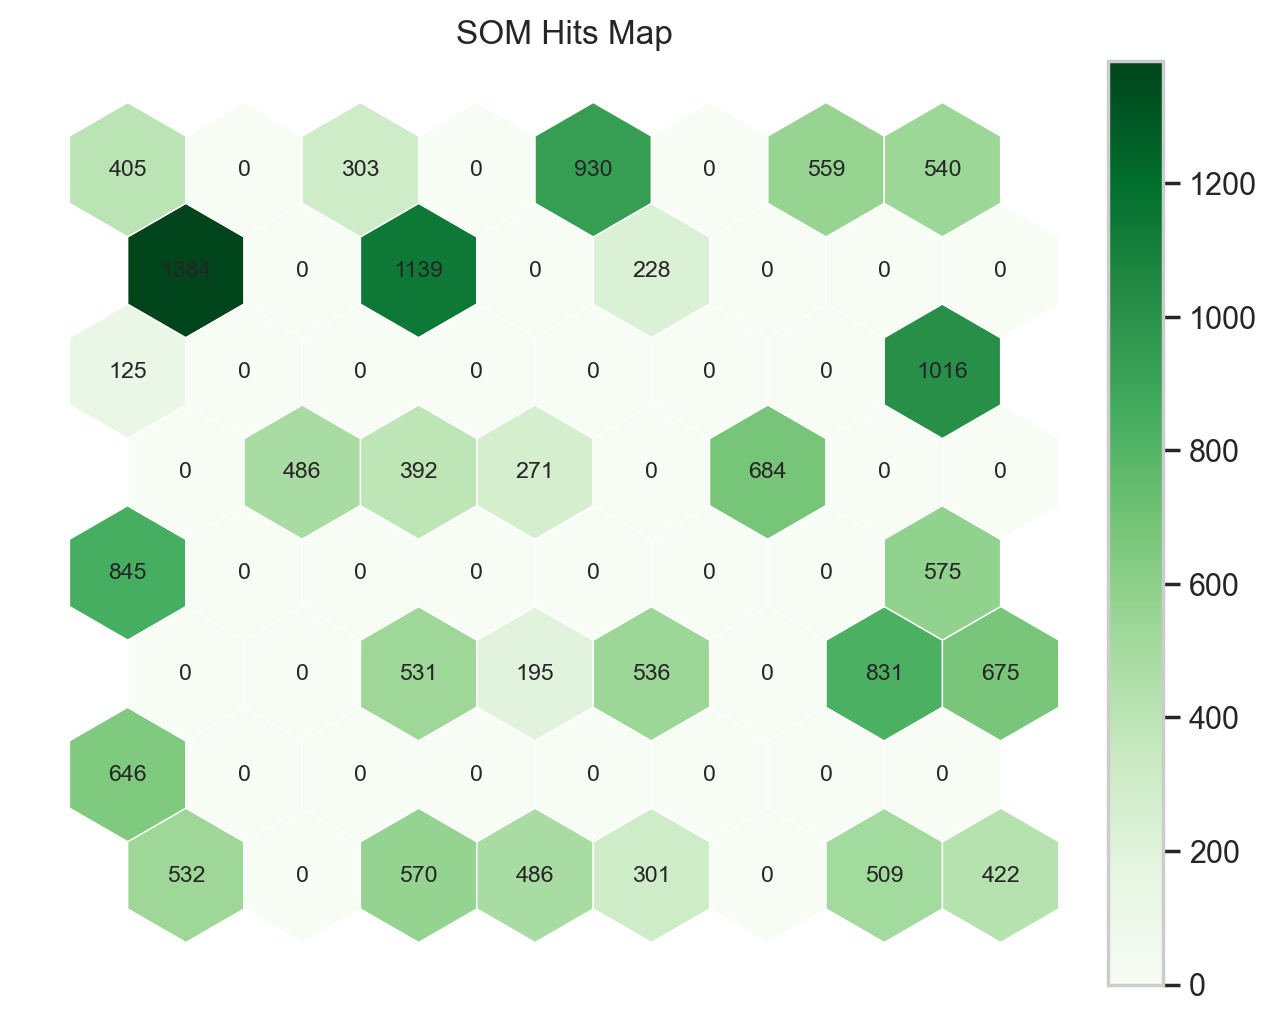

In [1738]:
fig = plt.figure(figsize=(9, 6))

colornorm = mpl_colors.Normalize(vmin=0, vmax=np.max(hitsmatrix))

fig = plot_hexagons(sm, fig, 
                    colornorm,
                    hitsmatrix,
                    label="SOM Hits Map",
                    cmap=cm.Greens,
                    annot=True
                    )

In [1739]:
print(f"Average customers per unit: {hitsmatrix.mean():.1f}")

Average customers per unit: 251.8


In [1740]:
print(f"Frequency range: {hitsmatrix.min():.0f} (least) to {hitsmatrix.max():.0f} (most)")

Frequency range: 0 (least) to 1384 (most)


In [1741]:
M = 10 
N = 10  
neighborhood_function = 'gaussian' 
n_feats = len(D_features)
learning_rate = .5


som_data = df_D[D_features].values

sm = MiniSom(M, N,              
             n_feats,        
             learning_rate=learning_rate, 
             #topology=topology, 
             neighborhood_function=neighborhood_function, 
             sigma=1.8,
             activation_distance='euclidean',
             random_seed=42
             )

In [1742]:
sm.random_weights_init(som_data) 

print(np.round(sm.quantization_error(som_data),4), "Starting QE")
print(np.round(sm.topographic_error(som_data),4), "Starting TE")

0.0954 Starting QE
0.95 Starting TE


c:\Users\Francisco Martins\anaconda3\envs\ml-project\Lib\site-packages\minisom.py:631: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-2 * cross_term + input_data_sq + weights_flat_sq.T)


In [1743]:
sm.train_batch(som_data, 500_000)

In [1744]:
print(np.round(sm.quantization_error(som_data),4),"Ending QE")
print(np.round(sm.topographic_error(som_data),4),"Ending TE")

0.1157 Ending QE
0.0105 Ending TE


In [1745]:
weights = sm.get_weights()

weights.shape

(10, 10, 6)

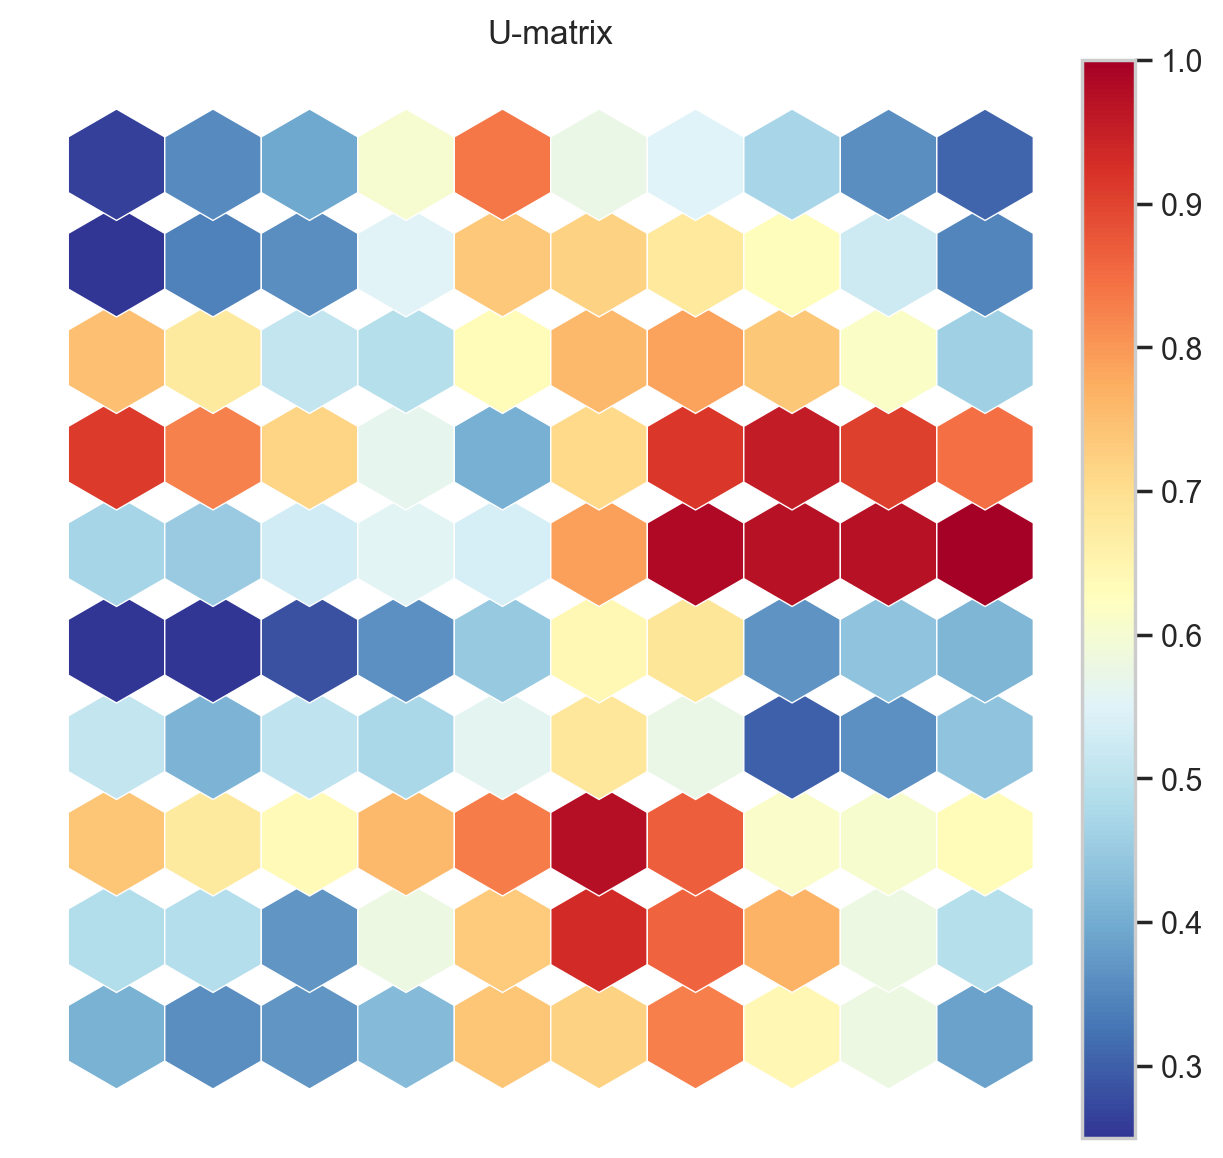

In [1746]:
umatrix = sm.distance_map(scaling='mean')
fig = plt.figure(figsize=figsize)

colornorm = mpl_colors.Normalize(vmin=np.min(umatrix), vmax=np.max(umatrix))

fig = plot_hexagons(sm, fig, 
                    colornorm,
                    umatrix,
                    label="U-matrix",
                    cmap=cm.RdYlBu_r,
                    )

### K-means on SOM

In [1747]:
weights_flat = weights.reshape(M * N, len(D_features))

weights_flat.shape

(100, 6)

In [1748]:
weights_df = pd.DataFrame(weights_flat, columns=[D_features])

weights_df

,Education_Encoded,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Province_FE,City_FE
0,0.298292,9.281372e-11,2.209572e-06,9.999978e-01,-0.156322,-0.907283
1,0.284431,6.669116e-11,5.985572e-03,9.940144e-01,0.096505,-0.869397
2,0.618058,2.462932e-12,7.245314e-01,2.754686e-01,0.779395,-0.918079
3,0.760736,3.403761e-16,9.991195e-01,8.805456e-04,0.971156,-0.976029
4,0.432959,1.269534e-20,9.999996e-01,3.623147e-07,0.971341,-0.953077
...,...,...,...,...,...,...
95,0.499939,2.381932e-03,5.602981e-01,4.373200e-01,-0.999197,-0.430232
96,0.425539,3.148743e-03,2.917374e-03,9.939339e-01,-0.234530,0.396130
97,0.213119,4.265800e-04,1.261848e-06,9.995722e-01,-0.199804,0.421593
98,0.317371,1.917485e-05,2.057316e-10,9.999808e-01,0.180995,0.683788


c:\Users\Francisco Martins\anaconda3\envs\ml-project\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Francisco Martins\anaconda3\envs\ml-project\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Francisco Martins\anaconda3\envs\ml-project\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Francisco Martins\anaconda3\envs\ml-project

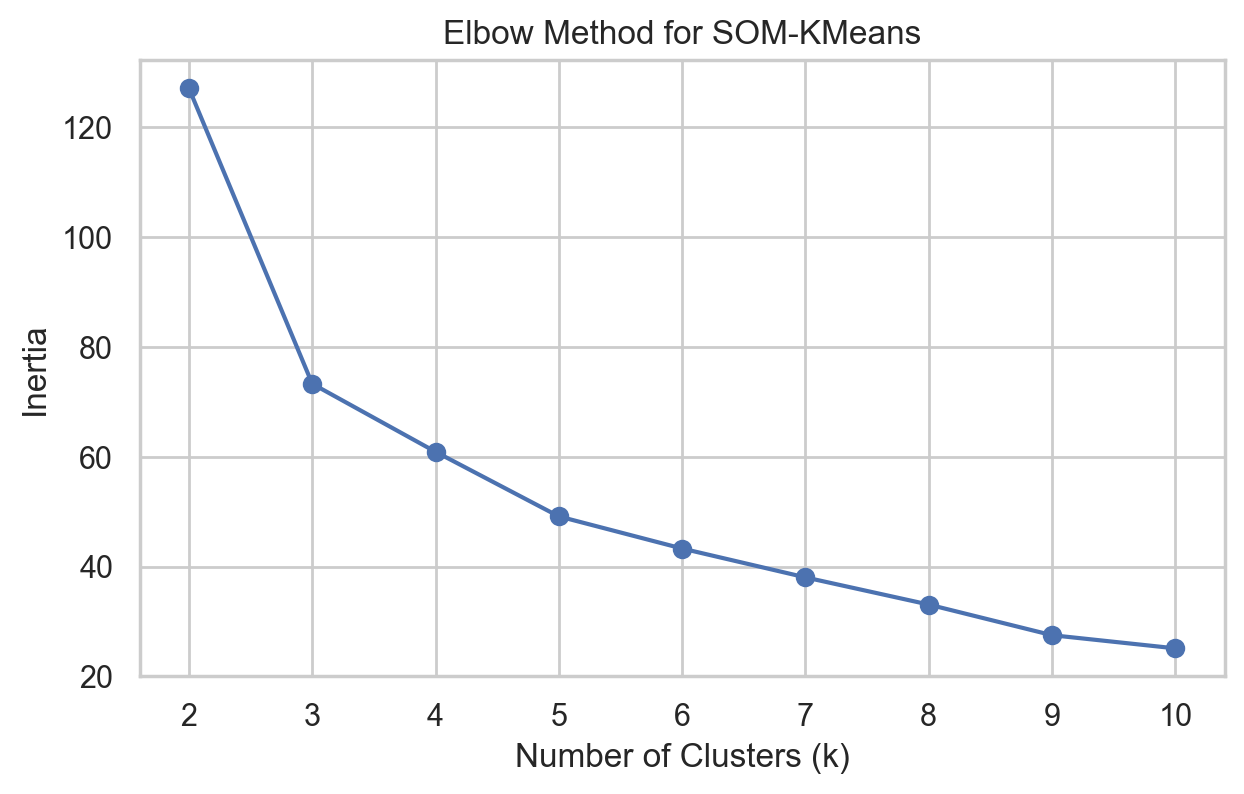

In [1749]:
inertias = []
K_range = range(2, 11)   # testar de 2 a 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(weights_df[D_features])
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for SOM-KMeans")
plt.grid(True)
plt.show()

c:\Users\Francisco Martins\anaconda3\envs\ml-project\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Francisco Martins\anaconda3\envs\ml-project\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Francisco Martins\anaconda3\envs\ml-project\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Francisco Martins\anaconda3\envs\ml-project

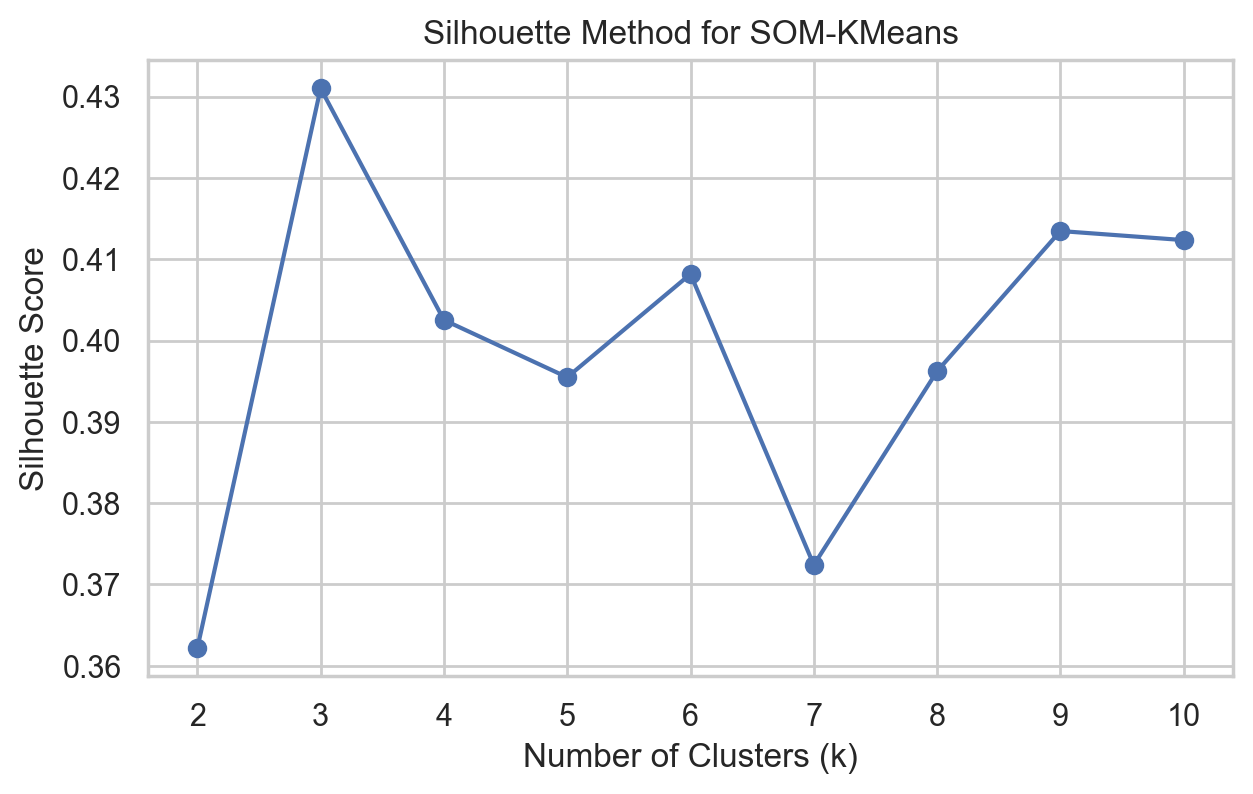

[(2, np.float64(0.36213526942849433)), (3, np.float64(0.4310194205422108)), (4, np.float64(0.40252780147253503)), (5, np.float64(0.39547724882233476)), (6, np.float64(0.4081792469097121)), (7, np.float64(0.3723961989606741)), (8, np.float64(0.3962226091447527)), (9, np.float64(0.4134674425410818)), (10, np.float64(0.41235170591712467))]


In [1750]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(weights_df[D_features])
    sil = silhouette_score(weights_df[D_features], labels)
    sil_scores.append(sil)

plt.figure(figsize=(7,4))
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for SOM-KMeans")
plt.grid(True)
plt.show()

print(list(zip(K_range, sil_scores)))

In [1751]:
K = 3

# Cluster the SOM prototypes (not customers!)
kmeans_som = KMeans(n_clusters=K, random_state=42, n_init=10, init='k-means++')

kmeans_units_labels = kmeans_som.fit_predict(weights_df[D_features])

c:\Users\Francisco Martins\anaconda3\envs\ml-project\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [1752]:
weights_df['cluster_labels'] = kmeans_units_labels
weights_df

,Education_Encoded,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Province_FE,City_FE,cluster_labels
0,0.298292,9.281372e-11,2.209572e-06,9.999978e-01,-0.156322,-0.907283,2
1,0.284431,6.669116e-11,5.985572e-03,9.940144e-01,0.096505,-0.869397,2
2,0.618058,2.462932e-12,7.245314e-01,2.754686e-01,0.779395,-0.918079,2
3,0.760736,3.403761e-16,9.991195e-01,8.805456e-04,0.971156,-0.976029,2
4,0.432959,1.269534e-20,9.999996e-01,3.623147e-07,0.971341,-0.953077,2
...,...,...,...,...,...,...,...
95,0.499939,2.381932e-03,5.602981e-01,4.373200e-01,-0.999197,-0.430232,1
96,0.425539,3.148743e-03,2.917374e-03,9.939339e-01,-0.234530,0.396130,0
97,0.213119,4.265800e-04,1.261848e-06,9.995722e-01,-0.199804,0.421593,0
98,0.317371,1.917485e-05,2.057316e-10,9.999808e-01,0.180995,0.683788,0


In [1753]:
weights_df['cluster_labels'].value_counts().sort_index()

(cluster_labels,)
0                    37
1                    25
2                    38
Name: count, dtype: int64

HC on SOM

In [1754]:
hc_som = AgglomerativeClustering(n_clusters=4, linkage='ward')
w_df = pd.DataFrame(weights_flat, columns=D_features)
hc_units_labels = hc_som.fit_predict(w_df[D_features])

In [1755]:
w_df["cluster_labels"] = hc_units_labels
w_df

,Education_Encoded,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Province_FE,City_FE,cluster_labels
0,0.298292,9.281372e-11,2.209572e-06,9.999978e-01,-0.156322,-0.907283,1
1,0.284431,6.669116e-11,5.985572e-03,9.940144e-01,0.096505,-0.869397,1
2,0.618058,2.462932e-12,7.245314e-01,2.754686e-01,0.779395,-0.918079,2
3,0.760736,3.403761e-16,9.991195e-01,8.805456e-04,0.971156,-0.976029,2
4,0.432959,1.269534e-20,9.999996e-01,3.623147e-07,0.971341,-0.953077,2
...,...,...,...,...,...,...,...
95,0.499939,2.381932e-03,5.602981e-01,4.373200e-01,-0.999197,-0.430232,3
96,0.425539,3.148743e-03,2.917374e-03,9.939339e-01,-0.234530,0.396130,0
97,0.213119,4.265800e-04,1.261848e-06,9.995722e-01,-0.199804,0.421593,0
98,0.317371,1.917485e-05,2.057316e-10,9.999808e-01,0.180995,0.683788,0


In [1756]:
w_df['cluster_labels'].value_counts().sort_index()

cluster_labels
0    32
1    16
2    29
3    23
Name: count, dtype: int64

In [1757]:
# Find BMU for each customer
bmu_indices = []
for customer_vec in som_data:
    bmu = sm.winner(customer_vec)  # Returns (row, col) on SOM grid
    bmu_indices.append(bmu)

bmu_indices = np.array(bmu_indices)
bmu_indices

array([[0, 8],
       [7, 0],
       [8, 8],
       ...,
       [8, 8],
       [4, 6],
       [7, 3]], shape=(16116, 2))

In [1758]:
bmu_indices.shape

(16116, 2)

In [1759]:
bmu_flat_indices = [bmu[0] * N + bmu[1] for bmu in bmu_indices]
bmu_flat_indices = np.array(bmu_flat_indices)
bmu_flat_indices

array([ 8, 70, 88, ..., 88, 46, 73], shape=(16116,))

In [1760]:
print(f"Minimum BMU flat index: {bmu_flat_indices.min()}")
print(f"Maximum BMU flat index: {bmu_flat_indices.max()}")

Minimum BMU flat index: 0
Maximum BMU flat index: 99


In [1761]:
df_final = pd.concat([
                df_D,
                pd.Series(bmu_flat_indices, name='BMU', index=df_D.index)
            ], axis=1
            )

df_final

,Education_Encoded,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Province_FE,City_FE,BMU
Loyalty#,,,,,,,
480934,0.50,0.0,1.0,0.0,0.974108,1.473809,8
549612,0.25,1.0,0.0,0.0,-1.501024,-0.835408,70
429460,0.25,0.0,0.0,1.0,0.400003,0.833986,88
608370,0.25,0.0,0.0,1.0,0.974108,1.473809,79
530508,0.50,0.0,1.0,0.0,-0.231336,-0.954173,44
...,...,...,...,...,...,...,...
823768,0.25,0.0,1.0,0.0,0.400003,0.833986,29
680886,0.50,0.0,1.0,0.0,-1.836259,-0.911518,84
776187,0.25,0.0,0.0,1.0,0.400003,0.833986,88


In [1762]:
df_final2 = pd.concat([
                df_D,
                pd.Series(bmu_flat_indices, name='BMU', index=df_D.index)
            ], axis=1
            )

df_final2

,Education_Encoded,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Province_FE,City_FE,BMU
Loyalty#,,,,,,,
480934,0.50,0.0,1.0,0.0,0.974108,1.473809,8
549612,0.25,1.0,0.0,0.0,-1.501024,-0.835408,70
429460,0.25,0.0,0.0,1.0,0.400003,0.833986,88
608370,0.25,0.0,0.0,1.0,0.974108,1.473809,79
530508,0.50,0.0,1.0,0.0,-0.231336,-0.954173,44
...,...,...,...,...,...,...,...
823768,0.25,0.0,1.0,0.0,0.400003,0.833986,29
680886,0.50,0.0,1.0,0.0,-1.836259,-0.911518,84
776187,0.25,0.0,0.0,1.0,0.400003,0.833986,88


In [1763]:
df_final['cluster_labels'] = df_final['BMU'].map(
    lambda x: kmeans_units_labels[x] )

df_final2['cluster_labels'] = df_final2['BMU'].map(
    lambda x: hc_units_labels[x] )

In [1764]:
df_final

,Education_Encoded,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Province_FE,City_FE,BMU,cluster_labels
Loyalty#,,,,,,,,
480934,0.50,0.0,1.0,0.0,0.974108,1.473809,8,0
549612,0.25,1.0,0.0,0.0,-1.501024,-0.835408,70,1
429460,0.25,0.0,0.0,1.0,0.400003,0.833986,88,0
608370,0.25,0.0,0.0,1.0,0.974108,1.473809,79,0
530508,0.50,0.0,1.0,0.0,-0.231336,-0.954173,44,2
...,...,...,...,...,...,...,...,...
823768,0.25,0.0,1.0,0.0,0.400003,0.833986,29,0
680886,0.50,0.0,1.0,0.0,-1.836259,-0.911518,84,1
776187,0.25,0.0,0.0,1.0,0.400003,0.833986,88,0


In [1765]:
print(df_final['cluster_labels'].value_counts().sort_index())

print(df_final2['cluster_labels'].value_counts().sort_index())

cluster_labels
0    7686
1    3548
2    4882
Name: count, dtype: int64
cluster_labels
0    6528
1    2083
2    3957
3    3548
Name: count, dtype: int64


In [1766]:
r2_kmeans = get_rsq(df_final, D_features, 'cluster_labels')
r2_hc = get_rsq(df_final2, D_features, 'cluster_labels')

print(f"R² for K-means clustering on SOM units:     {r2_kmeans:.4f}")
print(f"R² for HC on SOM units:                     {r2_hc:.4f}")

R² for K-means clustering on SOM units:     0.6591
R² for HC on SOM units:                     0.6967


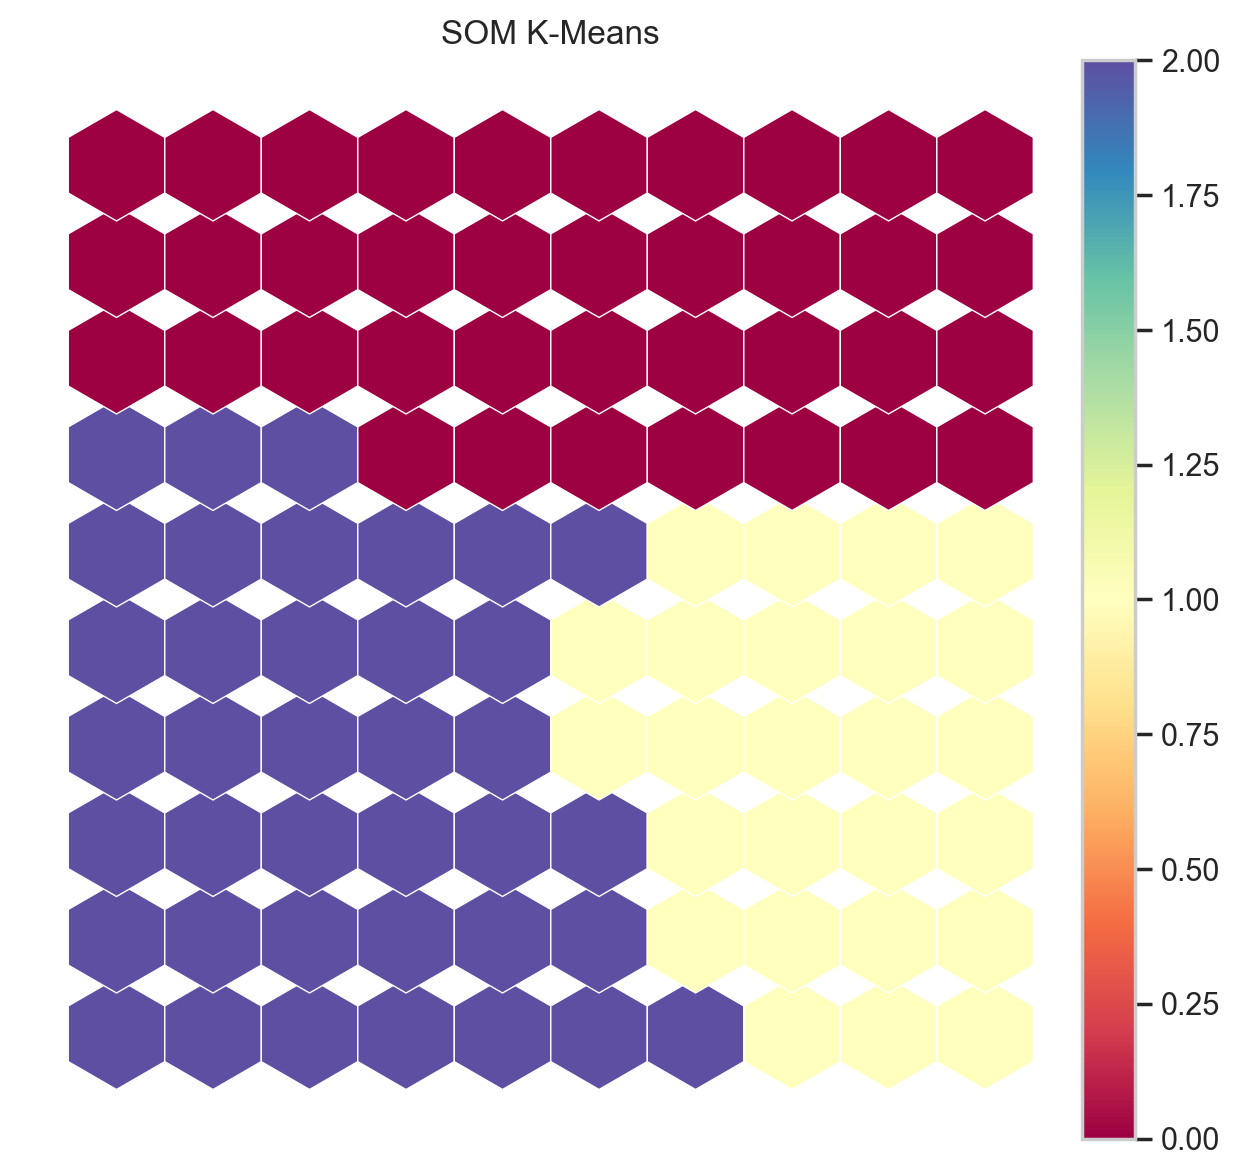

In [1767]:
kmeans_matrix = kmeans_units_labels.reshape((M,N))

fig = plt.figure(figsize=figsize)

colornorm = mpl_colors.Normalize(vmin=0, vmax=np.max(kmeans_matrix))

fig = plot_hexagons(sm, fig, 
                    colornorm,
                    kmeans_matrix,
                    label="SOM K-Means",
                    cmap=cm.Spectral,
                    )

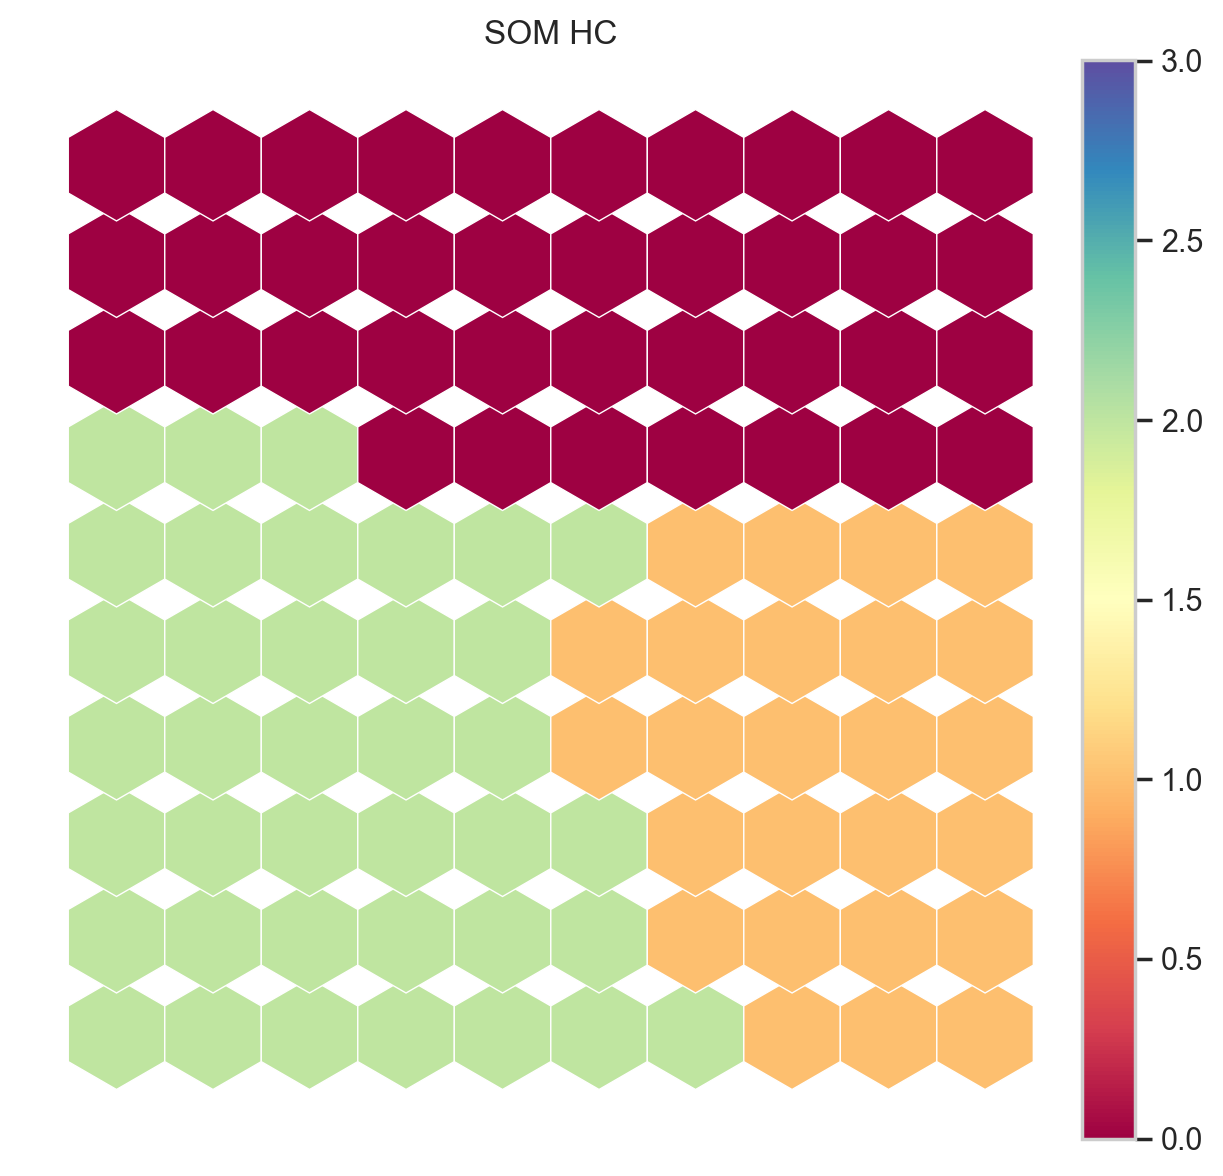

In [1768]:
hc_matrix = hc_units_labels.reshape((M,N))

fig = plt.figure(figsize=figsize)

colornorm = mpl_colors.Normalize(vmin=0, vmax=np.max(hc_matrix))

fig = plot_hexagons(sm, fig, 
                    colornorm,
                    kmeans_matrix,
                    label="SOM HC",
                    cmap=cm.Spectral,
                    )

<Axes: xlabel='cluster_labels'>

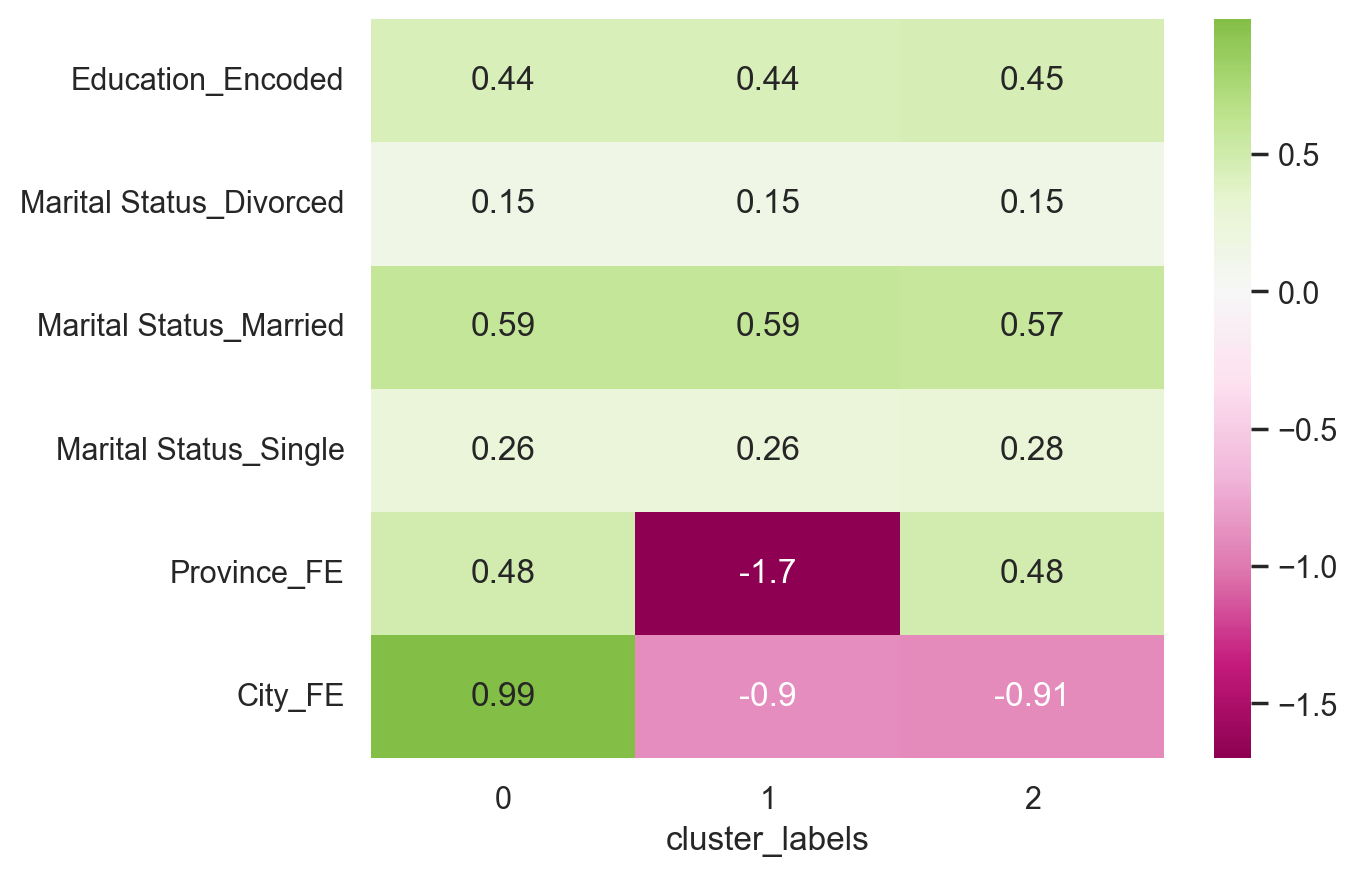

In [1769]:
mat = df_final[D_features + ['cluster_labels']].groupby('cluster_labels').mean().round(2)

sns.heatmap(mat.T, annot=True, cmap='PiYG', center=0)

In [1770]:
get_rsq(df_final, D_features, 'cluster_labels')

np.float64(0.6590879924203474)

<Axes: xlabel='cluster_labels'>

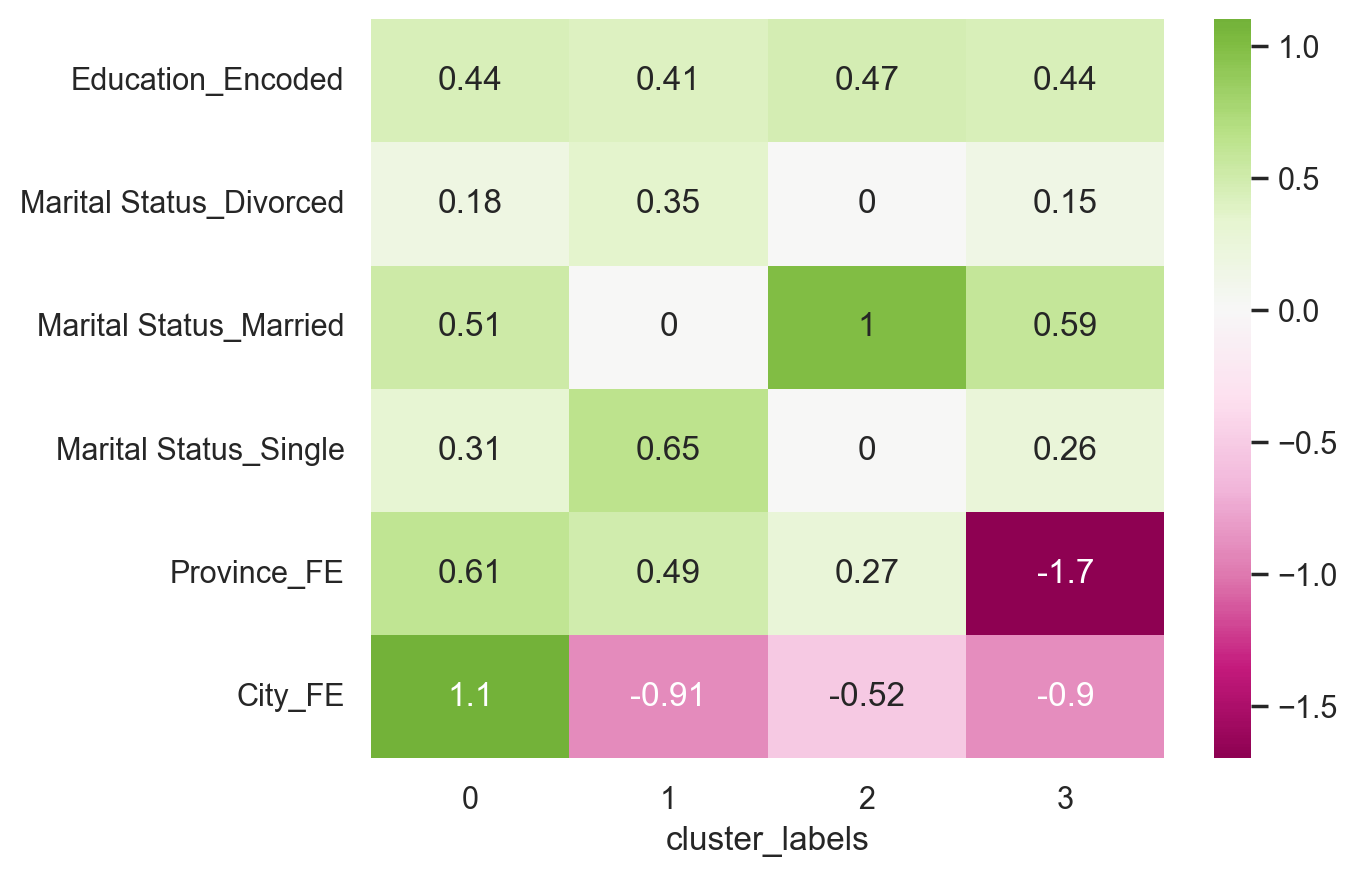

In [1771]:
mat = df_final2[D_features + ['cluster_labels']].groupby('cluster_labels').mean().round(2)

sns.heatmap(mat.T, annot=True, cmap='PiYG', center=0)

In [1772]:
get_rsq(df_final2, D_features, 'cluster_labels')

np.float64(0.6967257766447299)

## Gaussian Mixture Models (GMM)

In [1773]:
df_gm = df_D.copy()

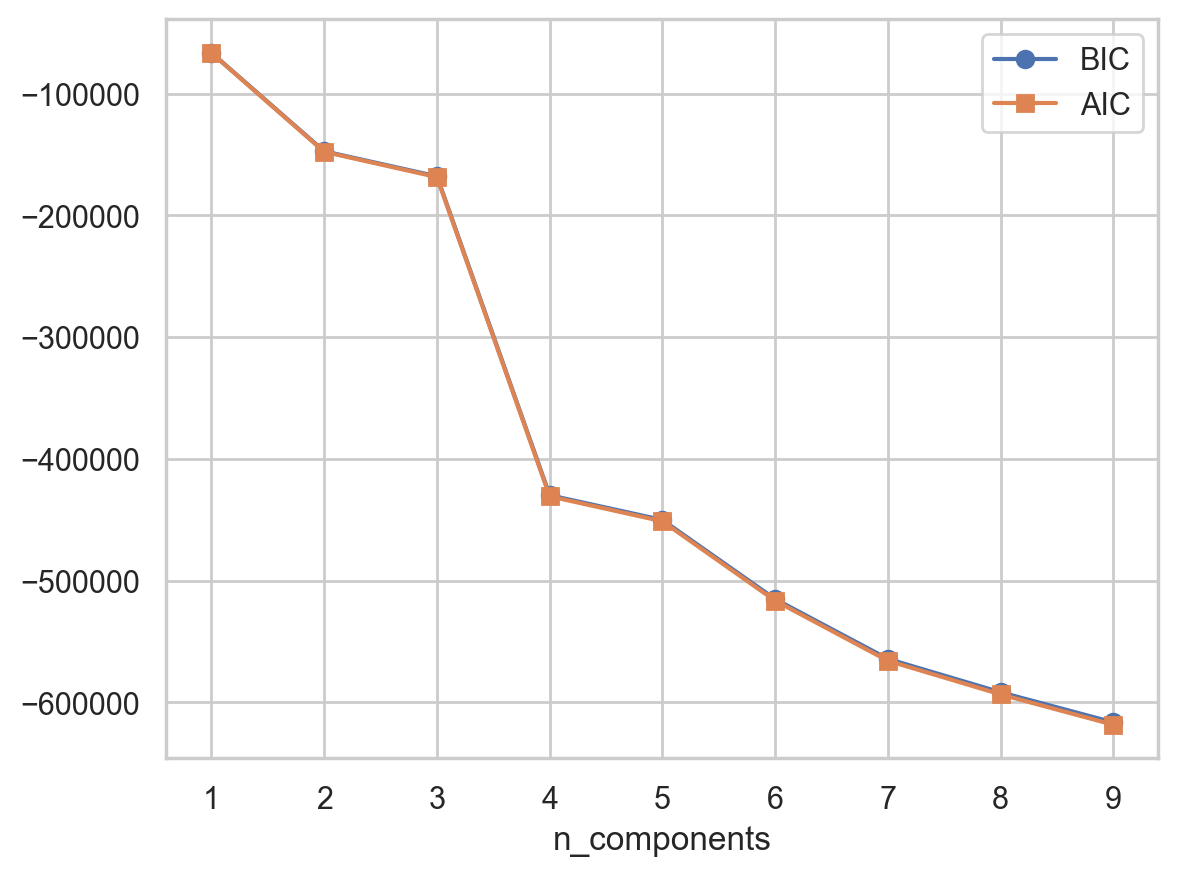

In [1774]:
from sklearn.mixture import GaussianMixture
# This may take a while to run
# 
# Selecting number of components based on AIC and BIC
n_components = np.arange(1, 10)

models = []
for n in n_components:
    model = GaussianMixture(n, covariance_type='full', n_init=10, random_state=1).fit(df_gm[D_features])
    models.append(model)

bic_values = [m.bic(df_gm[D_features]) for m in models]
aic_values = [m.aic(df_gm[D_features]) for m in models]

plt.plot(n_components, bic_values, 'o-', label='BIC')
plt.plot(n_components, aic_values, 's-', label='AIC')
plt.legend(loc='best')
plt.xlabel('n_components')
plt.xticks(n_components)
plt.show()

In [1775]:
# Performing GMM clustering
gmm = GaussianMixture(n_components=4, covariance_type='spherical', n_init=10, init_params='kmeans', random_state=1)

gmm_labels = gmm.fit_predict(df_gm[D_features])

In [1776]:
# Concatenating the labels to df
df_concat = pd.concat([df_gm[D_features], pd.Series(gmm_labels, index=df_gm.index, name="cluster_labels")], axis=1)

df_concat['cluster_labels'].value_counts().sort_index()

cluster_labels
0    3172
1    6040
2    3356
3    3548
Name: count, dtype: int64

In [1777]:

gmm_labels = pd.Series(gmm_labels, index=df_gm.index, name="cluster_labels")

df_gm["cluster_labels"] = gmm_labels

r2_gmm = get_rsq(df_gm, D_features, "cluster_labels")
print(f"GMM R² score: {r2_gmm:.4f}")

GMM R² score: 0.7038


In [1778]:
probabilities = gmm.predict_proba(df_gm[D_features])
probabilities

array([[1.39496282e-04, 7.42077024e-08, 9.99860430e-01, 9.02026730e-28],
       [3.01398364e-10, 2.55659414e-04, 2.29167181e-64, 9.99744340e-01],
       [9.99586279e-01, 4.13720620e-04, 3.54145441e-12, 1.02931279e-16],
       ...,
       [9.99586279e-01, 4.13720620e-04, 3.54145441e-12, 1.02931279e-16],
       [3.18592961e-02, 9.68137532e-01, 2.10177582e-06, 1.06984664e-06],
       [1.89363304e-13, 1.02944645e-05, 5.31535478e-56, 9.99989706e-01]],
      shape=(16116, 4))

In [1779]:
max_probs = probabilities.max(axis=1)

uncertain_threshold = 0.7

certain_customers = df_gm[max_probs >= uncertain_threshold]
uncertain_customers = df_gm[max_probs < uncertain_threshold]

print(f"GMM Probability Analysis:")
print(f"- Clear assignments (≥70% probability): {len(certain_customers):,} customers")
print(f"- Uncertain assignments (<70% probability): {len(uncertain_customers):,} customers ({len(uncertain_customers)/len(df_gm):.1%})")

GMM Probability Analysis:
- Clear assignments (≥70% probability): 16,116 customers
- Uncertain assignments (<70% probability): 0 customers (0.0%)


<Axes: xlabel='cluster_labels'>

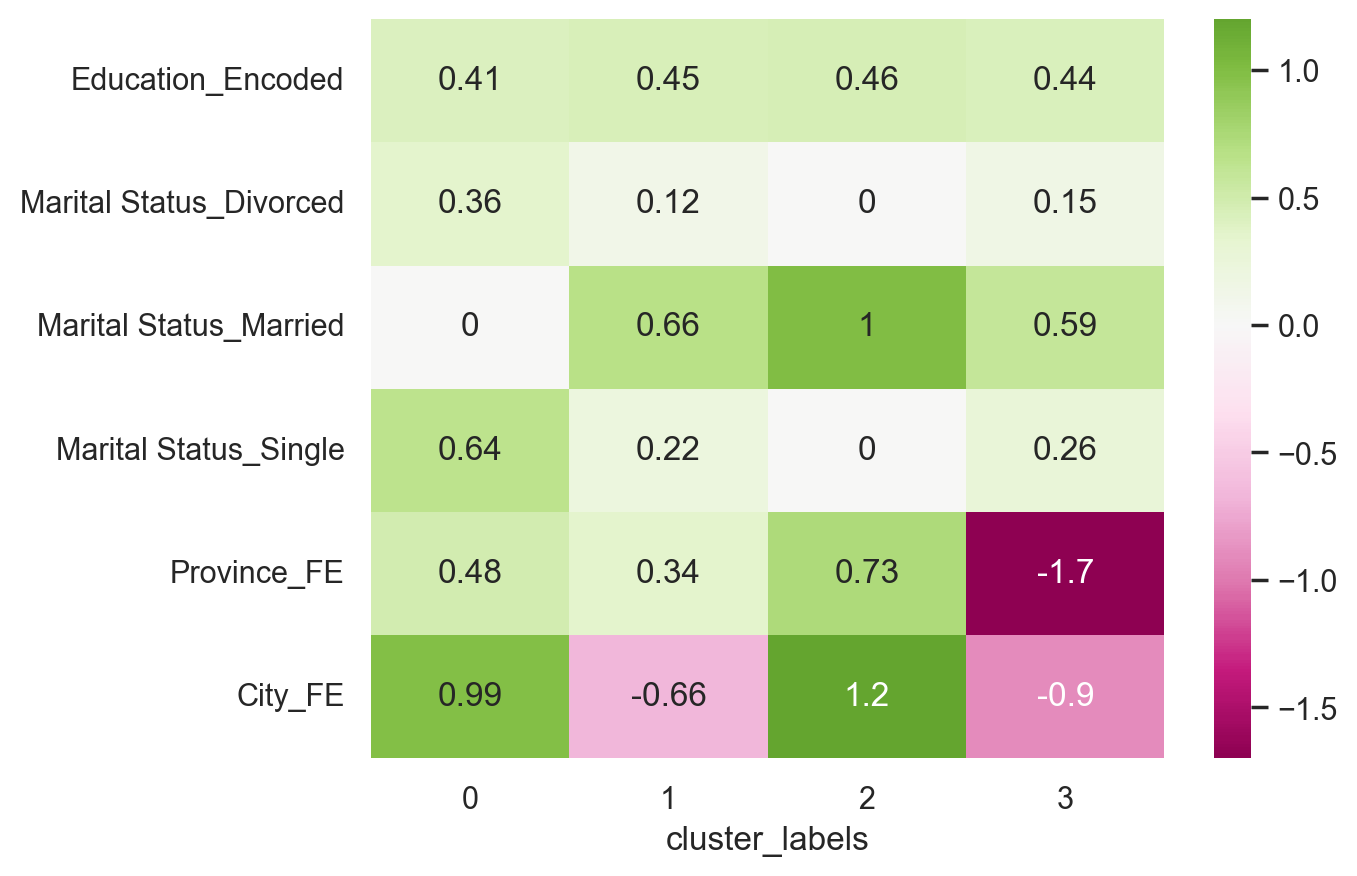

In [1780]:
mat = df_gm[D_features + ['cluster_labels']].groupby('cluster_labels').mean().round(2)

sns.heatmap(mat.T, annot=True, cmap='PiYG', center=0)

In [1781]:
get_rsq(df_gm, D_features, 'cluster_labels')

np.float64(0.7037854105394948)

C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_79732\2688699819.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


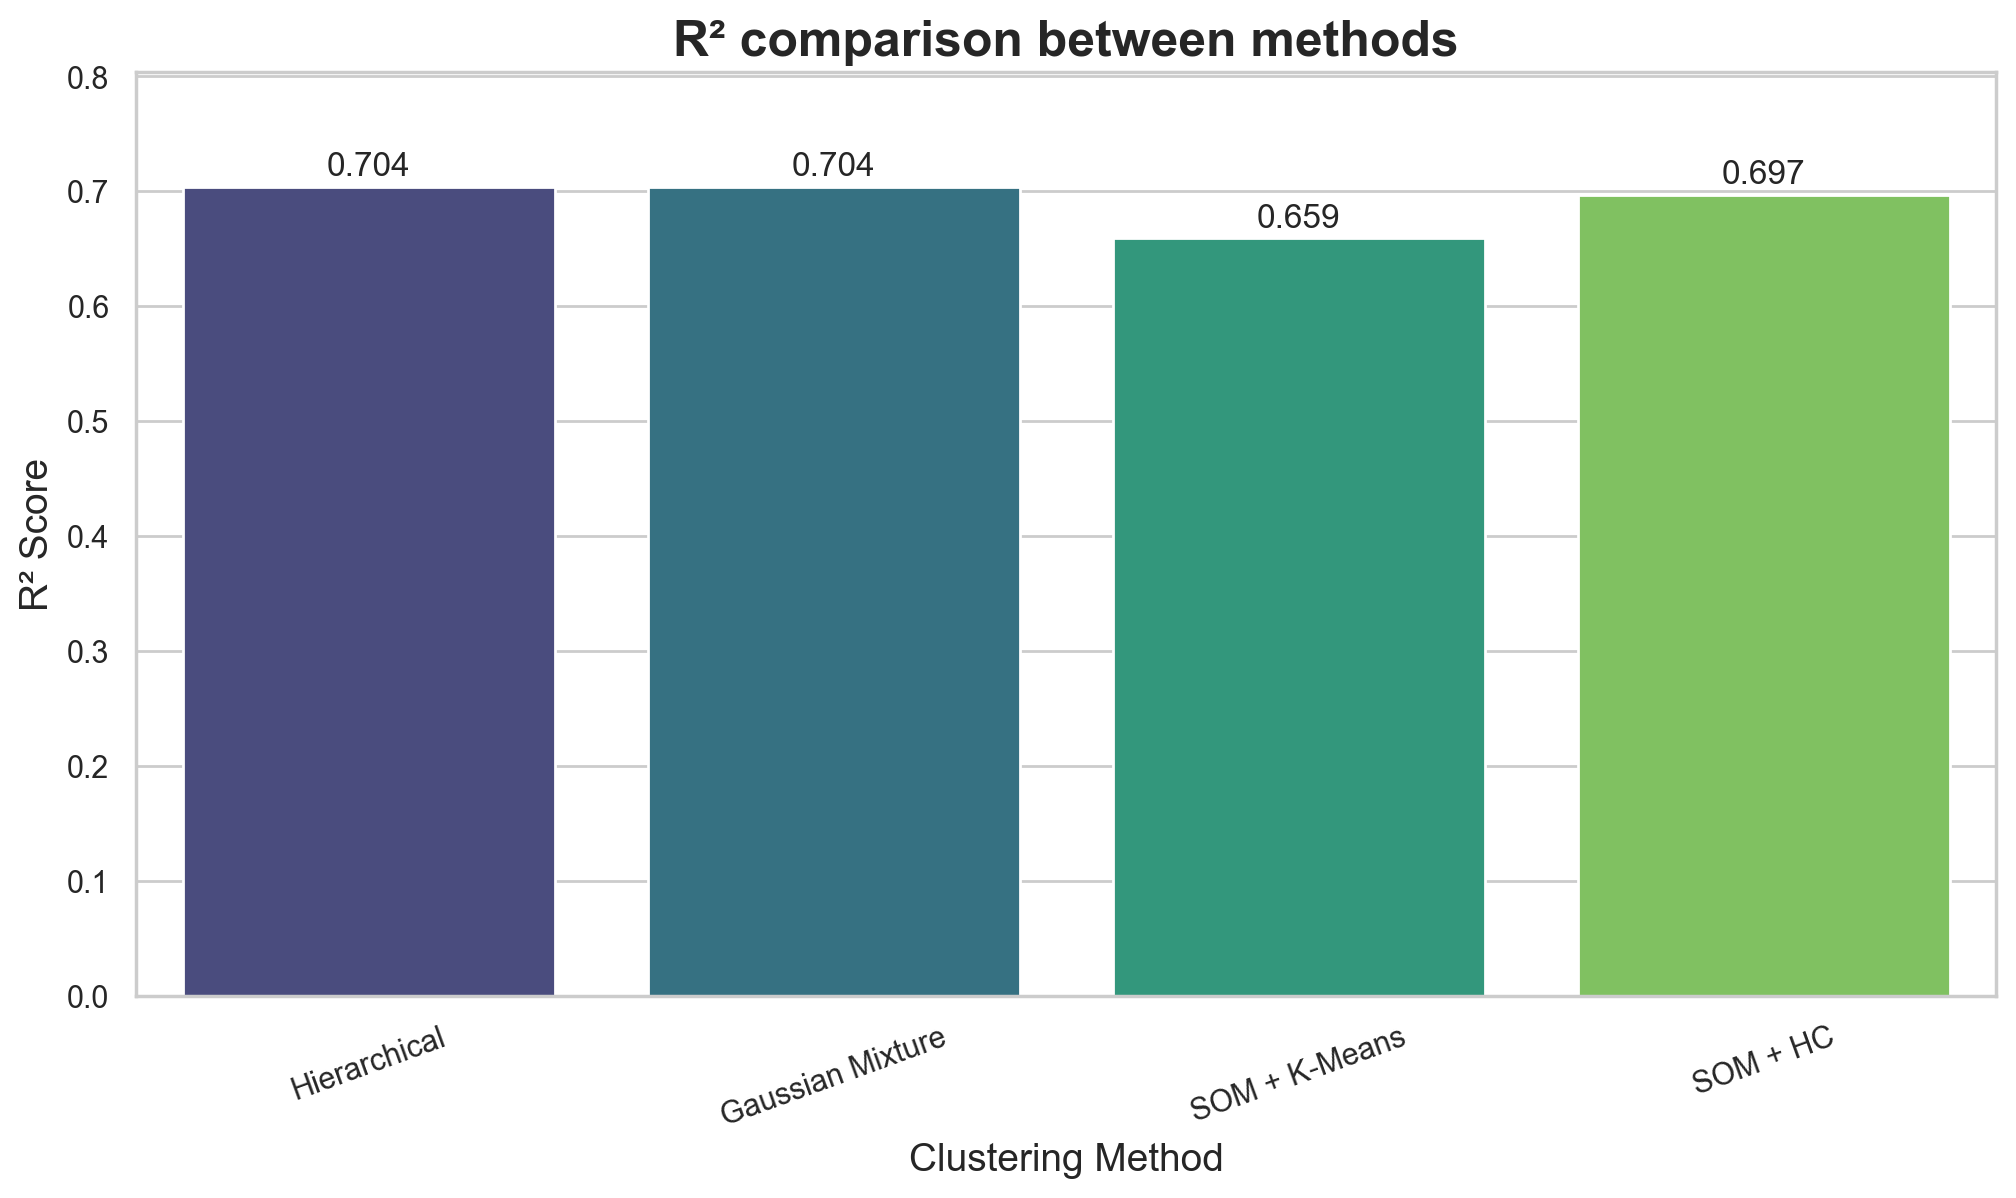

{'Hierarchical': 0.7037854105394948,
 'Gaussian Mixture': 0.7037854105394948,
 'SOM + K-Means': 0.6590879924203474,
 'SOM + HC': 0.6967257766447299}

In [1782]:
import matplotlib.pyplot as plt
import seaborn as sns


dfs = {
    "Hierarchical": df_concat,
    "Gaussian Mixture": df_gm,
    "SOM + K-Means": df_final,
    "SOM + HC": df_final2
}


r2_scores = {}

for method, df in dfs.items():
    r2_scores[method] = float(get_rsq(df, D_features, "cluster_labels"))

plt.figure(figsize=(12,6))
sns.barplot(
    x=list(r2_scores.keys()),
    y=list(r2_scores.values()),
    palette="viridis"
)

plt.ylabel("R² Score", fontsize=14)
plt.xlabel("Clustering Method", fontsize=14)
plt.title("R² comparison between methods", fontsize=18, weight="bold")

for i, v in enumerate(r2_scores.values()):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=12)

plt.ylim(0, max(r2_scores.values()) + 0.1)
plt.xticks(rotation=20)
plt.show()

r2_scores
